# Battery sizing across sixteen households, four GEN-I products quoted two ways, and one legacy contract

Perfect-foresight (MILP) annual electricity cost for **sixteen Fluvius households**, solved once
per **battery capacity** and once per **contract**, over the **whole 2024 calendar year**
(35 136 fifteen-minute intervals, leap year included). Every solve uses the *continuous*
formulation (`use_discrete_actions=False`), so each point is the theoretical optimum for that
(household, contract, capacity) — no controller can do better.

## The price lists

Four GEN-I household products, each quoted **both ways** — in its *samooskrba* (self-supply)
form, which credits exports per interval, and in its plain form, which credits them nothing —
plus one legacy contract. Nine price lists, every one of them solved at every battery capacity.

Every list runs under `pricing_scheme="si_samooskrba"`, including the plain ones, whose export
credit the package itself sets to zero. Section 1 shows why that is the right dispatcher for a
plain contract and what `si_dobava` would do instead.

| Product | Form | List | `paket_id` | Import price [EUR/kWh] | Export credit [EUR/kWh] | Fee |
|---|---|---|---|---|---|---|
| Dinamični | samooskrba | Dinamični | `GENI_SAMO_DINAMICNI` | SIPX + 0.01199, **uncapped** | SIPX − 0.01199, per interval | 1.97 |
| Dinamični | brez odkupa | Dinamični BO | `GENI_DINAMICNI` | SIPX + 0.01199, **capped at 0.22** | none | 1.97 |
| Redni | samooskrba | Redni 1T | `GENI_SAMO_REDNI` | 0.10290 flat (ET) | 0.05390 flat, per interval | 0.99 |
| Redni | brez odkupa | Redni 2T | `GENI_REDNI` | VT 0.11990 / MT 0.09790 | none | 0.99 |
| Aktivni | samooskrba | Aktivni | `GENI_SAMO_AKTIVNI` | 4 blocks, 0.04090 → 0.19290 | 4 blocks, 0.00190 → 0.14990 | 0.99 |
| Aktivni | brez odkupa | Aktivni BO | `GENI_AKTIVNI` | 4 blocks, 0.03490 → 0.17990 | none | 0.99 |
| Fiksni | samooskrba | Fiksni | `GENI_SAMO_FIKSNI` | 4 blocks, 0.04590 → 0.19790 | 4 blocks, 0.00190 → 0.14490 | 0.99 |
| Fiksni | brez odkupa | Fiksni BO | `GENI_FIKSNI` | VT 0.12490 / MT 0.10290 | none | 0.99 |
| Redni | **legacy** | Redni + NM | `GENI_NETMETERING` | 0.12990 flat (ET) | **nothing per interval** — netted annually | 0.99 |

**`BO` is *brez odkupa*, no buyback.** The Redni pair is labelled 1T/2T instead, because there
the tariff structure is the more useful thing to see at a glance — 1T is the samooskrba list's
single ET rate, 2T the plain list's VT/MT pair. Both markers mean the same thing about the
export credit. Monthly fees are the `mesecno_nadomestilo_eko` rates (`eko_racun=True` is the
pricing default), so the dynamic pair carries about 12 EUR/a more in fixed supplier fee than
the other three.

**The pairs are not the same prices with the credit switched off**, which is the reason for
running both. The plain dynamic list caps SIPX at 0.22 EUR/kWh where its samooskrba twin is
uncapped — in a 2024 spike that is the difference between paying 0.31 and 0.53 EUR/kWh.
`GENI_REDNI` is two-tariff where `GENI_SAMO_REDNI` is a single flat rate. `GENI_AKTIVNI`
undercuts `GENI_SAMO_AKTIVNI` in every one of the four blocks. `GENI_FIKSNI` is two-tariff
where `GENI_SAMO_FIKSNI` is a four-block list. Beyond the supplier's energy price, all nine add
the same network charge, levies and VAT on metered offtake, and the same ratchet excess-power
charge.

**Who the plain form is for.** A household with no production, obviously — but equally a PV
household whose connection is approved with a **0 kW export limit**. The panels feed the load,
the surplus is curtailed, and nothing crosses the meter outward. That is the same arithmetic
either way, and it is why the plain lists are swept for every household in the study rather
than treated as a no-PV special case.

**VT/MT is a different clock from everything else here.** VT runs 06:00–22:00 on working days,
MT covers nights, weekends and holidays (`si_cas.je_vt`) — it is not the four-block *aktivni*
window and not the five-block network tariff. It is the only list in the study whose supplier
price moves on that boundary.

## Who can be quoted what

The sample is split evenly over all eight Fluvius families (section 2), so **half the
households have no PV**. That does not narrow their choice at all: a self-supply list does not
require production, so all sixteen households are quoted all eight selectable lists at every
capacity. The one thing a household without production cannot sign is NET metering — a closed
contract that nets exports it does not have. That is the only ragged edge in the grid; every
table below leaves a cell blank rather than pricing a list that household cannot sign.

## NET metering is a legacy contract, not a baseline

Annual netting is **closed to new customers**. It only exists for households that already hold
that contract, which makes it the wrong thing to measure anything against: an option nobody can
buy cannot be the reference case, and "NET metering wins" is not an answer to "which list should
this household be on". Under `LEGACY_CONTRACTS` it is therefore excluded from every winner, every
spread and every headline in section 8, which resolve over `CURRENT_CONTRACT_ORDER` — the eight
selectable lists — and it is reported alongside them instead, in grey on every chart, answering
two separate questions:

* what a household **still on** the contract pays today, and what it would give up by leaving;
* what it should size a battery for **after** the contract ends, which is a selectable list.

Read every NET-metering number as belonging to that second population only.

**NET metering needs an annual settlement, not an interval one.** `si_obracun._cena_oddaje`
returns `0.0` for `TipOdkupa.NET_METERING`, which is correct at the interval level — that
contract credits nothing as you export, it nets exports against imports once a year, on the
*supplier energy* component only (network charges and levies stay on gross metered offtake
under the 2024 network act). Priced interval-by-interval it would look absurdly bad and the
solver would curtail rather than export. `run_milp_benchmark` therefore takes
`annual_netting_rate_eur_per_kwh`, which adds

    credit = rate * min(total imported, total exported)

to the objective as a single bounded variable, and books it on the closing interval — see the
`Netting_Credit_EUR` column. `rate` is the list's own VAT-inclusive ET price, read straight
off `PAKETI["GENI_NETMETERING"]`.

## What is new relative to the single-household version

* Sixteen households instead of one, split evenly over the eight Fluvius families by a
  documented rule rather than by hand — two per family, and inside each family spread across
  that family's own PV-to-load distribution.
* Nine price lists per household instead of one — four GEN-I products in both their samooskrba
  and their no-buyback form, plus the legacy NET-metering contract, with the annual settlement
  above. Every list is swept across every capacity, so the samooskrba/plain comparison is
  available at each battery size and not only at zero.
* **ROI**: capex, NPV, discounted ROI %, IRR and simple payback for every point on every curve.
* **Cycle count**: equivalent full cycles measured on the *stored* energy, and used to derive a
  cycle-limited service life that feeds back into the ROI.
* **Sizing against price**: section 8.4 sweeps the installed storage cost and reports the
  optimal capacity at each level, so the answer is not tied to one assumed price
  (the assumption is 250 EUR/kWh).
* An explicit whole-year audit (section 4) — the horizon really is every interval of 2024.

### Runtime — ~1 min as shipped, ~5–6 h to recompute the sweep

The MILP sweep in section 6 is the only expensive step, and it is both **parallel and cached**:

* `Results/multiuser_battery_sizing.csv` holds one row per solved (dataset, household, contract,
  capacity). It currently carries 3 200 rows worth **41.6 CPU-h** of solver time — ~47 s per
  solve, 4.6 min for the worst one.
* `joblib.Parallel` runs the outstanding keys on `N_JOBS = 8` worker processes and the CSV is
  flushed every few results, so a cold run is **~5–6 h** and an interrupted one costs nothing:
  the next execution solves only the keys missing from the cache.
* The household index (`Results/fluvius_pv_household_index.csv`) is cached per *dataset*, so
  adding a Fluvius family scans only that family.

With both caches warm the sweep cell returns in milliseconds and every remaining cell is pandas
and matplotlib — about a minute for the whole notebook.


In [127]:
### Imports
import json
import math
import sys
import textwrap
import time
from itertools import product
from pathlib import Path

import numpy as np
import pandas as pd
import pulp
from joblib import Parallel, delayed
from matplotlib import pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter

import importlib
import Data_Loader as dl
import Environment as environment_module
import Horizon_Comparison as hc
import MILP_Benchmark as milp_module
import Pricing_Functions as pricing_module

dl = importlib.reload(dl)
environment_module = importlib.reload(environment_module)
hc = importlib.reload(hc)
milp_module = importlib.reload(milp_module)
pricing_module = importlib.reload(pricing_module)

HouseholdEnvironment = environment_module.HouseholdEnvironment
run_milp_benchmark = milp_module.run_milp_benchmark
PAKETI = pricing_module.PAKETI
DDV = pricing_module.DDV

print("Imports ready.")

Imports ready.


## 1. Configuration

Everything the study depends on lives in this one cell.

### Which price list each household is quoted, and at what capacity

| | 0 kWh | > 0 kWh |
|---|---|---|
| **With PV** | all 8 selectable + *Redni + NM* | all 8 selectable + *Redni + NM* |
| **Without PV** | all 8 selectable | all 8 selectable |

*Italic = legacy.*

**Nothing is gated on PV except NET metering.** A samooskrba list does not require production,
and a plain list is quotable to anyone, so all sixteen households are solved on all eight
selectable lists at all sixteen capacities. NET metering is the one exception: it is closed to
new contracts, and it settles exports against imports once a year, so a household with no
production has nothing to net and no way to sign it. `contract_available` is that one rule.

**Both forms of every product, at every capacity.** The plain form is what a household is on
with no self-supply contract — and equally what a PV household is on when its connection carries
a 0 kW export limit: panels feed the load, surplus is curtailed, nothing goes outward. Sweeping
it means the question "is the export credit worth having?" gets an answer at each battery size,
not only at zero, and the answer is allowed to change with capacity — which it should, since a
battery is the other way to stop exporting.

**Both pricing functions, and why only one is used.** `si_dobava` and `si_samooskrba` return
*the same price for an imported kWh* on the same package: netting inside a 15-minute interval
is what the meter does, not what the contract says. They differ only on a surplus, and there
`si_dobava` runs the negative net back through the import price — crediting an exported kWh at
the full retail rate plus network charges, levies and VAT. `si_samooskrba` reads the credit off
the package instead, and the plain lists are `tip_odkupa=NI`: they buy nothing back, so the
credit is 0.00000. Every list therefore runs under `si_samooskrba`, and section 5 prints both
dispatchers side by side to show the import prices agreeing to the last digit.

A blank cell in any table below is this rule, not missing data.

In [ ]:
### Households -------------------------------------------------------------
# Every Fluvius family, PV and non-PV. N_HOUSEHOLDS is split evenly over this
# list in section 2, so the order here is also the order families appear in
# every table and panel grid below, and adding or removing a family reweights
# the sample automatically.
#
# The non-PV families are a reference case, not customers: all four price lists
# are samooskrba variants, which require a self-supply device. A household with
# no PV never exports, so what its rows measure is the import side alone. Drop
# the four non-PV entries (or set REQUIRE_PV = True in section 2) for a sample
# in which every household could actually hold the contracts being compared.
PV_DATASETS = ["Fluvius","Fluvius_PV","Fluvius_HP","Fluvius_EV","Fluvius_HP_EV", "Fluvius_PV_EV", "Fluvius_PV_HP", "Fluvius_PV_HP_EV"]
N_HOUSEHOLDS = 16
SMP_COUNTRY_ID = "Slovenia"

PRICE_COLUMN = "SMP"
GENERATION_COLUMN = "Feed_In_Volume_kWh"
CONSUMPTION_COLUMN = "Consumption_Volume_kWh"

### Contracts -----------------------------------------------------------------
# One entry per plan.
#
# `scheme` is the pricing dispatcher, and every list here runs under
# "si_samooskrba" — including the plain two-tariff one. That is not a mistake:
#
#   - Intra-interval netting is PHYSICAL, not contractual. Within one 15-min
#     interval the meter registers the residual whatever the contract says, so
#     both dispatchers see the same net figure. `si_dobava` and `si_samooskrba`
#     return exactly the same price for a positive net (verified in section 5).
#   - What the CONTRACT decides is what a surplus is worth, and that is read off
#     the package: `tip_odkupa=NI` on GENI_REDNI means a plain supply list buys
#     nothing back, so `si_obracun._cena_oddaje` returns 0.00000 for it.
#   - `si_dobava` instead runs the negative net through the import price, which
#     CREDITS an exported kWh at the full retail rate plus network charges,
#     levies and VAT (-0.17365 EUR/kWh against 0.00000). For a household with
#     production that is not a plain contract, it is a fictional one that pays
#     better than every self-supply list in the study.
#
# GENI_REDNI carries vt/mt rather than a single et, so `si_obracun._cena_prevzema`
# prices it as a TWO-TARIFF (VT/MT) meter under either dispatcher — VT on working
# days 06:00-22:00, MT at night and on weekends and holidays (`si_cas.je_vt`).
# None of GEN-I's samooskrba lists carry vt/mt: GENI_SAMO_REDNI is a single ET
# rate. The two-tariff option exists on the plain lists only.
#
# `annual_netting` marks the price lists whose export credit is settled once a
# year rather than per interval (NET metering); the rate is read off the package
# itself so it tracks any price update in si_paketi.py.
#
# `legacy` marks a list that is closed to new contracts. NET metering is one:
# it is only available to households that already hold it, so it is NOT a
# baseline anyone can choose into and it never competes for "cheapest list" in
# section 8. It is carried through the whole study as a reference line — what a
# household still on that contract pays today, and what it gives up when the
# contract ends — and every winner, spread and headline is resolved over
# CURRENT_CONTRACT_ORDER only.
#
# `product` is the GEN-I price list the entry belongs to, and `buyback` says
# whether that entry is its self-supply (samooskrba) form or its plain form. The
# four products are quoted BOTH ways to every household, which is the axis this
# study is built to compare:
#
#   buyback=True   samooskrba list — exports credited per interval
#   buyback=False  plain list — `tip_odkupa=NI`, an export is credited NOTHING
#
# The plain form is not a hypothetical. It is what a household is on when it has
# no production, and equally what a PV household is on when its connection is
# approved with a 0 kW export limit: the panels feed the load, the surplus is
# curtailed, and nothing crosses the meter outward. Both cases are the same
# arithmetic, which is why the plain lists are swept for every household.
#
# The pairs are NOT the same prices with the credit removed — that is the point
# of running both. GENI_DINAMICNI caps SIPX at 0.22000 EUR/kWh where its
# samooskrba twin is uncapped; GENI_REDNI is VT/MT where GENI_SAMO_REDNI is a
# single ET rate; GENI_AKTIVNI undercuts GENI_SAMO_AKTIVNI in every block;
# GENI_FIKSNI is VT/MT where GENI_SAMO_FIKSNI is a 4-block list.
#
# `swept` marks the lists solved at every battery capacity. Everything is swept
# now; the flag stays because a list restricted to 0 kWh has no capacity curve,
# no optimal size and no ROI, and the sections below still honour that.
#
# LABELS. `BO` is *brez odkupa* — no buyback. The Redni pair is labelled 1T/2T
# instead, because there the tariff structure is the more useful thing to see at
# a glance: 1T is the single ET rate of the samooskrba list, 2T the VT/MT pair
# of the plain one. Both markers mean the same thing about the export credit.
CONTRACTS = {
    "Dinamični":    {"paket_id": "GENI_SAMO_DINAMICNI", "product": "Dinamični", "buyback": True,  "scheme": "si_samooskrba", "annual_netting": False, "legacy": False, "swept": True},
    "Dinamični BO": {"paket_id": "GENI_DINAMICNI",      "product": "Dinamični", "buyback": False, "scheme": "si_samooskrba", "annual_netting": False, "legacy": False, "swept": True},
    "Redni 1T":     {"paket_id": "GENI_SAMO_REDNI",     "product": "Redni",     "buyback": True,  "scheme": "si_samooskrba", "annual_netting": False, "legacy": False, "swept": True},
    "Redni 2T":     {"paket_id": "GENI_REDNI",          "product": "Redni",     "buyback": False, "scheme": "si_samooskrba", "annual_netting": False, "legacy": False, "swept": True},
    "Aktivni":      {"paket_id": "GENI_SAMO_AKTIVNI",   "product": "Aktivni",   "buyback": True,  "scheme": "si_samooskrba", "annual_netting": False, "legacy": False, "swept": True},
    "Aktivni BO":   {"paket_id": "GENI_AKTIVNI",        "product": "Aktivni",   "buyback": False, "scheme": "si_samooskrba", "annual_netting": False, "legacy": False, "swept": True},
    "Fiksni":       {"paket_id": "GENI_SAMO_FIKSNI",    "product": "Fiksni",    "buyback": True,  "scheme": "si_samooskrba", "annual_netting": False, "legacy": False, "swept": True},
    "Fiksni BO":    {"paket_id": "GENI_FIKSNI",         "product": "Fiksni",    "buyback": False, "scheme": "si_samooskrba", "annual_netting": False, "legacy": False, "swept": True},
    "Redni + NM":   {"paket_id": "GENI_NETMETERING",    "product": "Redni",     "buyback": True,  "scheme": "si_samooskrba", "annual_netting": True,  "legacy": True,  "swept": True},
}
ALL_CONTRACT_ORDER = list(CONTRACTS)
# CONTRACT_ORDER keeps its meaning from every section below: the lists that have
# a battery curve. The 0 kWh-only lists are held separately.
CONTRACT_ORDER = [t for t, s in CONTRACTS.items() if s["swept"]]
BASELINE_CONTRACTS = [t for t, s in CONTRACTS.items() if not s["swept"]]
LEGACY_CONTRACTS = [t for t, s in CONTRACTS.items() if s["legacy"]]
SELECTABLE_CONTRACTS = [t for t in ALL_CONTRACT_ORDER if t not in LEGACY_CONTRACTS]
CURRENT_CONTRACT_ORDER = [t for t in CONTRACT_ORDER if t not in LEGACY_CONTRACTS]
NO_BATTERY_CONTRACT_ORDER = [t for t in SELECTABLE_CONTRACTS]

# The samooskrba/plain pairing, used by the charts (colour per product, dash per
# buyback) and by the read-out that prices one against the other.
PRODUCT_ORDER = list(dict.fromkeys(s["product"] for s in CONTRACTS.values()))
CONTRACT_PAIRS = {
    product: {bool(s["buyback"]): t for t, s in CONTRACTS.items()
              if s["product"] == product and not s["legacy"]}
    for product in PRODUCT_ORDER
}
PAIRED_PRODUCTS = [p for p, pair in CONTRACT_PAIRS.items() if len(pair) == 2]


# Which (household, contract, capacity) combinations are real ------------------
# A samooskrba list does NOT require PV on site, and a plain list is quotable to
# anyone, so every household is quoted all eight selectable lists at every
# capacity. The grid is still ragged, for one list and one reason:
#
# NET metering is closed to new contracts, and it settles exports against
# imports once a year — a household with no production has nothing to net and no
# way to sign it. It stays on the PV households only.
def contract_available(has_pv, contract_key, capacity_kwh):
    '''Is this price list quotable to this household at this battery capacity?'''
    spec = CONTRACTS[contract_key]
    if not spec["swept"] and float(capacity_kwh) != 0.0:
        return False
    if spec["annual_netting"] and not has_pv:
        return False
    return True


PRICING_REFERENCE_YEAR = 2026      # dataset is 2024; SI tariff regime to price under
PEAK_RESET_MONTHS = 1           # repository default: ratchet peak never resets
CONTRACTED_POWER_KW = None         # None -> the monthly agreed-power schedule (see below)

### Battery -----------------------------------------------------------------
# 0-40 kWh, deliberately dense below 6 kWh. The single-household notebook swept
# to 100 kWh because unconstrained SIPX arbitrage keeps paying up there; here the
# marginal value of capacity falls below its cost within the first few kWh (see
# section 9's marginal-value chart), so a grid that jumps 0 -> 2.5 -> 5 would put
# every optimum on a grid point and hide where the curve actually crosses.
BATTERY_SIZES_KWH = np.array(
    [0.0, 1.0, 2.0, 2.5, 3.0, 4.0, 5.0, 6.0, 7.5, 10.0, 12.5, 15.0, 20.0, 25.0, 30.0, 40.0]
)

CHARGE_EFFICIENCY = 0.95
DISCHARGE_EFFICIENCY = 0.95

# Power rating scales with capacity (a 5 kWh pack does not get a 10 kW inverter),
# capped at a typical residential connection/inverter limit.
C_RATE = 0.5                       # kW per kWh of capacity
INVERTER_MAX_KW = 11.0

SOC_FRACTION = 0.5                 # start AND end each solve at this share of capacity

### Solver ------------------------------------------------------------------
# Taken from Horizon_Comparison rather than retyped, so this study's costs stay
# comparable with every other whole-period MILP in the repository and one edit
# moves all of them together.
SOLVER_GAP_REL = hc.FULL_PERIOD_GAP_REL          # 0.1 % MIP gap
SOLVER_TIME_LIMIT_S = hc.FULL_PERIOD_TIME_LIMIT_S
# CBC is single-threaded, so the sweep parallelizes across jobs rather than
# inside them. Two limits set this number, and on the machine it was tuned for
# (M4 Max, 10 performance + 4 efficiency cores, 36 GiB) they land in the same
# place:
#
#   CPU     one solve per worker, and only the 10 P-cores are worth loading —
#           an E-core runs a solve at roughly a third the speed and takes a
#           scheduler slot from the kernel process collecting the results.
#   MEMORY  ~2.5 GB per job at peak, nearly all of it in the `cbc` CHILD
#           process: PuLP writes the model to an .mps file (~400 MB of scratch
#           per job, so keep that much x N_JOBS free in TMPDIR) and forks the
#           solver binary. 8 jobs peak near 21 GB, leaving room for the OS, the
#           kernel holding the 16 profiles, and whatever else is open.
#
# Swapping is far worse than one fewer worker here — a 2 GB cbc process paging
# turns a 40 s solve into minutes — so this is deliberately two cores short of
# the P-core count. Scale it by (usable RAM / 2.5 GB) and P-cores, whichever
# binds first, and drop it if anything else memory-hungry is running.
N_JOBS = 8

### Economics ---------------------------------------------------------------
CAPEX_EUR_PER_KWH = 250.0          # installed, storage only — the assumed price
CAPEX_FIXED_EUR = 1000.0           # hybrid inverter / install, independent of size
# The fixed term is charged flat, which is a simplification worth being explicit
# about: the inverter is NOT a constant 11 kW. Power is min(C_RATE x capacity,
# INVERTER_MAX_KW), so it scales at 0.5 kW per kWh and only reaches the 11 kW cap
# at 22 kWh — a 4 kWh pack gets a 2 kW unit, a 12.5 kWh pack 6.25 kW. A real
# quote scales with that rating. Section 8.5 prices the inverter both ways, flat
# and per kW, and shows what each does to the optimal size.
INVERTER_FIXED_SCENARIOS_EUR = [0.0, 500.0, 1000.0, 1500.0, 2000.0]
INVERTER_EUR_PER_KW_SCENARIOS = [0.0, 50.0, 100.0, 200.0, 300.0]
# Finer grids, for the curves in section 9 rather than the tables in 8.5.
INVERTER_FIXED_FINE_EUR = np.arange(0.0, 2200.0, 200.0)
INVERTER_PER_KW_FINE = np.arange(0.0, 650.0, 50.0)
# Two different jobs, so two different lists. The first is the handful of levels
# drawn as cost lines on the marginal-value chart, where more than a few become
# unreadable; the second is the grid the optimal-size table in 8.4 is swept over.
CAPEX_SCENARIOS_EUR_PER_KWH = [150.0, 250.0, 350.0, 450.0]
CAPEX_TABLE_EUR_PER_KWH = [100.0, 150.0, 200.0, 250.0, 300.0, 350.0, 400.0, 450.0, 500.0, 550.0]
BATTERY_CALENDAR_LIFE_Y = 12       # warranty band for residential Li-ion
BATTERY_CYCLE_LIMIT_EFC = 6000     # equivalent full cycles before end of life
DISCOUNT_RATE = 0.05

### Caching -----------------------------------------------------------------
RESULTS_DIR = Path("Results")
RESULTS_DIR.mkdir(exist_ok=True)
HOUSEHOLD_INDEX_CSV = RESULTS_DIR / "fluvius_pv_household_index.csv"
SWEEP_CACHE_CSV = RESULTS_DIR / "multiuser_battery_sizing.csv"

# The grid is ragged — `contract_available` drops what a household cannot hold —
# so the exact solve count is reported by the sweep in section 6, not here.
print(f"{len(CONTRACTS)} price lists x {N_HOUSEHOLDS} households x "
      f"{len(BATTERY_SIZES_KWH)} capacities = at most "
      f"{len(CONTRACTS) * N_HOUSEHOLDS * len(BATTERY_SIZES_KWH)} full-year MILP solves")
print(f"Capacities: {BATTERY_SIZES_KWH}")
print(f"Swept at every capacity: {', '.join(CONTRACT_ORDER)}")
if BASELINE_CONTRACTS:
    print(f"No-battery baseline only (0 kWh): {', '.join(BASELINE_CONTRACTS)}")
print(f"Selectable price lists: {', '.join(SELECTABLE_CONTRACTS)}")
print(f"Paired samooskrba / brez odkupa: "
      + ";  ".join(f"{p}: {CONTRACT_PAIRS[p][True]} vs {CONTRACT_PAIRS[p][False]}"
                   for p in PAIRED_PRODUCTS))
print(f"Legacy (reference only, closed to new contracts): {', '.join(LEGACY_CONTRACTS)}")
print(f"Storage assumed at {CAPEX_EUR_PER_KWH:,.0f} EUR/kWh + {CAPEX_FIXED_EUR:,.0f} EUR fixed")

## 2. Selecting the sixteen households

Scans every family in `PV_DATASETS` once, caches the summary to
`Results/fluvius_pv_household_index.csv`, and splits `N_HOUSEHOLDS` **evenly across the
families** — 16 households over 8 families is 2 each — rather than pooling the families and
letting one of them dominate.

### What was wrong with the previous rule

The old rule took one "typical" household per family and then filled the remaining seats from
the **pooled** candidates, closest to the 90th percentile PV-to-load ratio first. Pooled
percentiles are not evenly spread over families, so the fill-up seats all landed in the same
two or three families. Together with a household index that was cached before the non-PV
families were added — and returned from cache without ever scanning them — the sixteen
households came out as

    Fluvius_PV 6 | Fluvius_PV_EV 5 | Fluvius_PV_HP 4 | Fluvius_PV_HP_EV 1 | the other four families 0

which makes "sizes by user type" in section 8.7 a comparison of six households against one.

### The rule now

1. **Even quota per family.** `allocate_evenly` gives every family in `PV_DATASETS` the same
   number of seats. Where the split does not divide exactly, the leftover seats go to the
   families with the most qualifying households, family name breaking ties — deterministic, no
   hand-picking. A family with fewer qualifying households than its quota hands the difference
   back and it is re-split over the families that still have spare households, so the sample is
   always `N_HOUSEHOLDS` if the pool allows it at all.
2. **Even spread inside each family.** `spread_within_family` sorts a family by its own
   PV-to-load ratio and takes the households at the `(i + 0.5) / k` quantiles: with `k = 1`
   the median household (the old "typical" pick), with `k = 2` the quarter and three-quarter
   ones, with `k = 4` the octiles. The export-heavy end is still in the sample — it is now a
   position *within* a family instead of extra seats taken from other families, which is what
   the `Role` column records (`Fluvius_PV_HP p75`).
3. **Families without PV are spread on load.** Their PV-to-load ratio is 0 for every household,
   so the sort falls through to annual consumption and the same quantile rule spreads them
   across the only axis that separates them.

A household qualifies with a complete year (35 136 intervals), no missing values, and annual
consumption in a plausible residential band. **PV is no longer part of the qualification**
(`REQUIRE_PV = False`): four of the eight families in `PV_DATASETS` carry no self-supply device,
and dropping them at the qualification step is precisely what makes an even split impossible.
Set `REQUIRE_PV = True` to go back to a PV-only sample — only the four `*_PV` families survive
it, and the split is then 4 households each.

> **Read the non-PV households as a reference, not as customers.** All four price lists in this
> study are *samooskrba* variants, which GEN-I sells only with a self-supply device. A household
> with no PV never exports, so the export credit — the one thing that separates the four lists —
> does not apply to it, and what its rows measure is the import side alone: what a battery is
> worth on a pure load profile under each list's import price. That is a useful floor to read the
> PV households against; it is not a contract those eight households could actually sign.

### The household index cache

`build_household_index` caches per **dataset** rather than "the file exists". Adding a family to
`PV_DATASETS` scans only that family and appends it to the existing CSV; nothing rescans 2 400
households to add 300. Delete `Results/fluvius_pv_household_index.csv` to force a full rebuild.

Changing the selection changes which `(Dataset, Household)` keys the sweep in section 6 asks
for. That cache is keyed by household, so previously solved households stay valid and only the
newly selected ones are solved — `Results/multiuser_battery_sizing.csv` is not invalidated, it
is extended.

In [ ]:
### Household selection ------------------------------------------------------
MIN_ANNUAL_CONSUMPTION_KWH = 1000.0
MAX_ANNUAL_CONSUMPTION_KWH = 20000.0
EXPECTED_INTERVALS = 35136          # 366 days x 96 intervals — 2024 is a leap year
# PV_DATASETS now names families with and without a self-supply device. Demanding
# Generation_kWh > 0 would drop the four non-PV families before the split ever
# sees them, which is exactly what makes an even sample impossible, so the
# qualification is on data quality and plausible residential load only. Set True
# to fall back to a PV-only sample (then only the four *_PV families survive).
REQUIRE_PV = False


def build_household_index(datasets, cache_path):
    '''One row per household in `datasets`: annual load, annual PV, data validity.

    The cache is keyed by dataset, not by "does the file exist". The previous
    version returned the whole cached frame as soon as the CSV was there, so a
    family added to PV_DATASETS after the first run was never scanned and could
    never be selected — the four non-PV families sat in the configuration while
    the index still held only the four *_PV ones. Here the families missing from
    the cache are scanned and appended, and only the requested ones come back.
    '''
    columns = ["Dataset", "Household", "Intervals", "NaNs", "Consumption_kWh", "Generation_kWh"]
    cached = (
        pd.read_csv(cache_path) if Path(cache_path).exists()
        else pd.DataFrame(columns=columns)
    )
    missing = [d for d in datasets if d not in set(cached["Dataset"].astype(str))]

    rows = []
    for dataset in missing:
        dataset_dir = dl.INPUT_DATA_DIR / dataset
        for csv_path in sorted(dataset_dir.glob("*.csv")):
            hid = int(csv_path.stem.rsplit(" ", 1)[-1])
            raw = pd.read_csv(csv_path, usecols=[CONSUMPTION_COLUMN, GENERATION_COLUMN])
            rows.append({
                "Dataset": dataset,
                "Household": hid,
                "Intervals": len(raw),
                "NaNs": int(raw.isna().sum().sum()),
                "Consumption_kWh": float(raw[CONSUMPTION_COLUMN].sum()),
                "Generation_kWh": float(raw[GENERATION_COLUMN].sum()),
            })
        print(f"  scanned {dataset}", flush=True)

    idx = pd.concat([cached, pd.DataFrame(rows, columns=columns)], ignore_index=True)
    if rows:
        idx.to_csv(cache_path, index=False)
        print(f"Scanned {len(missing)} new famil{'y' if len(missing) == 1 else 'ies'} "
              f"-> index now holds {len(idx)} households, cached to {cache_path}")
    else:
        print(f"Loaded cached index: {len(idx)} households from {cache_path}")

    out = idx[idx["Dataset"].isin(datasets)].reset_index(drop=True)
    # Concatenating with an empty frame — the no-cache case, and the
    # nothing-new-to-scan case — promotes every column to object, and an object
    # column silently ignores .round() and misbehaves in quantile(). Coerce back.
    counts_cols = ["Household", "Intervals", "NaNs", "Consumption_kWh", "Generation_kWh"]
    out[counts_cols] = out[counts_cols].apply(pd.to_numeric)
    out["Dataset"] = out["Dataset"].astype(str)
    return out


def qualify(idx):
    '''Complete, clean year and a plausible residential load. PV optional.'''
    ok = (
        (idx["Intervals"] == EXPECTED_INTERVALS)
        & (idx["NaNs"] == 0)
        & (idx["Consumption_kWh"].between(MIN_ANNUAL_CONSUMPTION_KWH, MAX_ANNUAL_CONSUMPTION_KWH))
    )
    if REQUIRE_PV:
        ok &= idx["Generation_kWh"] > 0
    out = idx[ok].copy()
    out["PV_to_Load"] = out["Generation_kWh"] / out["Consumption_kWh"]
    return out.reset_index(drop=True)


def allocate_evenly(counts, n_total):
    '''Split `n_total` seats over the families in `counts` as evenly as they allow.

    Equal share first; the `len(counts)` that never divides exactly is handed to
    the families with the most unused households, family name breaking ties, so
    the result is deterministic. A family that runs out gives its unfillable
    seats back and the loop re-splits them over the families that still have
    spare households — the sum is min(n_total, counts.sum()) and never a family
    quietly taking three seats while another takes one.
    '''
    quota = {family: 0 for family in counts.index}
    remaining = int(min(n_total, counts.sum()))
    while remaining > 0:
        open_families = [f for f in counts.index if quota[f] < counts[f]]
        share, extra = divmod(remaining, len(open_families))
        # Most spare capacity first, so the leftover seats land where the pool is
        # deepest instead of on whichever family happens to be listed first.
        for rank, family in enumerate(sorted(open_families, key=lambda f: (-(counts[f] - quota[f]), f))):
            take = min(share + (1 if rank < extra else 0), counts[family] - quota[family])
            quota[family] += take
            remaining -= take
    return quota


def spread_within_family(grp, k):
    '''`k` households spread evenly across one family's own PV-to-load distribution.

    Sorted by PV-to-load, then the households at the (i + 0.5) / k quantiles are
    taken: k = 1 is the median household, k = 2 the quarter and three-quarter
    ones, k = 4 the octiles. That keeps the "typical household" of the old rule
    as the k = 1 case and adds the export-heavy end back as a *within-family*
    position rather than as extra seats stolen from other families.

    A family without PV has PV_to_Load == 0 for every household, so the sort
    falls through to annual consumption and the same rule spreads it across load
    instead — the only axis that separates its households.
    '''
    ordered = grp.sort_values(["PV_to_Load", "Consumption_kWh", "Household"]).reset_index(drop=True)
    n = len(ordered)
    # Injective for k <= n: consecutive positions are n / k >= 1 apart.
    positions = [min(n - 1, int((i + 0.5) * n / k)) for i in range(k)]
    chosen = ordered.loc[positions].copy()
    chosen["Role"] = [f"{grp['Dataset'].iloc[0]} p{100 * (p + 0.5) / n:.0f}" for p in positions]
    return chosen


def select_households(pool, n_total, datasets):
    '''`n_total` households, split as evenly as the pool allows over `datasets`.'''
    counts = (
        pool.groupby("Dataset").size().reindex(datasets).fillna(0).astype(int)
    )
    empty = [d for d in datasets if counts[d] == 0]
    if empty:
        print(f"  ! no qualifying households in {', '.join(empty)} — "
              f"their seats go to the other families")

    quota = allocate_evenly(counts, n_total)
    chosen = pd.concat(
        [spread_within_family(pool[pool["Dataset"] == family], k)
         for family, k in quota.items() if k > 0],
        ignore_index=True,
    )
    if len(chosen) < n_total:
        print(f"  ! only {len(chosen)} of {n_total} households could be filled")

    print("Households per family: " + ", ".join(f"{d} {quota[d]}/{counts[d]}" for d in datasets))
    # Families in PV_DATASETS order rather than alphabetical: that order carries
    # through to LABEL_ORDER and so to every table and every panel grid below.
    chosen["_family"] = chosen["Dataset"].map({d: i for i, d in enumerate(datasets)})
    return (
        chosen.sort_values(["_family", "PV_to_Load", "Consumption_kWh", "Household"])
        .drop(columns="_family")
        .reset_index(drop=True)
    )


household_index = build_household_index(PV_DATASETS, HOUSEHOLD_INDEX_CSV)
candidates = qualify(household_index)
print(f"{len(candidates)} of {len(household_index)} households qualify "
      f"(complete year, no NaNs, load in "
      f"{MIN_ANNUAL_CONSUMPTION_KWH:,.0f}-{MAX_ANNUAL_CONSUMPTION_KWH:,.0f} kWh/a"
      f"{', PV > 0' if REQUIRE_PV else ''})")
# Per family, not pooled: half the families carry no PV at all, so a pooled
# median PV-to-load is 0.00 and says nothing about the families that do export.
family_stats = candidates.groupby("Dataset").agg(
    Candidates=("Household", "size"),
    Median_load_kWh=("Consumption_kWh", "median"),
    Median_PV_to_Load=("PV_to_Load", "median"),
    p90_PV_to_Load=("PV_to_Load", lambda s: s.quantile(0.90)),
).reindex(PV_DATASETS)
display(family_stats.round(2))

selected = select_households(candidates, N_HOUSEHOLDS, PV_DATASETS)
selected["Label"] = selected["Dataset"].str.replace("Fluvius_", "", regex=False) + " #" + selected["Household"].astype(str)
HOUSEHOLD_KEYS = list(zip(selected["Dataset"], selected["Household"]))
HOUSEHOLD_LABELS = dict(zip(HOUSEHOLD_KEYS, selected["Label"]))
# Read off the meter, not off the family name: a handful of households in the
# nominally non-PV families do have a feed-in series, and it is the household's
# own production that decides which price lists it can be quoted (see
# `contract_available` in section 1).
HAS_PV = dict(zip(HOUSEHOLD_KEYS, selected["Generation_kWh"] > 0))
assert len(HOUSEHOLD_KEYS) == len(set(HOUSEHOLD_KEYS)), "a household was selected twice"
n_pv = sum(HAS_PV.values())
print(f"{n_pv} of {len(HOUSEHOLD_KEYS)} selected households have production. All "
      f"{len(HOUSEHOLD_KEYS)} are quoted every selectable list at 0 kWh; the "
      f"{len(HOUSEHOLD_KEYS) - n_pv} without production are never quoted "
      f"{', '.join(LEGACY_CONTRACTS)}, which nets exports they do not have.")

selected[["Label", "Dataset", "Household", "Role", "Consumption_kWh", "Generation_kWh", "PV_to_Load"]].round(2)

## 3. Load the profiles and the SMP price series

Same pipeline as the single-household notebook: profile from `Input data`, `SMP` overwritten
with the Slovenian series, EUR/MWh inputs auto-detected and converted to EUR/kWh.

In [130]:
smp_country = dl.load_smp_data(SMP_COUNTRY_ID)


def load_priced_profile(dataset, household_id):
    '''Household profile with the SI SMP series written into PRICE_COLUMN (EUR/kWh).'''
    frame = dl.load_household_data(household_id, dataset=dataset)

    smp_aligned = smp_country.reindex(frame.index, method="ffill")
    smp_series = pd.to_numeric(smp_aligned[PRICE_COLUMN], errors="coerce").ffill().bfill()
    # Auto-detect legacy EUR/MWh inputs and convert to EUR/kWh.
    smp_scale = 1000.0 if float(smp_series.abs().quantile(0.95)) > 2.0 else 1.0
    frame[PRICE_COLUMN] = (smp_series / smp_scale).astype(float)
    return frame


HOUSEHOLD_FRAMES = {key: load_priced_profile(*key) for key in HOUSEHOLD_KEYS}

first_frame = HOUSEHOLD_FRAMES[HOUSEHOLD_KEYS[0]]
step_minutes = float(
    first_frame.index.to_series().sort_values().diff().dropna().dt.total_seconds().median() / 60.0
)
STEPS_PER_DAY = int(round(1440.0 / step_minutes))
HOURS_PER_STEP = 24.0 / STEPS_PER_DAY

for key in HOUSEHOLD_KEYS:
    f = HOUSEHOLD_FRAMES[key]
    print(f"{HOUSEHOLD_LABELS[key]:>16}: {len(f):,} x {step_minutes:.0f} min  "
          f"{f.index[0]:%Y-%m-%d} -> {f.index[-1]:%Y-%m-%d %H:%M}  "
          f"load {f[CONSUMPTION_COLUMN].sum():7,.0f} kWh/a  "
          f"PV {f[GENERATION_COLUMN].sum():7,.0f} kWh/a  "
          f"SMP {f[PRICE_COLUMN].min():+.3f} .. {f[PRICE_COLUMN].max():+.3f} EUR/kWh")

         PV #113: 35,136 x 15 min  2024-01-01 -> 2024-12-31 23:45  load   2,898 kWh/a  PV   2,921 kWh/a  SMP -0.106 .. +1.022 EUR/kWh
         PV #124: 35,136 x 15 min  2024-01-01 -> 2024-12-31 23:45  load   2,564 kWh/a  PV   2,075 kWh/a  SMP -0.106 .. +1.022 EUR/kWh
         PV #160: 35,136 x 15 min  2024-01-01 -> 2024-12-31 23:45  load   1,954 kWh/a  PV   2,082 kWh/a  SMP -0.106 .. +1.022 EUR/kWh
         PV #190: 35,136 x 15 min  2024-01-01 -> 2024-12-31 23:45  load   2,626 kWh/a  PV   2,981 kWh/a  SMP -0.106 .. +1.022 EUR/kWh
         PV #283: 35,136 x 15 min  2024-01-01 -> 2024-12-31 23:45  load   2,812 kWh/a  PV   2,540 kWh/a  SMP -0.106 .. +1.022 EUR/kWh
         PV #287: 35,136 x 15 min  2024-01-01 -> 2024-12-31 23:45  load   1,761 kWh/a  PV   2,662 kWh/a  SMP -0.106 .. +1.022 EUR/kWh
       PV_EV #99: 35,136 x 15 min  2024-01-01 -> 2024-12-31 23:45  load   2,108 kWh/a  PV   2,746 kWh/a  SMP -0.106 .. +1.022 EUR/kWh
      PV_EV #104: 35,136 x 15 min  2024-01-01 -> 2024-12-31 23

## 4. Whole-year audit

Three things had to be checked before trusting any of the numbers below. Two were wrong.

**1. The horizon dropped its last interval.** `run_milp_benchmark` takes its step count from
`env.episode_length` when `n_steps` is not given, and the single-household notebook passed
`episode_length = len(dataset) - 1`. That silently left 2024-12-31 23:45 unsolved. Here
`n_steps=len(frame)` is passed explicitly and asserted below: every run covers 35 136 of
35 136 intervals.

**2. The annualization factor shrank a leap year.** The old cell computed
`ANNUALIZE = 365 / (last - first).days`. For 2024 that is `365 / 365.99 = 0.9973` — it scaled
a *complete* calendar year down by 0.27 %, fixed monthly charges included. These profiles are
exactly one calendar year, so the raw sums already are the annual figures: `ANNUALIZE = 1.0`.
The factor is kept only so a genuinely partial profile would still be handled.

**3. The Fluvius timestamps are local Brussels time labelled `Z`.** This one is a property of
the input data, not of the notebook, and it is identical in *every* Fluvius file — plain,
_EV, _HP, _PV, all of them — so it affects every notebook in this repository that reads them:

* `2024-03-31 02:00–02:45` is **missing** (four intervals) — CET→CEST spring forward.
* `2024-10-27 02:00–02:45` appears **twice** (four duplicated stamps) — CEST→CET fall back.

The two cancel, which is why the row count is still exactly `366 x 96 = 35 136` and why the
energy totals are right. What is *not* right is the clock: because `Data_Loader` parses the
`...Z` suffix as UTC and `si_cas.v_lokalni_cas` then converts that "UTC" stamp to
Europe/Ljubljana, every interval is placed **1–2 hours later** than it really occurred
relative to the SI tariff clock and to the (genuinely UTC) SMP series. Contract time blocks —
which is the whole substance of the *Aktivni* list — and the SIPX price alignment are shifted
by that much.

This is reported rather than repaired: fixing it means re-localizing the Fluvius inputs
repository-wide, which would move every published result in this project and is a decision to
take deliberately, not as a side effect of a sizing study. The comparison below is unaffected
in its *relative* conclusions — all four contracts read the same shifted clock — but the
absolute bills carry the shift.

In [131]:
def audit_frame(frame):
    diffs = frame.index.to_series().diff().dropna()
    expected = pd.Timedelta(minutes=step_minutes)
    irregular = diffs[diffs != expected]
    year = frame.index[0].year
    days_in_year = 366 if (year % 4 == 0 and (year % 100 != 0 or year % 400 == 0)) else 365
    tz = frame.index.tz
    return {
        "Intervals": len(frame),
        "First": frame.index[0],
        "Last": frame.index[-1],
        "Span_days": len(frame) * HOURS_PER_STEP / 24.0,
        "Monotonic": bool(frame.index.is_monotonic_increasing),
        "Months": int(frame.index.month.nunique()),
        "NaNs": int(frame[[CONSUMPTION_COLUMN, GENERATION_COLUMN, PRICE_COLUMN]].isna().sum().sum()),
        # DST artefacts: repeated stamps in October, skipped intervals in March.
        "Duplicate_stamps": int(frame.index.duplicated().sum()),
        "Skipped_intervals": int(
            round((irregular[irregular > expected] - expected).sum() / expected)
        ),
        "Whole_calendar_year": bool(
            frame.index[0] == pd.Timestamp(f"{year}-01-01 00:00", tz=tz)
            and frame.index[-1] == pd.Timestamp(f"{year}-12-31 23:45", tz=tz)
            and len(frame) == days_in_year * STEPS_PER_DAY
        ),
    }


audit = pd.DataFrame(
    {HOUSEHOLD_LABELS[key]: audit_frame(HOUSEHOLD_FRAMES[key]) for key in HOUSEHOLD_KEYS}
).T

# Hard requirements for a full-year solve.
assert audit["Monotonic"].all(), "Timestamps are not sorted"
assert (audit["NaNs"] == 0).all(), "Missing values in load / PV / price"
assert (audit["Months"] == 12).all(), "A profile does not span all 12 months"
assert audit["Whole_calendar_year"].all(), "A profile is not one whole calendar year"
assert audit["Intervals"].nunique() == 1, "Profiles have different lengths"

# One complete calendar year -> the raw sums already are the annual figures.
ANNUALIZE = 1.0 if audit["Whole_calendar_year"].all() else 365.0 / float(audit["Span_days"].iloc[0])
N_STEPS_FULL_YEAR = int(audit["Intervals"].iloc[0])

old_annualize = 365.0 / ((audit["Last"].iloc[0] - audit["First"].iloc[0]).total_seconds() / 86400.0)
print(f"All {len(audit)} profiles: {N_STEPS_FULL_YEAR:,} intervals x {step_minutes:.0f} min = "
      f"{float(audit['Span_days'].iloc[0]):.0f} days, 12 months, sorted, no missing values.")
print(f"ANNUALIZE = {ANNUALIZE:.4f}   (the old 365/(last-first).days rule gave {old_annualize:.4f}, "
      f"i.e. {100 * (1 - old_annualize):.2f} % low on a leap year)")

dup = int(audit["Duplicate_stamps"].max())
skip = int(audit["Skipped_intervals"].max())
if dup or skip:
    print(f"\nDST artefacts (all profiles): {dup} duplicated stamps, {skip} skipped intervals — "
          f"{'they cancel, so the row count is exact' if dup == skip else 'THEY DO NOT CANCEL'}.")
    print("  The Fluvius stamps are Brussels local time written with a 'Z' suffix, so every "
          "interval sits 1-2 h off the SI tariff clock and the UTC SMP series. See section 4 text.")
audit

All 16 profiles: 35,136 intervals x 15 min = 366 days, 12 months, sorted, no missing values.
ANNUALIZE = 1.0000   (the old 365/(last-first).days rule gave 0.9973, i.e. 0.27 % low on a leap year)

DST artefacts (all profiles): 4 duplicated stamps, 4 skipped intervals — they cancel, so the row count is exact.
  The Fluvius stamps are Brussels local time written with a 'Z' suffix, so every interval sits 1-2 h off the SI tariff clock and the UTC SMP series. See section 4 text.


,Intervals,First,Last,Span_days,Monotonic,Months,NaNs,Duplicate_stamps,Skipped_intervals,Whole_calendar_year
PV #113,35136,2024-01-01 00:00:00+00:00,2024-12-31 23:45:00+00:00,366.0,True,12,0,4,4,True
PV #124,35136,2024-01-01 00:00:00+00:00,2024-12-31 23:45:00+00:00,366.0,True,12,0,4,4,True
PV #160,35136,2024-01-01 00:00:00+00:00,2024-12-31 23:45:00+00:00,366.0,True,12,0,4,4,True
PV #190,35136,2024-01-01 00:00:00+00:00,2024-12-31 23:45:00+00:00,366.0,True,12,0,4,4,True
PV #283,35136,2024-01-01 00:00:00+00:00,2024-12-31 23:45:00+00:00,366.0,True,12,0,4,4,True
PV #287,35136,2024-01-01 00:00:00+00:00,2024-12-31 23:45:00+00:00,366.0,True,12,0,4,4,True
PV_EV #99,35136,2024-01-01 00:00:00+00:00,2024-12-31 23:45:00+00:00,366.0,True,12,0,4,4,True
PV_EV #104,35136,2024-01-01 00:00:00+00:00,2024-12-31 23:45:00+00:00,366.0,True,12,0,4,4,True
PV_EV #109,35136,2024-01-01 00:00:00+00:00,2024-12-31 23:45:00+00:00,366.0,True,12,0,4,4,True
PV_EV #158,35136,2024-01-01 00:00:00+00:00,2024-12-31 23:45:00+00:00,366.0,True,12,0,4,4,True


## 5. Environment, MILP and per-run metrics

### Equivalent full cycles — what the old formula counted

The trajectory columns named `Charge_kW` / `Discharge_kW` are **kWh per interval on the AC
side** (`P_ch`, `P_dis` in the MILP). The store itself moves

    stored in  = Charge_kW    * charge_efficiency
    stored out = Discharge_kW / discharge_efficiency

The single-household notebook used `sum(Discharge_kW) / capacity`, i.e. the energy that came
*out of the inverter*, which is `discharge_efficiency` (5 %) **below** the energy that actually
left the cells — it undercounts every cycle. The definition used here is the standard
throughput one, on stored energy:

    EFC = (stored in + stored out) / (2 * capacity)

With the terminal SOC pinned to the initial SOC the two halves are equal, so this also equals
`stored out / capacity`. Both numbers are reported (`Equivalent_Full_Cycles` and
`EFC_AC_Legacy`) so the difference is visible rather than assumed.

In [132]:
SOLVER_KWARGS = dict(msg=False, gapRel=SOLVER_GAP_REL, timeLimit=SOLVER_TIME_LIMIT_S)


def netting_rate_eur_per_kwh(contract_key):
    '''VAT-inclusive supplier energy rate a NET-metering list settles annually.'''
    spec = CONTRACTS[contract_key]
    if not spec["annual_netting"]:
        return None
    return float(PAKETI[spec["paket_id"]].et) * (1.0 + float(DDV))


def build_env(frame, capacity_kwh, contract_key):
    '''Environment for one (household, capacity, contract). Power scales with capacity.'''
    spec = CONTRACTS[contract_key]
    power_kw = min(C_RATE * float(capacity_kwh), INVERTER_MAX_KW)
    step_kwh = power_kw * HOURS_PER_STEP
    return HouseholdEnvironment(
        dataset=frame,
        price_column=PRICE_COLUMN,
        generation_column=GENERATION_COLUMN,
        consumption_column=CONSUMPTION_COLUMN,
        action_mode="continuous",
        allow_curtailment=True,
        reset_mode="deterministic",
        # Full year. `run_milp_benchmark` reads its step count off this when
        # n_steps is not given, and the usual len(frame) - 1 drops 31 Dec 23:45.
        episode_length=len(frame),
        steps_per_day=STEPS_PER_DAY,
        battery_capacity_kwh=float(capacity_kwh),
        charge_efficiency=CHARGE_EFFICIENCY,
        discharge_efficiency=DISCHARGE_EFFICIENCY,
        max_charge_kwh=step_kwh,
        max_discharge_kwh=step_kwh,
        pricing_scheme=spec["scheme"],
        pricing_reference_year=PRICING_REFERENCE_YEAR,
        pricing_options={"paket_id": spec["paket_id"]},
        contracted_power_kw=CONTRACTED_POWER_KW,
        peak_reset_months=PEAK_RESET_MONTHS,
    )


def summarize(df, capacity_kwh, env, contract_key):
    '''Per-run metrics extracted from a solved full-year trajectory.'''
    net_grid_kwh = (
        df["Consumption"] + df["Charge_kW"] + df["Spill_kW"]
        - df["Generation"] - df["Discharge_kW"]
    )
    pv_surplus = np.maximum(df["Generation"] - df["Consumption"], 0.0)
    grid_charged = np.maximum(df["Charge_kW"] - pv_surplus, 0.0)

    # Energy moved through the STORE, not through the inverter.
    stored_in_kwh = float(df["Charge_kW"].sum()) * CHARGE_EFFICIENCY
    stored_out_kwh = float(df["Discharge_kW"].sum()) / DISCHARGE_EFFICIENCY
    efc = (stored_in_kwh + stored_out_kwh) / (2.0 * capacity_kwh) if capacity_kwh > 0 else 0.0

    return {
        "Tariff": contract_key,
        "Capacity_kWh": float(capacity_kwh),
        "Power_kW": min(C_RATE * float(capacity_kwh), INVERTER_MAX_KW),
        "Cost_EUR": float(df["Cum_Cost"].iloc[-1]) * ANNUALIZE,
        "Netting_Credit_EUR": float(df["Netting_Credit_EUR"].sum()) * ANNUALIZE,
        "Charged_kWh": float(df["Charge_kW"].sum()) * ANNUALIZE,
        "Discharged_kWh": float(df["Discharge_kW"].sum()) * ANNUALIZE,
        "Stored_Out_kWh": stored_out_kwh * ANNUALIZE,
        "Grid_Charged_kWh": float(grid_charged.sum()) * ANNUALIZE,
        "Import_kWh": float(net_grid_kwh.clip(lower=0).sum()) * ANNUALIZE,
        "Export_kWh": float((-net_grid_kwh).clip(lower=0).sum()) * ANNUALIZE,
        "Curtailed_kWh": float(df["Spill_kW"].sum()) * ANNUALIZE,
        "Peak_Import_kW": float(net_grid_kwh.max()) / HOURS_PER_STEP,
        "Equivalent_Full_Cycles": efc * ANNUALIZE,
        "EFC_AC_Legacy": (
            float(df["Discharge_kW"].sum()) * ANNUALIZE / capacity_kwh if capacity_kwh > 0 else 0.0
        ),
        # Horizon provenance — proves every cached row really is a full year.
        "N_Steps": int(len(df)),
        "First_Step": df["Date"].iloc[0],
        "Last_Step": df["Date"].iloc[-1],
    }


def solve_one(frame, dataset, household_id, contract_key, capacity_kwh):
    '''One full-year continuous MILP. Starts and ends at SOC_FRACTION of capacity,
    so no capacity is handed free energy at t=0.'''
    t0 = time.time()
    env = build_env(frame, capacity_kwh, contract_key)
    soc_kwh = SOC_FRACTION * env.battery_capacity_kwh
    df = run_milp_benchmark(
        env,
        use_discrete_actions=False,      # continuous battery setpoint
        n_steps=len(frame),              # explicit: every interval of the year
        initial_soc_kwh=soc_kwh,
        final_soc_kwh=soc_kwh,
        solver=pulp.PULP_CBC_CMD(**SOLVER_KWARGS),
        annual_netting_rate_eur_per_kwh=netting_rate_eur_per_kwh(contract_key),
        verbose=False,
    )
    # A non-Optimal status means the trajectory is not a solution and the row
    # must not reach the cache: the sweep would otherwise store it silently and
    # every table below would read it as a bill.
    status = df.attrs.get("solver_status", "unknown")
    if status != "Optimal":
        raise RuntimeError(
            f"{dataset} #{household_id} / {contract_key} / {capacity_kwh} kWh: "
            f"solver ended {status}, not Optimal"
        )
    row = summarize(df, capacity_kwh, env, contract_key)
    row.update({
        "Dataset": dataset,
        "Household": int(household_id),
        "Contracted_Power_kW": float(list(env.contracted_power_kw.values())[0]),
        "Solver_Status": status,
        # Intervals where the export rate had to be floored to the import rate to
        # keep the LP bounded — a no-buyback list at a negative import price. See
        # the comment in MILP_Benchmark; nonzero only on the dynamic BO list.
        "Export_Rate_Floored_Intervals": int(df.attrs.get("export_rate_floored_intervals", 0)),
        "Solve_s": time.time() - t0,
    })
    return row


# Both pricing functions, on the same package, at one imported and one exported
# kWh. This is the evidence for running the plain two-tariff list under
# si_samooskrba: the two dispatchers agree exactly on what an IMPORTED kWh costs,
# and disagree entirely on what an EXPORTED one is worth — si_dobava pays the
# household the full retail import price for it, si_samooskrba pays what the
# package says, which for a list with `tip_odkupa=NI` is nothing.
def scheme_probe(scheme, paket_id, net_kwh, when):
    return float(pricing_module.calculate_interval_price(
        100.0, net_kwh, utc_date=when, interval_minutes=step_minutes, scheme=scheme,
        paket_id=paket_id, pricing_reference_year=PRICING_REFERENCE_YEAR,
    )["variable_price_aud"])


PROBE_VT = pd.Timestamp("2024-03-05 12:00", tz="UTC")     # working day, VT
PROBE_MT = pd.Timestamp("2024-03-05 03:00", tz="UTC")     # working day, MT
print("Both pricing functions on GENI_REDNI [EUR per kWh of net grid flow]")
print(f"  {'':<22}{'import VT':>12}{'import MT':>12}{'export':>12}")
for scheme in ("si_dobava", "si_samooskrba"):
    imp_vt = scheme_probe(scheme, "GENI_REDNI", 1.0, PROBE_VT)
    imp_mt = scheme_probe(scheme, "GENI_REDNI", 1.0, PROBE_MT)
    exp_vt = scheme_probe(scheme, "GENI_REDNI", -1.0, PROBE_VT)
    print(f"  {scheme:<22}{imp_vt:>+12.5f}{imp_mt:>+12.5f}{exp_vt:>+12.5f}")
assert abs(scheme_probe("si_dobava", "GENI_REDNI", 1.0, PROBE_VT)
           - scheme_probe("si_samooskrba", "GENI_REDNI", 1.0, PROBE_VT)) < 1e-12, \
    "the two schemes must agree on an imported kWh"
assert abs(scheme_probe("si_samooskrba", "GENI_REDNI", -1.0, PROBE_VT)) < 1e-12, \
    "a plain supply list must credit an exported kWh nothing"
assert (scheme_probe("si_dobava", "GENI_REDNI", 1.0, PROBE_VT)
        != scheme_probe("si_dobava", "GENI_REDNI", 1.0, PROBE_MT)), "VT and MT must differ"
print("  -> identical on imports; si_dobava would credit an export at the full retail")
print("     import price, which is why every list below runs under si_samooskrba.")

print(f"\n{len(ALL_CONTRACT_ORDER)} price lists\n")
print(f"  {'list':<13}{'paket_id':<21}{'product':<11}{'caps':<7}{'import price':<26}"
      f"{'export credit':<19}{'fee':>10}")
for key in ALL_CONTRACT_ORDER:
    rate = netting_rate_eur_per_kwh(key)
    spec = CONTRACTS[key]
    paket = PAKETI[spec["paket_id"]]
    # Two-tariff lists carry vt/mt and no single et; `si_obracun._cena_prevzema`
    # picks vt or mt per interval whenever either is nonzero.
    energy = (f"VT {paket.vt:.5f} / MT {paket.mt:.5f}" if (paket.vt or paket.mt)
              # AKTIVNI carries an `et` too, but only as the fallback rate for a
              # meter without 15-min data — its real price is the four blocks.
              else f"4 blocks {paket.soncna_ns:.4f}-{paket.konicna:.4f}"
              if paket.tip_cene.name == "AKTIVNI"
              else f"ET {paket.et:.5f}" if paket.et
              # The cap is the whole difference between the dynamic pair.
              else f"SIPX+{paket.pribitek_odjem:.5f}"
                   + (f" cap {paket.cap_sipx:.2f}" if paket.cap_sipx else " uncapped"))
    buyback = ("annual netting" if spec["annual_netting"]
               else "per interval" if spec["buyback"] else "NONE (brez odkupa)")
    print(f"  {key:<13}{spec['paket_id']:<21}{spec['product']:<11}"
          f"{'swept' if spec['swept'] else '0 kWh':<7}{energy:<26}"
          f"{buyback:<19}{paket.nadomestilo(True):>5.2f} EUR/mo"
          f"{'' if rate is None else f'   netted at {rate:.5f} EUR/kWh incl. VAT'}")

   Dinamični: GENI_SAMO_DINAMICNI  annual netting -
       Redni: GENI_SAMO_REDNI      annual netting -
     Aktivni: GENI_SAMO_AKTIVNI    annual netting -
  Redni + NM: GENI_NETMETERING     annual netting 0.158478 EUR/kWh (VAT incl.)


## 6. The sweep

`RUN_KEYS` full-year MILPs — the `N_HOUSEHOLDS x len(CONTRACTS) x len(BATTERY_SIZES_KWH)` grid
with everything `contract_available` rejects taken out, which is now only NET metering for the
households with no production. The cell prints how many of the full grid survived.

**This is a long run.** 16 households x 9 price lists x 16 capacities, less the 128 NET-metering
runs that are not quotable, is **2 176 full-year MILPs**.

Measured on an M4 Max: 8 s for a 0 kWh solve, 28–83 s for a sized one — the two dynamic lists
are the slow ones, being the only lists with a genuine arbitrage signal. That is roughly 30
core-hours, so **about 4 hours at `N_JOBS = 8`**. Each job peaks near 2.5 GB, nearly all of it
in the `cbc` child process, plus ~400 MB of scratch in `TMPDIR`; see the note on `N_JOBS` in
section 1 before raising it.

Every finished row is cached to `Results/multiuser_battery_sizing.csv` and flushed every few
solves, so an interrupted sweep resumes and re-running the cell only solves what is missing.

In [133]:
%%time
JOB_KEYS = ["Dataset", "Household", "Tariff", "Capacity_kWh"]


def load_cache(path):
    if not Path(path).exists():
        return pd.DataFrame(columns=JOB_KEYS)
    cached = pd.read_csv(path)
    cached["Capacity_kWh"] = cached["Capacity_kWh"].astype(float)
    cached["Household"] = cached["Household"].astype(int)
    return cached


cache = load_cache(SWEEP_CACHE_CSV)
done = set(map(tuple, cache[JOB_KEYS].to_numpy())) if len(cache) else set()

# The one place the run grid is defined. It is RAGGED: `contract_available`
# drops the (household, contract, capacity) combinations the household cannot be
# quoted, so a full cartesian product would solve — and then report — bills for
# contracts that are not on offer to that meter.
RUN_KEYS = [
    (dataset, hid, contract, float(cap))
    for (dataset, hid), contract, cap in product(HOUSEHOLD_KEYS, ALL_CONTRACT_ORDER, BATTERY_SIZES_KWH)
    if contract_available(HAS_PV[(dataset, hid)], contract, cap)
]
jobs = [k for k in RUN_KEYS if k not in done]
full_grid = len(HOUSEHOLD_KEYS) * len(ALL_CONTRACT_ORDER) * len(BATTERY_SIZES_KWH)
print(f"{len(RUN_KEYS)} runs in the grid ({full_grid - len(RUN_KEYS)} of {full_grid} dropped "
      f"as not quotable to the household).")
print(f"{len(done)} runs cached, {len(jobs)} to solve on {N_JOBS} workers.")

if jobs:
    sweep_start = time.time()
    fresh = []
    # Unordered generator + a flush every FLUSH_EVERY rows: results land on disk
    # as they finish, so killing the kernel mid-sweep costs at most that many
    # solves rather than the whole run.
    FLUSH_EVERY = 5
    stream = Parallel(n_jobs=N_JOBS, verbose=10, return_as="generator_unordered")(
        delayed(solve_one)(HOUSEHOLD_FRAMES[(dataset, hid)], dataset, hid, contract, cap)
        for dataset, hid, contract, cap in jobs
    )
    for k, row in enumerate(stream, start=1):
        fresh.append(row)
        if k % FLUSH_EVERY == 0 or k == len(jobs):
            pd.concat([cache, pd.DataFrame(fresh)], ignore_index=True).to_csv(
                SWEEP_CACHE_CSV, index=False
            )
    # Round-trip so freshly solved rows and previously cached ones share dtypes
    # (Timestamps come back as strings; mixing the two breaks any later compare).
    cache = load_cache(SWEEP_CACHE_CSV)
    print(f"\nSolved {len(jobs)} runs in {(time.time() - sweep_start) / 60:.1f} min "
          f"-> cached to {SWEEP_CACHE_CSV}")

wanted = pd.DataFrame(RUN_KEYS, columns=JOB_KEYS)
df_runs = wanted.merge(cache, on=JOB_KEYS, how="left")
assert df_runs["Cost_EUR"].notna().all(), "Some runs are still missing — re-run this cell."

# Every cached row must be a whole-year horizon, not just the ones solved today.
assert (df_runs["N_Steps"] == N_STEPS_FULL_YEAR).all(), "A cached run does not cover the full year"

if "Solver_Status" in df_runs:
    bad = df_runs[df_runs["Solver_Status"].notna() & (df_runs["Solver_Status"] != "Optimal")]
    assert bad.empty, f"{len(bad)} cached runs did not solve to optimality"
if "Export_Rate_Floored_Intervals" in df_runs:
    floored = df_runs.groupby("Tariff", observed=True)["Export_Rate_Floored_Intervals"].max()
    floored = floored[floored.fillna(0) > 0]
    for tariff, n in floored.items():
        print(f"{tariff}: {int(n):,} of {N_STEPS_FULL_YEAR:,} intervals "
              f"({100 * n / N_STEPS_FULL_YEAR:.1f} %) priced with the export rate floored to "
              f"the import rate — a negative import price on a list with no buyback. Without "
              f"it the LP is unbounded; see MILP_Benchmark.")
print(f"All {len(df_runs)} runs cover {N_STEPS_FULL_YEAR:,} intervals "
      f"({df_runs['First_Step'].min()} -> {df_runs['Last_Step'].max()}).")
print(f"Solve time: total {df_runs['Solve_s'].sum() / 3600:.2f} h, "
      f"median {df_runs['Solve_s'].median():.0f} s, max {df_runs['Solve_s'].max():.0f} s")

# The cache keeps its "Tariff" column, so rows solved by earlier versions stay
# readable. From here on the study calls it Contract: what varies across these
# four rows is the supplier contract, while "contract" in this repository means
# the network tariff and its time blocks — one and the same for all four.
df_runs = df_runs.rename(columns={"Tariff": "Contract"})

# The cache keeps its "Tariff" column, so rows solved by earlier versions stay
# readable. From here on the study calls it Contract: what varies across these
# four rows is the supplier contract, while "contract" in this repository means
# the network tariff and its time blocks — one and the same for all four.
df_runs = df_runs.rename(columns={"Tariff": "Contract"})

# The cache keeps its "Tariff" column, so rows solved by earlier versions stay
# readable. From here on the study calls it Contract: what varies across these
# four rows is the supplier contract, while "contract" in this repository means
# the network tariff and its time blocks — one and the same for all four.
df_runs = df_runs.rename(columns={"Tariff": "Contract"})

# The cache keeps its "Tariff" column, so rows solved by earlier versions stay
# readable. From here on the study calls it Contract: what varies across these
# four rows is the supplier contract, while "contract" in this repository means
# the network tariff and its time blocks — one and the same for all four.
df_runs = df_runs.rename(columns={"Tariff": "Contract"})

# The cache keeps its "Tariff" column, so rows solved by earlier versions stay
# readable. From here on the study calls it Contract: what varies across these
# four rows is the supplier contract, while "contract" in this repository means
# the network tariff and its time blocks — one and the same for all four.
df_runs = df_runs.rename(columns={"Tariff": "Contract"})

# The cache keeps its "Tariff" column, so rows solved by earlier versions stay
# readable. From here on the study calls it Contract: what varies across these
# four rows is the supplier contract, while "contract" in this repository means
# the network tariff and its time blocks — one and the same for all four.
df_runs = df_runs.rename(columns={"Tariff": "Contract"})

# The cache keeps its "Tariff" column, so rows solved by earlier versions stay
# readable. From here on the study calls it Contract: what varies across these
# four rows is the supplier contract, while "contract" in this repository means
# the network tariff and its time blocks — one and the same for all four.
df_runs = df_runs.rename(columns={"Tariff": "Contract"})

# The cache keeps its "Tariff" column, so rows solved by earlier versions stay
# readable. From here on the study calls it Contract: what varies across these
# four rows is the supplier contract, while "contract" in this repository means
# the network tariff and its time blocks — one and the same for all four.
df_runs = df_runs.rename(columns={"Tariff": "Contract"})

# The cache keeps its "Tariff" column, so rows solved by earlier versions stay
# readable. From here on the study calls it Contract: what varies across these
# four rows is the supplier contract, while "contract" in this repository means
# the network tariff and its time blocks — one and the same for all four.
df_runs = df_runs.rename(columns={"Tariff": "Contract"})

1024 runs cached, 0 to solve on 4 workers.
All 1024 runs cover 35,136 intervals (2024-01-01 00:00:00+00:00 -> 2024-12-31 23:45:00+00:00).
Solve time: total 15.68 h, median 44 s, max 275 s
CPU times: user 7.01 ms, sys: 1.41 ms, total: 8.42 ms
Wall time: 7.93 ms


## 7. Savings, cycles and ROI

`Savings_EUR` is measured against the **0 kWh solve of the same household on the same contract** —
same profile, same perfect foresight, no battery. Comparing across contracts is done separately,
on the cost level, in section 8.

**Capex.** `capex(C) = CAPEX_EUR_PER_KWH * C + CAPEX_FIXED_EUR` for `C > 0`. The fixed term is
the hybrid inverter and the installation, which a 5 kWh pack pays as surely as a 30 kWh one —
leaving it out is what makes small batteries look artificially attractive.

**Service life is whichever runs out first.** A pack rated `BATTERY_CYCLE_LIMIT_EFC` equivalent
full cycles, cycled `EFC` times a year, is spent after `BATTERY_CYCLE_LIMIT_EFC / EFC` years:

    life = min(BATTERY_CALENDAR_LIFE_Y, BATTERY_CYCLE_LIMIT_EFC / EFC)

Under the dynamic contract the MILP cycles hard enough that this bites, and it should: a battery
that earns its arbitrage revenue by wearing itself out in 7 years cannot be appraised on a
12-year annuity.

**The four ROI numbers**, all over that service life at `DISCOUNT_RATE`:

* `NPV_EUR` = `Savings * (1 - (1+r)^-n)/r - capex` — present value of the whole investment.
* `ROI_pct` = `NPV / capex * 100` — discounted return on the money put in. Positive = worth doing.
* `IRR_pct` — the discount rate at which NPV is zero; compare it against the cost of capital.
* `Payback_y` = `capex / Savings` — simple, undiscounted, for intuition only.

`Net_Annual_EUR` (`Savings - capex * a`, with `a` the capital recovery factor) is the same
decision expressed per year; its peak over capacity is the optimal size — *provided the peak
is interior*. A peak sitting on the smallest or largest capacity swept is the grid answering,
not the economics, and `Optimum_At_Grid_Edge` flags it.

**Two questions, kept apart.** `CAPEX_FIXED_EUR` is charged once whatever the size, so at
residential capacities it dominates: 1 000 EUR of install against a 2.5 kWh pack is more than
the storage itself. `Net_Annual_StorageOnly_EUR` re-runs the same arithmetic with only the
per-kWh cost, which answers "is storage worth its own price on this contract?" separately from
"does the whole retrofit pay?". They do not have the same answer here, and the marginal-value
chart in section 9 is where the first one is read off.

In [134]:
# Both factors use the closed form for EVERY rate except exactly zero, where it
# is 0/0. Short-circuiting on `rate <= 0` instead would return the undiscounted
# factor for negative rates too, which silently flattens the whole left half of
# the IRR search into a constant and makes the bisection return its lower bound.
def capital_recovery_factor(rate, years):
    '''Constant yearly payment that repays 1 EUR of capital over `years`.'''
    years = max(1.0, float(years))
    if rate == 0:
        return 1.0 / years
    return rate / (1.0 - (1.0 + rate) ** -years)


def present_value_factor(rate, years):
    '''Present value of 1 EUR received yearly for `years` years.'''
    years = max(1.0, float(years))
    if rate == 0:
        return years
    return (1.0 - (1.0 + rate) ** -years) / rate


def irr(capex, annual_savings, years, lo=-0.95, hi=5.0, tol=1e-9):
    '''Rate where the NPV of a level annuity equals capex. NaN when the capital
    is never repaid within the service life, even undiscounted.'''
    if capex <= 0 or annual_savings <= 0:
        return np.nan
    if annual_savings * max(1.0, years) < capex:
        return np.nan
    npv = lambda r: annual_savings * present_value_factor(r, years) - capex
    if npv(lo) < 0:
        return np.nan
    for _ in range(200):
        mid = 0.5 * (lo + hi)
        if npv(mid) > 0:
            lo = mid
        else:
            hi = mid
        if hi - lo < tol:
            break
    return 0.5 * (lo + hi)


# Self-check: 1000 EUR returning 200 EUR/a for 10 years is a 15.1 % IRR, and an
# investment that exactly returns its capital undiscounted is a 0 % one.
assert abs(irr(1000.0, 200.0, 10) - 0.15098) < 1e-4, "IRR solver is off"
assert abs(irr(1000.0, 100.0, 10)) < 1e-6, "IRR of a break-even annuity should be 0"
assert np.isnan(irr(1000.0, 50.0, 10)), "Never-repaid capital should be NaN"
assert abs(present_value_factor(0.05, 10) - 7.72173) < 1e-4
assert abs(capital_recovery_factor(0.05, 12) - 0.11283) < 1e-4


df = df_runs.copy()
df["Label"] = [HOUSEHOLD_LABELS[(d, h)] for d, h in zip(df["Dataset"], df["Household"])]
# Sorted here, not at the end: the marginal-value column below is a within-group
# diff over capacity and is meaningless on unsorted rows.
df = df.sort_values(["Dataset", "Household", "Contract", "Capacity_kWh"]).reset_index(drop=True)

# Savings against this household's own no-battery cost ON THE SAME CONTRACT.
baseline = (
    df.loc[df["Capacity_kWh"] == 0.0]
    .set_index(["Dataset", "Household", "Contract"])["Cost_EUR"]
)
df["Cost_No_Battery_EUR"] = [
    baseline.loc[(d, h, t)] for d, h, t in zip(df["Dataset"], df["Household"], df["Contract"])
]
df["Savings_EUR"] = df["Cost_No_Battery_EUR"] - df["Cost_EUR"]

# Capex, cycle-limited life, and the economics that follow from them.
df["Capex_EUR"] = np.where(
    df["Capacity_kWh"] > 0,
    df["Capacity_kWh"] * CAPEX_EUR_PER_KWH + CAPEX_FIXED_EUR,
    0.0,
)
df["Cycle_Life_y"] = (
    BATTERY_CYCLE_LIMIT_EFC / df["Equivalent_Full_Cycles"].where(df["Equivalent_Full_Cycles"] > 0)
).fillna(np.inf)
df["Service_Life_y"] = np.minimum(BATTERY_CALENDAR_LIFE_Y, df["Cycle_Life_y"])
df["Life_Limited_By"] = np.where(
    df["Cycle_Life_y"] < BATTERY_CALENDAR_LIFE_Y, "cycles", "calendar"
)
df["Lifetime_Cycles"] = df["Equivalent_Full_Cycles"] * df["Service_Life_y"]

crf = np.array([capital_recovery_factor(DISCOUNT_RATE, n) for n in df["Service_Life_y"]])
pvf = np.array([present_value_factor(DISCOUNT_RATE, n) for n in df["Service_Life_y"]])

df["Annuity_Factor"] = crf
df["Net_Annual_EUR"] = df["Savings_EUR"] - df["Capex_EUR"] * crf
df["NPV_EUR"] = df["Savings_EUR"] * pvf - df["Capex_EUR"]

# The same question with the one-off install cost taken out, so "is storage
# worth its own price?" can be answered separately from "does the whole package
# pay?". With a fixed term this large relative to a residential pack, the two
# answers are not the same, and conflating them hides which one is binding.
storage_capex = df["Capacity_kWh"] * CAPEX_EUR_PER_KWH
df["Net_Annual_StorageOnly_EUR"] = df["Savings_EUR"] - storage_capex * crf
df["Marginal_Value_EUR_per_kWh"] = (
    df.groupby(["Label", "Contract"], observed=True)["Savings_EUR"].diff()
    / df.groupby(["Label", "Contract"], observed=True)["Capacity_kWh"].diff()
)
df["ROI_pct"] = 100.0 * df["NPV_EUR"] / df["Capex_EUR"].where(df["Capex_EUR"] > 0)
df["IRR_pct"] = [
    100.0 * irr(c, s, n) if c > 0 else np.nan
    for c, s, n in zip(df["Capex_EUR"], df["Savings_EUR"], df["Service_Life_y"])
]
df["Payback_y"] = (
    df["Capex_EUR"].where(df["Capex_EUR"] > 0) / df["Savings_EUR"].where(df["Savings_EUR"] > 0)
)
df["Break_Even_Capex_EUR_kWh"] = (
    (df["Savings_EUR"] / crf - CAPEX_FIXED_EUR) / df["Capacity_kWh"].where(df["Capacity_kWh"] > 0)
)

LABEL_ORDER = [HOUSEHOLD_LABELS[k] for k in HOUSEHOLD_KEYS]

print(f"Capex model: {CAPEX_EUR_PER_KWH:,.0f} EUR/kWh + {CAPEX_FIXED_EUR:,.0f} EUR fixed "
      f"-> {CAPEX_EUR_PER_KWH * 10 + CAPEX_FIXED_EUR:,.0f} EUR for a 10 kWh system")
print(f"Service life: min({BATTERY_CALENDAR_LIFE_Y} y calendar, "
      f"{BATTERY_CYCLE_LIMIT_EFC:,} EFC / cycles-per-year)")
print(f"  cycle-limited in {int((df['Life_Limited_By'] == 'cycles').sum())} of "
      f"{int((df['Capacity_kWh'] > 0).sum())} sized runs")

df[df["Capacity_kWh"] > 0].groupby("Contract")[
    ["Equivalent_Full_Cycles", "EFC_AC_Legacy", "Service_Life_y", "Savings_EUR", "ROI_pct"]
].median().round(2).reindex(CONTRACT_ORDER)

Capex model: 250 EUR/kWh + 1,000 EUR fixed -> 3,500 EUR for a 10 kWh system
Service life: min(12 y calendar, 6,000 EFC / cycles-per-year)
  cycle-limited in 61 of 960 sized runs


,Equivalent_Full_Cycles,EFC_AC_Legacy,Service_Life_y,Savings_EUR,ROI_pct
Contract,,,,,
Dinamični,394.34,374.62,12.0,308.89,-17.87
Redni,144.99,137.74,12.0,100.42,-73.40
Aktivni,336.05,319.25,12.0,298.07,-21.06
Redni + NM,149.57,142.09,12.0,17.54,-95.11


## 8. Comparison

Seven questions, seven tables:

1. **Which contract, with no battery?** The plain choice, before any investment (8.1) — all
   nine lists, each product in both its forms, so the value of the export credit is readable
   directly as the gap between a pair.
2. **Which battery size, per household per contract?** Both the size and the money it
   makes (8.2).
3. **Which contract, at each household's best battery size, and does the battery pay?** (8.3)
4. **How does the answer move with the price of storage?** The optimal capacity swept over
   installed cost, since 250 EUR/kWh is an assumption and not a measurement (8.4).
5. **How much of the answer is the inverter?** The fixed term priced flat and priced per kW —
   the second one moves the optimal size, the first one only moves whether it pays (8.5).
6. **How hard does each contract work the pack?** Cycle counts, and the size of the correction
   to the old formula (8.6).
7. **What if every household buys its own optimum?** Sizes by user type, and the sixteen
   results added up — capital, bill, net and peak for the community as a whole (8.7).

**Winners are resolved over the selectable lists only.** NET metering is legacy — closed to new
contracts — so it is not eligible to be "cheapest" or "best": it appears in its own columns as
the reference for households that already hold it, and as the delta they would face when it
ends. Anything labelled `legacy` in these tables answers a different question from the row it
sits next to.

**Every product appears twice, and the pair is the point.** The same GEN-I product is quoted in
its samooskrba form and its no-buyback form, and both are swept across every capacity, so each
table answers two questions at once: which product, and whether the export credit is worth
having on it. Where a pair's two rows are close, the credit is not what decides the contract —
the list's own import prices are. The read-out at the end prices each pair against itself, with
the households that have production separated from those that do not, since for the latter the
two forms differ only in the price list and not in anything they export.

Every cost here is solved to a `SOLVER_GAP_REL` relative MIP gap, so differences smaller than
that are below the resolution of the study. The `Cheapest` columns say `A = B (tie)` rather
than naming a winner whenever the top two land inside it.

In [135]:
# Every cost carries a SOLVER_GAP_REL-sized uncertainty, so two contracts closer
# than that are not actually distinguishable by this study. `resolve_winner`
# names the cheapest only when it wins by more than the gap.
def resolve_winner(row, columns, gap=SOLVER_GAP_REL):
    # NaN means the list was never quoted to this household — a plain-supply
    # list for a household with PV, NET metering for one without — so it is
    # dropped rather than ranked. A household left with one quotable list wins
    # it by default; with none there is nothing to name.
    ranked = row[columns].astype(float).dropna().sort_values()
    if ranked.empty:
        return ""
    if len(ranked) == 1:
        return str(ranked.index[0])
    best, second = ranked.index[0], ranked.index[1]
    tolerance = gap * abs(float(ranked.iloc[0]))
    if abs(float(ranked.iloc[1]) - float(ranked.iloc[0])) <= tolerance:
        return f"{best} = {second} (tie)"
    return best


### 8.1 No battery — the contract choice on its own
# `Cheapest` and `Spread_EUR` are resolved over CURRENT_CONTRACT_ORDER only. NET
# metering is closed to new contracts, so naming it "cheapest" would answer a
# question nobody can act on. It keeps its own column, and the delta against the
# best selectable list is the thing that matters to a household still holding it:
# negative = still ahead on the legacy contract, positive = already behind.
# This is the one table where every list appears, including the ones that exist
# at 0 kWh only. A blank cell is not missing data: it is a list that household
# cannot be quoted at all (plain supply for a household with PV, NET metering
# for one without) — see `contract_available`.
no_batt = (
    df[df["Capacity_kWh"] == 0.0]
    .pivot(index="Label", columns="Contract", values="Cost_EUR")
    .reindex(index=LABEL_ORDER, columns=ALL_CONTRACT_ORDER)
)
no_batt["Cheapest"] = no_batt.apply(resolve_winner, axis=1, columns=NO_BATTERY_CONTRACT_ORDER)
no_batt["Cheapest_EUR"] = no_batt[NO_BATTERY_CONTRACT_ORDER].min(axis=1)
no_batt["Spread_EUR"] = (
    no_batt[NO_BATTERY_CONTRACT_ORDER].max(axis=1) - no_batt[NO_BATTERY_CONTRACT_ORDER].min(axis=1)
)
for legacy in LEGACY_CONTRACTS:
    no_batt[f"{legacy} - best_EUR"] = no_batt[legacy] - no_batt["Cheapest_EUR"]
# What the plain two-tariff list costs against the best samooskrba list the same
# household could be on, with no battery either way. Positive = the plain list is
# the dearer of the two, so switching earns that much BEFORE the battery stores a
# single kWh; negative = the switch costs that much and the battery has to make
# it back first. Either way it is a different quantity from the battery's own
# benefit, which is measured against the 0 kWh solve of its own contract.
for baseline in BASELINE_CONTRACTS:
    no_batt[f"{baseline} - best samooskrba_EUR"] = (
        no_batt[baseline] - no_batt[CURRENT_CONTRACT_ORDER].min(axis=1)
    )

print(f"Annual cost with no battery [EUR/a]   "
      f"(ties called within the {SOLVER_GAP_REL:.1%} MIP gap; blank = not quotable)")
print(f"Cheapest is resolved over {', '.join(NO_BATTERY_CONTRACT_ORDER)}; "
      f"{', '.join(LEGACY_CONTRACTS)} is legacy and shown for reference only.")
display(no_batt.round(2))

for legacy in LEGACY_CONTRACTS:
    delta = no_batt[f"{legacy} - best_EUR"].dropna()
    print(f"{legacy}: cheaper than the best selectable list for "
          f"{int((delta < 0).sum())} of the {len(delta)} households that can hold it, by "
          f"{-delta[delta < 0].median() if (delta < 0).any() else 0:,.2f} EUR/a at the median; "
          f"more expensive for {int((delta >= 0).sum())}.")
for baseline in BASELINE_CONTRACTS:
    delta = no_batt[f"{baseline} - best samooskrba_EUR"].dropna()
    print(f"{baseline}: the plain two-tariff bill of the {len(delta)} households without a "
          f"self-supply device runs {delta.median():+,.2f} EUR/a at the median against the best "
          f"samooskrba list they reach by installing a battery "
          f"(range {delta.min():+,.2f} to {delta.max():+,.2f}).")

Annual cost with no battery [EUR/a]   (ties called within the 0.1% MIP gap)
Cheapest is resolved over Dinamični, Redni, Aktivni; Redni + NM is legacy and shown for reference only.


Contract,Dinamični,Redni,Aktivni,Redni + NM,Cheapest,Cheapest_EUR,Spread_EUR,Redni + NM - best_EUR
Label,,,,,,,,
PV #113,465.64,408.90,584.54,212.41,Redni,408.90,175.64,-196.49
PV #124,438.80,394.48,510.63,267.31,Redni,394.48,116.15,-127.17
PV #160,363.25,353.07,440.19,225.70,Redni,353.07,87.12,-127.37
PV #190,467.50,437.26,558.28,275.32,Redni,437.26,121.02,-161.94
PV #283,423.89,431.85,506.61,268.49,Dinamični,423.89,82.71,-155.41
PV #287,237.72,274.96,311.66,203.16,Dinamični,237.72,73.94,-34.56
PV_EV #99,315.63,389.75,394.69,278.51,Dinamični,315.63,79.07,-37.11
PV_EV #104,740.27,796.06,824.86,687.90,Dinamični,740.27,84.60,-52.37
PV_EV #109,733.79,683.09,835.24,544.04,Redni,683.09,152.15,-139.05


Redni + NM: cheaper than the best selectable list for 16 of 16 households, by 118.64 EUR/a at the median; more expensive for 0.


In [136]:
### 8.2 Best battery size per (household, contract), by net annual benefit
sized = df[df["Capacity_kWh"] > 0].copy()
best_idx = sized.groupby(["Label", "Contract"])["Net_Annual_EUR"].idxmax()
best = sized.loc[best_idx].copy()

SMALLEST_SIZED = float(BATTERY_SIZES_KWH[BATTERY_SIZES_KWH > 0].min())
LARGEST_SIZED = float(BATTERY_SIZES_KWH.max())
# A peak that sits on the first or last swept capacity is not an interior optimum
# — the curve is still moving in one direction and the grid, not the economics,
# is picking the answer. Flagged rather than reported as an optimum.
best["Optimum_At_Grid_Edge"] = np.where(
    best["Capacity_kWh"] <= SMALLEST_SIZED, "smallest swept",
    np.where(best["Capacity_kWh"] >= LARGEST_SIZED, "largest swept", ""),
)
# Kept on every row from here on, so no downstream table can quietly compare a
# closed contract against the three that are on sale.
best["Status"] = np.where(best["Contract"].isin(LEGACY_CONTRACTS), "legacy", "selectable")

BEST_COLS = [
    "Label", "Contract", "Status", "Capacity_kWh", "Optimum_At_Grid_Edge", "Cost_EUR", "Savings_EUR",
    "Net_Annual_EUR", "Net_Annual_StorageOnly_EUR",
    "Capex_EUR", "NPV_EUR", "ROI_pct", "IRR_pct", "Payback_y",
    "Equivalent_Full_Cycles", "Service_Life_y", "Life_Limited_By",
    "Import_kWh", "Export_kWh", "Curtailed_kWh", "Peak_Import_kW",
    # Carried so the read-out can state how much of the winning list's benefit is
    # grid arbitrage rather than self-consumption.
    "Charged_kWh", "Grid_Charged_kWh",
]
best_table = (
    best[BEST_COLS]
    .assign(Contract=lambda d: pd.Categorical(d["Contract"], CONTRACT_ORDER, ordered=True),
            Label=lambda d: pd.Categorical(d["Label"], LABEL_ORDER, ordered=True))
    .sort_values(["Label", "Contract"])
    .reset_index(drop=True)
)
print(f"Optimal battery per household and contract (peak of Net_Annual_EUR) at "
      f"{CAPEX_EUR_PER_KWH:,.0f} EUR/kWh + {CAPEX_FIXED_EUR:,.0f} EUR fixed")
display(best_table.round(2))

Optimal battery per household and contract (peak of Net_Annual_EUR) at 250 EUR/kWh + 1,000 EUR fixed


,Label,Contract,Status,Capacity_kWh,Optimum_At_Grid_Edge,Cost_EUR,Savings_EUR,Net_Annual_EUR,Net_Annual_StorageOnly_EUR,Capex_EUR,...,Payback_y,Equivalent_Full_Cycles,Service_Life_y,Life_Limited_By,Import_kWh,Export_kWh,Curtailed_kWh,Peak_Import_kW,Charged_kWh,Grid_Charged_kWh
0,PV #113,Dinamični,selectable,7.5,,149.35,316.30,-8.08,104.75,2875.0,...,9.09,398.83,12.0,calendar,2516.74,1979.18,252.77,4.31,3148.67,1428.66
1,PV #113,Redni,selectable,1.0,smallest swept,375.73,33.17,-107.86,4.96,1250.0,...,37.69,353.67,12.0,calendar,2423.50,2409.41,0.00,4.16,372.29,0.00
2,PV #113,Aktivni,selectable,6.0,,300.56,283.98,1.92,114.74,2500.0,...,8.80,346.55,12.0,calendar,1809.70,1618.50,0.00,3.09,2188.76,791.88
3,PV #113,Redni + NM,legacy,1.0,smallest swept,203.59,8.82,-132.21,-19.38,1250.0,...,141.69,353.67,12.0,calendar,2423.50,2409.41,0.00,4.16,372.29,0.00
4,PV #124,Dinamični,selectable,5.0,,223.57,215.24,-38.62,74.20,2250.0,...,10.45,401.45,12.0,calendar,2243.78,1390.68,158.36,3.16,2112.91,964.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,PV_HP #149,Redni + NM,legacy,1.0,smallest swept,1179.17,5.26,-135.78,-22.95,1250.0,...,237.79,339.85,12.0,calendar,8220.56,3827.88,0.00,9.32,357.74,0.00
60,PV_HP_EV #206,Dinamični,selectable,10.0,,697.68,383.92,-10.97,101.85,3500.0,...,9.12,397.67,12.0,calendar,6996.57,2238.69,166.83,8.95,4186.05,2605.56
61,PV_HP_EV #206,Redni,selectable,1.0,smallest swept,1029.29,32.94,-108.09,4.73,1250.0,...,37.95,352.56,12.0,calendar,6231.28,2012.18,0.00,6.16,371.12,0.00
62,PV_HP_EV #206,Aktivni,selectable,6.0,,1007.67,260.12,-21.95,90.88,2500.0,...,9.61,354.59,12.0,calendar,6032.57,1631.31,0.00,4.65,2239.49,1092.35


In [137]:
### 8.3 The headline: best selectable contract per household, and whether the battery pays
# The winner is taken over CURRENT_CONTRACT_ORDER. The legacy list is reported in
# its own columns: the size it would want and the net benefit it would reach, so
# a household already on NET metering can see both what it has and what it moves
# to. `Legacy_advantage_EUR` > 0 means the legacy contract is still worth keeping
# while it lasts; it is not evidence for or against buying a battery on a list
# that is no longer for sale.
summary_rows = []
for label in LABEL_ORDER:
    sub = best_table[best_table["Label"] == label].set_index("Contract")
    current = sub.loc[CURRENT_CONTRACT_ORDER]
    win = current.loc[current["Net_Annual_EUR"].idxmax()]
    nb = no_batt.loc[label]
    # Same gap tolerance as 8.1, on the cost the winning size actually reaches.
    with_batt = resolve_winner(current["Cost_EUR"].reindex(CURRENT_CONTRACT_ORDER),
                               CURRENT_CONTRACT_ORDER)
    row = {
        "Household": label,
        "Best_contract_no_battery": nb["Cheapest"],
        "Cost_no_battery_EUR": float(nb["Cheapest_EUR"]),
        "Best_contract_with_battery": win.name,
        "Cheapest_with_battery": with_batt,
        "Optimal_kWh": win["Capacity_kWh"],
        "Cost_EUR": win["Cost_EUR"],
        "Savings_EUR": win["Savings_EUR"],
        "Net_Annual_EUR": win["Net_Annual_EUR"],
        "ROI_pct": win["ROI_pct"],
        "IRR_pct": win["IRR_pct"],
        "Payback_y": win["Payback_y"],
        "Cycles_per_year": win["Equivalent_Full_Cycles"],
        "Battery_pays": "yes" if win["Net_Annual_EUR"] > 0 else "no",
        "Pays_storage_only": "yes" if win["Net_Annual_StorageOnly_EUR"] > 0 else "no",
    }
    for legacy in LEGACY_CONTRACTS:
        # A household with no production was never quoted the legacy list, so
        # there is no optimum to report. NaN rather than a KeyError — every
        # aggregate below already skips it.
        if legacy not in set(sub.index):
            row[f"{legacy}_kWh"] = np.nan
            row[f"{legacy}_Net_EUR"] = np.nan
            row[f"{legacy}_Net_minus_best_EUR"] = np.nan
            continue
        leg = sub.loc[legacy]
        row[f"{legacy}_kWh"] = leg["Capacity_kWh"]
        row[f"{legacy}_Net_EUR"] = leg["Net_Annual_EUR"]
        # Difference in BATTERY economics, not in the bill. The bill comparison
        # is in 8.1; conflating the two is what makes a legacy contract look
        # like a reason to buy or skip a battery.
        row[f"{legacy}_Net_minus_best_EUR"] = float(
            leg["Net_Annual_EUR"] - win["Net_Annual_EUR"]
        )
    summary_rows.append(row)

headline = pd.DataFrame(summary_rows)
print(f"Best selectable contract per household  (capex {CAPEX_EUR_PER_KWH:,.0f} EUR/kWh + "
      f"{CAPEX_FIXED_EUR:,.0f} EUR, r = {DISCOUNT_RATE:.0%})")
print(f"Chosen among {', '.join(CURRENT_CONTRACT_ORDER)}. "
      f"{', '.join(LEGACY_CONTRACTS)} columns are the legacy contract, for holders only.")
display(headline.round(2))

Best selectable contract per household  (capex 250 EUR/kWh + 1,000 EUR, r = 5%)
Chosen among Dinamični, Redni, Aktivni. Redni + NM columns are the legacy contract, for holders only.


,Household,Best_contract_no_battery,Cost_no_battery_EUR,Best_contract_with_battery,Cheapest_with_battery,Optimal_kWh,Cost_EUR,Savings_EUR,Net_Annual_EUR,ROI_pct,IRR_pct,Payback_y,Cycles_per_year,Battery_pays,Pays_storage_only,Redni + NM_kWh,Redni + NM_Net_EUR,Redni + NM_Net_minus_best_EUR
0,PV #113,Redni,408.90,Aktivni,Dinamični,6.0,300.56,283.98,1.92,0.68,5.12,8.80,346.55,yes,yes,1.0,-132.21,-134.13
1,PV #124,Redni,394.48,Aktivni,Dinamični,5.0,283.27,227.36,-26.50,-10.44,3.10,9.90,341.26,no,yes,1.0,-136.01,-109.51
2,PV #160,Redni,353.07,Aktivni,Dinamični,4.0,249.07,191.11,-34.54,-15.31,2.17,10.47,351.42,no,yes,1.0,-134.61,-100.07
3,PV #190,Redni,437.26,Aktivni,Dinamični,6.0,272.24,286.04,3.98,1.41,5.25,8.74,351.84,yes,yes,1.0,-148.78,-152.76
4,PV #283,Dinamični,423.89,Aktivni,Dinamični,5.0,266.47,240.14,-13.72,-5.40,4.03,9.37,379.95,no,yes,1.0,-135.79,-122.08
5,PV #287,Dinamični,237.72,Aktivni,Dinamični,4.0,118.81,192.85,-32.80,-14.54,2.32,10.37,360.06,no,yes,1.0,-136.11,-103.30
6,PV_EV #99,Dinamični,315.63,Aktivni,Dinamični,4.0,206.69,188.00,-37.65,-16.68,1.90,10.64,372.31,no,yes,1.0,-142.49,-104.84
7,PV_EV #104,Dinamični,740.27,Dinamični,Dinamični,6.0,521.04,219.23,-62.83,-22.28,0.79,11.40,389.99,no,yes,1.0,-137.21,-74.38
8,PV_EV #109,Redni,683.09,Aktivni,Dinamični,6.0,536.41,298.83,16.76,5.94,6.04,8.37,374.86,yes,yes,1.0,-135.09,-151.86
9,PV_EV #158,Redni,671.60,Aktivni,Dinamični,7.5,525.35,342.95,18.58,5.73,6.00,8.38,348.73,yes,yes,1.0,-135.77,-154.35


In [138]:
### 8.4 Optimal battery size against the installed storage cost
# The sizing question, swept over price instead of answered at one price. For
# every level in CAPEX_TABLE_EUR_PER_KWH the net annual benefit is recomputed for
# every (household, contract, capacity) and the peak is taken, so each cell is that
# household's optimum AT THAT PRICE — not the 250 EUR/kWh optimum re-costed.
#
# The CAPEX_FIXED_EUR install is charged in every scenario. It is what keeps the
# small sizes unprofitable even when storage itself is cheap, and dropping it
# would tilt the whole table towards batteries that only look good because the
# inverter was free.
def optimum_capex(eur_per_kwh, fixed_eur=CAPEX_FIXED_EUR, eur_per_kw=0.0):
    '''Peak-net-benefit row per (household, contract) under one capex model.

        capex(C) = eur_per_kwh * C  +  fixed_eur  +  eur_per_kw * power(C)

    The `eur_per_kw` term is what section 8.5 uses. It is not a third way of
    writing the same thing: power is min(C_RATE x C, INVERTER_MAX_KW), already
    solved for and stored per run, so a per-kW charge follows the pack up to the
    inverter cap and then stops — which moves the optimum, not just the level.
    '''
    scen = df[df["Capacity_kWh"] > 0].copy()
    scen["Capex"] = (scen["Capacity_kWh"] * eur_per_kwh + fixed_eur
                     + eur_per_kw * scen["Power_kW"])
    scen["Net"] = scen["Savings_EUR"] - scen["Capex"] * scen["Annuity_Factor"]
    top = scen.loc[scen.groupby(["Label", "Contract"], observed=True)["Net"].idxmax()]
    return top.set_index(["Label", "Contract"])


optima_by_cost = {c: optimum_capex(c) for c in CAPEX_TABLE_EUR_PER_KWH}
INDEX_ALL = pd.MultiIndex.from_product([LABEL_ORDER, CONTRACT_ORDER], names=["Label", "Contract"])
INDEX_CURRENT = pd.MultiIndex.from_product([LABEL_ORDER, CURRENT_CONTRACT_ORDER],
                                           names=["Label", "Contract"])

opt_size = pd.DataFrame(
    {c: t["Capacity_kWh"].reindex(INDEX_ALL) for c, t in optima_by_cost.items()}
)
opt_net = pd.DataFrame(
    {c: t["Net"].reindex(INDEX_ALL) for c, t in optima_by_cost.items()}
)
opt_size.columns.name = opt_net.columns.name = "Storage cost [EUR/kWh]"

### 8.4a Per contract, across the households
# Three separate tables rather than one stacked frame: a count of households and
# a capacity in kWh do not share a dtype, and stacking them printed "16.00" in
# the count rows.
by_contract = lambda frame: frame.groupby(level="Contract").median().reindex(CONTRACT_ORDER)
print(f"Optimal battery size [kWh] vs installed storage cost — median over "
      f"{len(LABEL_ORDER)} households, {CAPEX_FIXED_EUR:,.0f} EUR fixed install charged in "
      f"every scenario. Assumed price: {CAPEX_EUR_PER_KWH:,.0f} EUR/kWh.")
print(f"{', '.join(LEGACY_CONTRACTS)} is the legacy contract — a reference row, not an option.")
display(by_contract(opt_size).round(1))

print("\nMedian net annual benefit [EUR/a] at those sizes (negative = no size pays)")
display(by_contract(opt_net).round(1))

print(f"\nHouseholds with a profitable size, out of {len(LABEL_ORDER)}")
display((opt_net > 0).groupby(level="Contract").sum().reindex(CONTRACT_ORDER).astype(int))

### 8.4b Household by household, on the contract each one would actually be on
# One row per household: the size to buy at each price, on that household's best
# selectable list from 8.3. This is the table to read a purchase decision off.
best_by_label = dict(zip(headline["Household"], headline["Best_contract_with_battery"]))
chosen = pd.MultiIndex.from_tuples([(lab, best_by_label[lab]) for lab in LABEL_ORDER])
per_household = opt_size.loc[chosen].copy()
per_household.index = pd.MultiIndex.from_tuples(
    [(lab, best_by_label[lab]) for lab in LABEL_ORDER], names=["Household", "On_contract"]
)
pays = opt_net.loc[chosen].to_numpy() > 0
print(f"\nOptimal size [kWh] per household at each storage cost, on its best selectable "
      f"contract. Assumed price is {CAPEX_EUR_PER_KWH:,.0f} EUR/kWh.")
print("A size in brackets is the peak of a curve that never gets above zero — the least-bad "
      "size, not an investment.")
display(
    pd.DataFrame(
        np.where(pays, per_household.map("{:g}".format), "(" + per_household.map("{:g}".format) + ")"),
        index=per_household.index, columns=per_household.columns,
    )
)

print(f"\nNet annual benefit [EUR/a] at those sizes (negative = do not buy)")
display(opt_net.loc[chosen].set_axis(per_household.index).round(1))

### 8.4c Every (household, contract) pair, sizes only
print(f"\nOptimal size [kWh] for every household on every selectable contract")
display(opt_size.reindex(INDEX_CURRENT).round(1))

### 8.4d The same question read backwards: what would storage have to cost?
print("\nBreak-even installed cost at each household's optimal size [EUR/kWh] "
      f"(assumed {CAPEX_EUR_PER_KWH:,.0f}):")
display(
    best_table.assign(
        Break_Even=[
            float(df.loc[(df["Label"] == r["Label"]) & (df["Contract"] == r["Contract"])
                         & (df["Capacity_kWh"] == r["Capacity_kWh"]),
                         "Break_Even_Capex_EUR_kWh"].iloc[0])
            for _, r in best_table.iterrows()
        ]
    )
    .pivot(index="Label", columns="Contract", values="Break_Even")
    .reindex(index=LABEL_ORDER, columns=CONTRACT_ORDER)
    .round(0)
)

Optimal battery size [kWh] vs installed storage cost — median over 16 households, 1,000 EUR fixed install charged in every scenario. Assumed price: 250 EUR/kWh.
Redni + NM is the legacy contract — a reference row, not an option.


Storage cost [EUR/kWh],100.0,150.0,200.0,250.0,300.0,350.0,400.0,450.0,500.0,550.0
Contract,,,,,,,,,,
Dinamični,30.0,25.0,15.0,7.5,4.5,3.5,3.0,2.8,2.8,2.0
Redni,4.0,2.5,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Aktivni,30.0,13.8,7.5,5.5,4.0,3.0,2.2,2.0,1.0,1.0
Redni + NM,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0



Median net annual benefit [EUR/a] at those sizes (negative = no size pays)


Storage cost [EUR/kWh],100.0,150.0,200.0,250.0,300.0,350.0,400.0,450.0,500.0,550.0
Contract,,,,,,,,,,
Dinamični,283.0,139.0,27.4,-21.9,-52.2,-77.8,-97.2,-114.0,-131.9,-143.3
Redni,-70.8,-88.7,-100.7,-108.3,-113.9,-119.6,-125.2,-130.9,-136.5,-142.1
Aktivni,207.5,63.3,17.1,-24.2,-50.1,-69.0,-83.1,-94.3,-101.2,-106.9
Redni + NM,-118.9,-124.6,-130.2,-136.0,-141.6,-147.2,-152.9,-158.5,-164.2,-169.8



Households with a profitable size, out of 16


...

,Storage cost [EUR/kWh],100.0,150.0,200.0,250.0,300.0,350.0,400.0,450.0,500.0,550.0
Household,On_contract,,,,,,,,,,
PV #113,Aktivni,268.6,114.8,45.6,1.9,-29.4,-53.3,-71.4,-85.5,-96.8,-103.9
PV #124,Aktivni,200.0,51.3,5.5,-26.5,-51.4,-69.5,-82.7,-94.0,-101.2,-106.8
PV #160,Aktivni,178.1,33.9,-5.4,-34.5,-57.0,-73.5,-86.4,-97.7,-103.3,-109.0
PV #190,Aktivni,245.5,101.8,44.0,4.0,-26.7,-51.5,-70.3,-85.0,-96.5,-104.0
PV #283,Aktivni,191.2,53.0,15.9,-13.7,-37.5,-57.2,-73.1,-86.4,-97.7,-104.5
PV #287,Aktivni,174.7,32.8,-4.1,-32.8,-54.7,-71.4,-84.4,-95.7,-101.3,-107.0
PV_EV #99,Aktivni,169.2,29.6,-8.5,-37.6,-59.1,-74.7,-86.4,-95.6,-101.3,-106.9
PV_EV #104,Dinamični,271.1,124.0,8.0,-62.8,-89.0,-103.9,-116.9,-128.4,-137.1,-143.3
PV_EV #109,Aktivni,263.2,113.1,55.2,16.8,-13.4,-37.5,-58.1,-74.7,-87.8,-98.6



Optimal size [kWh] for every household on every selectable contract


Storage cost [EUR/kWh]   100.0  150.0  200.0  250.0  300.0  350.0  400.0  \
Label         Contract                                                     
PV #113       Dinamični   30.0   20.0   15.0    7.5    5.0    4.0    4.0   
              Redni        5.0    4.0    2.5    1.0    1.0    1.0    1.0   
              Aktivni     40.0   15.0   10.0    6.0    5.0    4.0    3.0   
PV #124       Dinamični   30.0   25.0   10.0    5.0    4.0    2.5    2.0   
              Redni        4.0    2.5    2.0    1.0    1.0    1.0    1.0   
              Aktivni     40.0   10.0    6.0    5.0    4.0    2.5    2.0   
PV #160       Dinamični   30.0   25.0   12.5    5.0    4.0    2.5    2.0   
              Redni        3.0    2.5    2.0    1.0    1.0    1.0    1.0   
              Aktivni     30.0    7.5    6.0    4.0    3.0    2.5    2.0   
PV #190       Dinamični   30.0   20.0   15.0    7.5    5.0    4.0    3.0   
              Redni        5.0    3.0    2.5    1.0    1.0    1.0    1.0   
              Aktivni     30.0   12.5    7.5    6.0    5.0    4.0    3.0   
PV #283       Dinamični   30.0   20.0   12.5    6.0    4.0    4.0    4.0   
              Redni        4.0    2.5    2.0    1.0    1.0    1.0    1.0   
              Aktivni     30.0    7.5    6.0    5.0    4.0    3.0    2.5   
PV #287       Dinamični   30.0   20.0   12.5    5.0    3.0    2.5    2.5   
              Redni        3.0    2.0    2.0    1.0    1.0    1.0    1.0   
              Aktivni     30.0    7.5    6.0    4.0    3.0    2.5    2.0   
PV_EV #99     Dinamični   30.0   20.0   12.5    6.0    3.0    2.5    2.5   
              Redni        3.0    2.0    1.0    1.0    1.0    1.0    1.0   
              Aktivni     30.0   10.0    6.0    4.0    3.0    2.5    2.0   
PV_EV #104    Dinamični   30.0   25.0   20.0    6.0    3.0    2.5    2.0   
              Redni        2.5    1.0    1.0    1.0    1.0    1.0    1.0   
              Aktivni     30.0   15.0    6.0    4.0    2.5    1.0    1.0   
PV_EV #109    Dinamični   30.0   25.0   15.0    7.5    5.0    4.0    4.0   
              Redni        4.0    3.0    2.0    1.0    1.0    1.0    1.0   
              Aktivni     30.0   15.0    7.5    6.0    5.0    4.0    3.0   
PV_EV #158    Dinamični   30.0   25.0   15.0    7.5    6.0    5.0    5.0   
              Redni        6.0    4.0    2.5    1.0    1.0    1.0    1.0   
              Aktivni     40.0   15.0   10.0    7.5    6.0    4.0    3.0   
PV_EV #259    Dinamični   30.0   20.0   15.0    7.5    3.0    1.0    1.0   
              Redni        1.0    1.0    1.0    1.0    1.0    1.0    1.0   
              Aktivni     30.0   15.0    7.5    5.0    2.0    1.0    1.0   
PV_HP #6      Dinamični   30.0   25.0   15.0    6.0    4.0    3.0    3.0   
              Redni        4.0    2.5    1.0    1.0    1.0    1.0    1.0   
              Aktivni     30.0   10.0    6.0    5.0    4.0    3.0    2.5   
PV_HP #51     Dinamični   30.0   20.0   15.0    7.5    5.0    3.0    3.0   
              Redni        4.0    3.0    2.0    1.0    1.0    1.0    1.0   
              Aktivni     30.0   10.0    7.5    6.0    5.0    4.0    3.0   
PV_HP #111    Dinamični   30.0   25.0   20.0   10.0    7.5    5.0    4.0   
              Redni        4.0    1.0    1.0    1.0    1.0    1.0    1.0   
              Aktivni     30.0   15.0   10.0    7.5    5.0    4.0    2.0   
PV_HP #149    Dinamični   30.0   25.0   20.0   12.5   10.0    7.5    7.5   
              Redni       12.5    7.5    3.0    1.0    1.0    1.0    1.0   
              Aktivni     40.0   25.0   20.0   12.5   10.0    7.5    6.0   
PV_HP_EV #206 Dinamični   30.0   25.0   20.0   10.0    5.0    4.0    4.0   
              Redni        4.0    2.5    2.0    1.0    1.0    1.0    1.0   
              Aktivni     40.0   15.0   10.0    6.0    4.0    3.0    2.0   

Storage cost [EUR/kWh]   450.0  500.0  550.0  
Label         Contract                        
PV #113       Dinamični    3.0    3.0    3.0  
              Redni        1.0    1.0    1.0  
           


Break-even installed cost at each household's optimal size [EUR/kWh] (assumed 250):


Contract,Dinamični,Redni,Aktivni,Redni + NM
Label,,,,
PV #113,240.0,-706.0,253.0,-922.0
PV #124,182.0,-718.0,203.0,-955.0
PV #160,170.0,-723.0,173.0,-907.0
PV #190,241.0,-702.0,256.0,-909.0
PV #283,214.0,-701.0,226.0,-954.0
PV #287,166.0,-700.0,177.0,-903.0
PV_EV #99,178.0,-705.0,167.0,-915.0
PV_EV #104,157.0,-830.0,79.0,-966.0
PV_EV #109,245.0,-647.0,275.0,-947.0


In [139]:
### 8.5 The inverter — the other half of the capex, and the part that is not flat
# Two questions, because the inverter enters the answer twice.
#
# 1. AS A FIXED FEE. `CAPEX_FIXED_EUR` is charged whatever the pack, so it does
#    not move the optimal size at all — it shifts every net-benefit curve down by
#    the same annualized amount and decides how many households clear zero. At
#    these sizes it is the binding term: the storage itself pays for itself in
#    most households (`Pays_storage_only` in 8.3), the package does not.
#
# 2. AS A PER-kW PRICE, which is how an inverter is actually quoted. Power here
#    is min(C_RATE x capacity, INVERTER_MAX_KW) = 0.5 kW per kWh up to the 11 kW
#    cap at 22 kWh, so a per-kW charge is NOT fixed: the marginal cost of a kWh
#    of storage becomes eur_per_kwh + C_RATE * eur_per_kw below the cap, and drops
#    back to eur_per_kwh above it. That moves the optimum down, and it is why the
#    flat-fee model is optimistic about mid-sized packs.
def best_selectable(top):
    '''One row per household: the selectable contract with the highest net benefit
    under whatever capex model produced `top`. The legacy contract is dropped
    first — a household choosing a battery is choosing among the lists on sale.'''
    sel = top[top.index.get_level_values("Contract").isin(CURRENT_CONTRACT_ORDER)]
    return sel.loc[sel.groupby(level="Label", observed=True)["Net"].idxmax()]

### 8.5a A flat inverter + install fee: how many households clear zero
rows_n, rows_kwh = {}, {}
for fixed_eur in INVERTER_FIXED_SCENARIOS_EUR:
    n_profit, med_kwh = {}, {}
    for storage in CAPEX_TABLE_EUR_PER_KWH:
        pick = best_selectable(optimum_capex(storage, fixed_eur))
        n_profit[storage] = int((pick["Net"] > 0).sum())
        med_kwh[storage] = float(pick["Capacity_kWh"].median())
    rows_n[fixed_eur] = n_profit
    rows_kwh[fixed_eur] = med_kwh

in_profit = pd.DataFrame(rows_n).T
best_size = pd.DataFrame(rows_kwh).T
in_profit.index.name = best_size.index.name = "Inverter + install [EUR]"
in_profit.columns.name = best_size.columns.name = "Storage cost [EUR/kWh]"

print(f"Households (of {len(LABEL_ORDER)}) whose best selectable contract clears zero, "
      f"by inverter+install fee and storage price")
print(f"Assumed today: {CAPEX_FIXED_EUR:,.0f} EUR fixed, {CAPEX_EUR_PER_KWH:,.0f} EUR/kWh.")
display(in_profit)

print("\nMedian optimal size [kWh] — note the rows barely move: a FLAT fee cannot "
      "change which capacity is best, only whether it is worth buying at all")
display(best_size.round(1))

### 8.5b What is the inverter + install allowed to cost?
# Read the same question backwards, at the assumed storage price: the largest
# fixed cost each household could pay and still break even, maximized over the
# capacity it would then choose.
afford = (
    df[(df["Capacity_kWh"] > 0) & (df["Contract"].isin(CURRENT_CONTRACT_ORDER))]
    .assign(Affordable=lambda d: d["Savings_EUR"] / d["Annuity_Factor"]
            - CAPEX_EUR_PER_KWH * d["Capacity_kWh"])
)
afford_best = afford.loc[afford.groupby("Label", observed=True)["Affordable"].idxmax()]
afford_table = (
    afford_best.set_index("Label")[["Contract", "Capacity_kWh", "Affordable"]]
    .rename(columns={"Capacity_kWh": "At_kWh", "Affordable": "Max_inverter_install_EUR"})
    .reindex(LABEL_ORDER)
)
print(f"\nLargest inverter + install budget that still breaks even, at "
      f"{CAPEX_EUR_PER_KWH:,.0f} EUR/kWh storage (assumed: {CAPEX_FIXED_EUR:,.0f} EUR)")
# Round the euros only: a blanket .round(0) turns the 7.5 kWh capacity into 8.
display(afford_table.round({"Max_inverter_install_EUR": 0}))
print(f"Median {afford_table['Max_inverter_install_EUR'].median():,.0f} EUR, "
      f"range {afford_table['Max_inverter_install_EUR'].min():,.0f}-"
      f"{afford_table['Max_inverter_install_EUR'].max():,.0f} EUR; "
      f"{int((afford_table['Max_inverter_install_EUR'] > CAPEX_FIXED_EUR).sum())} of "
      f"{len(LABEL_ORDER)} households can afford the {CAPEX_FIXED_EUR:,.0f} EUR assumed.")

### 8.5c Pricing the inverter per kW instead, with no flat fee
# Same money, charged differently. EQUAL_MONEY_EUR_PER_KW is the per-kW price
# that costs exactly CAPEX_FIXED_EUR at the power the median household's optimum
# draws today — so the row nearest it is the like-for-like comparison with 8.5a,
# not a cheaper or dearer system.
ref_power_kw = float(best_selectable(optimum_capex(CAPEX_EUR_PER_KWH))["Capacity_kWh"].median()
                     * C_RATE)
EQUAL_MONEY_EUR_PER_KW = CAPEX_FIXED_EUR / ref_power_kw

rows_kwh, rows_n = {}, {}
for per_kw in INVERTER_EUR_PER_KW_SCENARIOS:
    med_kwh, n_profit = {}, {}
    for storage in CAPEX_TABLE_EUR_PER_KWH:
        pick = best_selectable(optimum_capex(storage, fixed_eur=0.0, eur_per_kw=per_kw))
        med_kwh[storage] = float(pick["Capacity_kWh"].median())
        n_profit[storage] = int((pick["Net"] > 0).sum())
    rows_kwh[per_kw] = med_kwh
    rows_n[per_kw] = n_profit

per_kw_size = pd.DataFrame(rows_kwh).T
per_kw_profit = pd.DataFrame(rows_n).T
per_kw_size.index.name = per_kw_profit.index.name = "Inverter [EUR/kW]"
per_kw_size.columns.name = per_kw_profit.columns.name = "Storage cost [EUR/kWh]"

print(f"\nMedian optimal size [kWh] when the inverter is priced per kW and nothing is "
      f"charged flat. {EQUAL_MONEY_EUR_PER_KW:,.0f} EUR/kW is the equal-money rate:")
print(f"it costs the same {CAPEX_FIXED_EUR:,.0f} EUR at the {ref_power_kw:.2f} kW the median "
      f"optimum draws today. Rows above it shrink the pack, rows below it grow it —")
print(f"a flat fee never does either. The size effect is {C_RATE:g} x the per-kW price added "
      f"to every kWh, i.e. {C_RATE * EQUAL_MONEY_EUR_PER_KW:,.0f} EUR/kWh at the equal-money "
      f"rate.")
display(per_kw_size.round(1))

print(f"\nHouseholds in profit under the same per-kW pricing (of {len(LABEL_ORDER)})")
display(per_kw_profit)
print(f"These counts are far higher than the flat-fee ones above, and the reason is not that "
      f"per-kW pricing is kinder: the pack shrinks to")
print(f"where it draws {C_RATE:g}-2 kW, and a per-kW inverter for that pack is a few hundred "
      f"euro rather than {CAPEX_FIXED_EUR:,.0f}. A real quote is")
print(f"neither table — it is a fixed part (housing, electronics, labour, meter work) plus a "
      f"per-kW part, so the truth sits between 8.5a and 8.5c.")
print(f"What survives both: the flat part decides IF a battery pays, the per-kW part decides "
      f"HOW BIG it should be.")

Households (of 16) whose best selectable contract clears zero, by inverter+install fee and storage price
Assumed today: 1,000 EUR fixed, 250 EUR/kWh.


Storage cost [EUR/kWh],100.0,150.0,200.0,250.0,300.0,350.0,400.0,450.0,500.0,550.0
Inverter + install [EUR],,,,,,,,,,
0.0,16,16,16,16,16,16,15,14,13,13
500.0,16,16,16,14,12,5,1,0,0,0
1000.0,16,16,12,6,1,1,0,0,0,0
1500.0,16,16,5,1,0,0,0,0,0,0
2000.0,16,11,1,1,0,0,0,0,0,0



Median optimal size [kWh] — note the rows barely move: a FLAT fee cannot change which capacity is best, only whether it is worth buying at all


Storage cost [EUR/kWh],100.0,150.0,200.0,250.0,300.0,350.0,400.0,450.0,500.0,550.0
Inverter + install [EUR],,,,,,,,,,
0.0,30.0,25.0,15.0,6.0,4.0,3.0,2.2,2.0,1.0,1.0
500.0,30.0,25.0,15.0,6.0,4.0,3.0,2.2,2.0,1.0,1.0
1000.0,30.0,25.0,15.0,6.0,4.0,3.0,2.2,2.0,1.0,1.0
1500.0,30.0,25.0,15.0,6.0,4.0,3.0,2.2,2.0,1.0,1.0
2000.0,30.0,25.0,15.0,6.0,4.0,3.0,2.2,2.0,1.0,1.0



Largest inverter + install budget that still breaks even, at 250 EUR/kWh storage (assumed: 1,000 EUR)


...

Median 891 EUR, range 392-2,024 EUR; 6 of 16 households can afford the 1,000 EUR assumed.

Median optimal size [kWh] when the inverter is priced per kW and nothing is charged flat. 333 EUR/kW is the equal-money rate:
it costs the same 1,000 EUR at the 3.00 kW the median optimum draws today. Rows above it shrink the pack, rows below it grow it —
a flat fee never does either. The size effect is 0.5 x the per-kW price added to every kWh, i.e. 167 EUR/kWh at the equal-money rate.


Storage cost [EUR/kWh],100.0,150.0,200.0,250.0,300.0,350.0,400.0,450.0,500.0,550.0
Inverter [EUR/kW],,,,,,,,,,
0.0,30.0,25.0,15.0,6.0,4.0,3.0,2.2,2.0,1.0,1.0
50.0,30.0,20.0,7.5,5.0,3.0,2.8,2.0,1.0,1.0,1.0
100.0,30.0,15.0,6.0,4.0,3.0,2.2,2.0,1.0,1.0,1.0
200.0,30.0,6.0,4.0,3.0,2.2,2.0,1.0,1.0,1.0,1.0
300.0,6.0,4.0,3.0,2.2,2.0,1.0,1.0,1.0,1.0,1.0



Households in profit under the same per-kW pricing (of 16)


Storage cost [EUR/kWh],100.0,150.0,200.0,250.0,300.0,350.0,400.0,450.0,500.0,550.0
Inverter [EUR/kW],,,,,,,,,,
0.0,16,16,16,16,16,16,15,14,13,13
50.0,16,16,16,16,16,16,14,13,13,12
100.0,16,16,16,16,16,15,14,13,13,10
200.0,16,16,16,16,15,14,13,13,10,1
300.0,16,16,16,15,14,13,13,10,1,0


These counts are far higher than the flat-fee ones above, and the reason is not that per-kW pricing is kinder: the pack shrinks to
where it draws 0.5-2 kW, and a per-kW inverter for that pack is a few hundred euro rather than 1,000. A real quote is
neither table — it is a fixed part (housing, electronics, labour, meter work) plus a per-kW part, so the truth sits between 8.5a and 8.5c.
What survives both: the flat part decides IF a battery pays, the per-kW part decides HOW BIG it should be.


In [140]:
### 8.6 Cycle count and how the two definitions differ
cycles = (
    sized.pivot_table(index="Capacity_kWh", columns="Contract",
                      values="Equivalent_Full_Cycles", aggfunc="median")
    .reindex(columns=CONTRACT_ORDER)
)
print("Median equivalent full cycles per year, by capacity and contract")
display(cycles.round(1))

ratio = (
    sized["EFC_AC_Legacy"] / sized["Equivalent_Full_Cycles"].where(sized["Equivalent_Full_Cycles"] > 0)
).dropna()
print(f"\nThe old AC-side formula reports {100 * (1 - ratio.mean()):.1f} % fewer cycles on "
      f"average (exactly the {100 * (1 - DISCHARGE_EFFICIENCY):.0f} % discharge loss).")
print(f"Lifetime cycles at the optimum: {best_table['Equivalent_Full_Cycles'].min():.0f}-"
      f"{best_table['Equivalent_Full_Cycles'].max():.0f} per year, "
      f"service life {best_table['Service_Life_y'].min():.1f}-"
      f"{best_table['Service_Life_y'].max():.1f} y")

Median equivalent full cycles per year, by capacity and contract


Contract,Dinamični,Redni,Aktivni,Redni + NM
Capacity_kWh,,,,
1.0,650.2,349.5,418.0,353.1
2.0,552.4,309.4,398.0,317.1
2.5,530.7,286.3,391.3,299.8
3.0,505.0,265.9,384.3,284.9
4.0,466.8,234.3,372.5,259.3
5.0,439.3,207.1,362.7,232.9
6.0,418.7,182.1,351.6,202.5
7.5,395.0,153.6,335.4,166.2
10.0,363.6,121.8,315.9,128.5



The old AC-side formula reports 5.0 % fewer cycles on average (exactly the 5 % discharge loss).
Lifetime cycles at the optimum: 104-593 per year, service life 10.1-12.0 y


In [141]:
### 8.7 If every household buys its own optimum
# Everything above either fixes one capacity for everybody (the community curves)
# or reports one household at a time. This is the case that would actually be
# built: each household on its own best selectable contract, at its own best
# size, and the sixteen results added up.
#
# "User type" is the Fluvius family the household came from — PV alone, PV+EV,
# PV+HP, PV+HP+EV. It is the closest thing this dataset has to a customer
# segment: the same appliance mix, and therefore the same shape of load against
# the same PV.
FAMILY_OF = {HOUSEHOLD_LABELS[key]: key[0].replace("Fluvius_", "")
             for key in HOUSEHOLD_KEYS}
FAMILY_ORDER = list(dict.fromkeys(FAMILY_OF[label] for label in LABEL_ORDER))
CHOSEN_CONTRACT = dict(zip(headline["Household"], headline["Best_contract_with_battery"]))

own = (
    best_table.set_index(["Label", "Contract"])
    .loc[[(label, CHOSEN_CONTRACT[label]) for label in LABEL_ORDER]]
    .reset_index()
    .assign(
        User_type=lambda d: d["Label"].map(FAMILY_OF),
        # Bill on the SAME contract with no battery, so the before/after pair is
        # one decision (buy a battery) and not two (buy a battery, switch list).
        Cost_No_Battery_Same_Contract=lambda d: [
            float(no_batt.loc[lab, con]) for lab, con in zip(d["Label"], d["Contract"])
        ],
        Peak_No_Battery_kW=lambda d: [
            float(df.loc[(df["Label"] == lab) & (df["Contract"] == con)
                         & (df["Capacity_kWh"] == 0.0), "Peak_Import_kW"].iloc[0])
            for lab, con in zip(d["Label"], d["Contract"])
        ],
    )
)

### 8.7a Every household, in one place
own["Power_kW_at_optimum"] = np.minimum(C_RATE * own["Capacity_kWh"], INVERTER_MAX_KW)
OWN_COLS = ["User_type", "Label", "Contract", "Capacity_kWh", "Power_kW_at_optimum",
            "Capex_EUR", "Cost_No_Battery_Same_Contract", "Cost_EUR", "Savings_EUR",
            "Net_Annual_EUR", "Payback_y", "ROI_pct", "Equivalent_Full_Cycles",
            "Peak_No_Battery_kW", "Peak_Import_kW"]
print(f"Each household at its own optimum — best selectable contract, best size, "
      f"{CAPEX_EUR_PER_KWH:,.0f} EUR/kWh + {CAPEX_FIXED_EUR:,.0f} EUR fixed")
display(own[OWN_COLS].round(2))

### 8.7b By user type
by_type = own.groupby("User_type", observed=True).agg(
    Households=("Label", "count"),
    Median_kWh=("Capacity_kWh", "median"),
    Min_kWh=("Capacity_kWh", "min"),
    Max_kWh=("Capacity_kWh", "max"),
    Total_kWh=("Capacity_kWh", "sum"),
    Total_capex_EUR=("Capex_EUR", "sum"),
    Total_savings_EUR_a=("Savings_EUR", "sum"),
    Total_net_EUR_a=("Net_Annual_EUR", "sum"),
    Median_payback_y=("Payback_y", "median"),
    In_profit=("Net_Annual_EUR", lambda s: int((s > 0).sum())),
).reindex(FAMILY_ORDER)
print("\nOptimal battery size by user type")
display(by_type.round(1))

# Which contract each type ends up on, since the size follows from it.
print("\nContract chosen at the optimum, by user type")
display(
    pd.crosstab(own["User_type"], own["Contract"])
    .reindex(index=FAMILY_ORDER, columns=CONTRACT_ORDER, fill_value=0)
)

### 8.7c The community total, at everyone's own optimum
tot_kwh = float(own["Capacity_kWh"].sum())
tot_capex = float(own["Capex_EUR"].sum())
tot_before = float(own["Cost_No_Battery_Same_Contract"].sum())
tot_after = float(own["Cost_EUR"].sum())
tot_savings = float(own["Savings_EUR"].sum())
tot_net = float(own["Net_Annual_EUR"].sum())
peak_before = float(own["Peak_No_Battery_kW"].sum())
peak_after = float(own["Peak_Import_kW"].sum())
cheapest_no_batt = float(no_batt[NO_BATTERY_CONTRACT_ORDER].min(axis=1).sum())

print(f"\nCOMMUNITY TOTAL — all {len(LABEL_ORDER)} households at their own optimum")
print(f"  storage installed      {tot_kwh:9,.1f} kWh   "
      f"({tot_kwh / len(LABEL_ORDER):.1f} kWh per household, "
      f"{own['Power_kW_at_optimum'].sum():,.1f} kW of inverter)")
print(f"  capital                {tot_capex:9,.0f} EUR  "
      f"({tot_capex / len(LABEL_ORDER):,.0f} EUR per household)")
print(f"  bill, no battery       {tot_before:9,.0f} EUR/a on the same contracts "
      f"({cheapest_no_batt:,.0f} if each simply took its cheapest list)")
print(f"  bill, at the optimum   {tot_after:9,.0f} EUR/a   "
      f"(-{100 * (1 - tot_after / tot_before):.1f} %)")
print(f"  gross savings          {tot_savings:9,.0f} EUR/a")
# Not tot_capex x one factor: each household's capital is annualized over ITS own
# service life, which the cycle count cuts differently household by household.
print(f"  annualized capex      {-(tot_savings - tot_net):9,.0f} EUR/a")
print(f"  NET                    {tot_net:+9,.0f} EUR/a   "
      f"({int((own['Net_Annual_EUR'] > 0).sum())} of {len(LABEL_ORDER)} households in profit, "
      f"payback {own['Payback_y'].median():.1f} y at the median)")
peak_delta_pct = 100.0 * (peak_after / peak_before - 1.0)
print(f"  peak grid import       {peak_before:9,.1f} -> {peak_after:,.1f} kW summed "
      f"({peak_delta_pct:+.1f} %)")
# Deliberately read off the sign rather than asserted: the peak figure shows
# these contracts RAISING the peak as capacity grows, because they charge from
# the grid at the cheapest hour. At the optimal sizes the inverter is only
# 0.5 kW per kWh of a small pack, so which effect wins is a question, not a
# given, and the answer here is not the one the big-capacity curves suggest.
print(f"     -> the batteries {'lower' if peak_delta_pct < 0 else 'raise'} the community peak "
      f"at these sizes. The optimum is small ({own['Power_kW_at_optimum'].max():.1f} kW of "
      f"inverter at most),")
print(f"        so {'self-consumption wins over the grid charging' if peak_delta_pct < 0 else 'grid charging wins over the self-consumption'}"
      f" — the reverse of what the same contracts do at 20 kWh and up.")
print(f"\n  -> the community spends {tot_capex:,.0f} EUR to save {tot_savings:,.0f} EUR/a and "
      f"ends up {tot_net:+,.0f} EUR/a after the capital is annualized.")

Each household at its own optimum — best selectable contract, best size, 250 EUR/kWh + 1,000 EUR fixed


,User_type,Label,Contract,Capacity_kWh,Power_kW_at_optimum,Capex_EUR,Cost_No_Battery_Same_Contract,Cost_EUR,Savings_EUR,Net_Annual_EUR,Payback_y,ROI_pct,Equivalent_Full_Cycles,Peak_No_Battery_kW,Peak_Import_kW
0,PV,PV #113,Aktivni,6.0,3.00,2500.0,584.54,300.56,283.98,1.92,8.80,0.68,346.55,4.63,3.09
1,PV,PV #124,Aktivni,5.0,2.50,2250.0,510.63,283.27,227.36,-26.50,9.90,-10.44,341.26,4.14,2.76
2,PV,PV #160,Aktivni,4.0,2.00,2000.0,440.19,249.07,191.11,-34.54,10.47,-15.31,351.42,5.97,4.07
3,PV,PV #190,Aktivni,6.0,3.00,2500.0,558.28,272.24,286.04,3.98,8.74,1.41,351.84,7.14,4.76
4,PV,PV #283,Aktivni,5.0,2.50,2250.0,506.61,266.47,240.14,-13.72,9.37,-5.40,379.95,5.14,3.43
5,PV,PV #287,Aktivni,4.0,2.00,2000.0,311.66,118.81,192.85,-32.80,10.37,-14.54,360.06,5.35,3.57
6,PV_EV,PV_EV #99,Aktivni,4.0,2.00,2000.0,394.69,206.69,188.00,-37.65,10.64,-16.68,372.31,7.94,6.04
7,PV_EV,PV_EV #104,Dinamični,6.0,3.00,2500.0,740.27,521.04,219.23,-62.83,11.40,-22.28,389.99,14.73,12.92
8,PV_EV,PV_EV #109,Aktivni,6.0,3.00,2500.0,835.24,536.41,298.83,16.76,8.37,5.94,374.86,8.34,5.56
9,PV_EV,PV_EV #158,Aktivni,7.5,3.75,2875.0,868.30,525.35,342.95,18.58,8.38,5.73,348.73,5.33,4.00



Optimal battery size by user type


,Households,Median_kWh,Min_kWh,Max_kWh,Total_kWh,Total_capex_EUR,Total_savings_EUR_a,Total_net_EUR_a,Median_payback_y,In_profit
User_type,,,,,,,,,,
PV,6,5.0,4.0,6.0,30.0,13500.0,1421.5,-101.7,9.6,2
PV_EV,5,6.0,4.0,7.5,31.0,12750.0,1304.8,-133.8,10.6,2
PV_HP,4,8.0,5.0,12.5,33.5,12375.0,1478.7,82.5,8.9,2
PV_HP_EV,1,10.0,10.0,10.0,10.0,3500.0,383.9,-11.0,9.1,0



Contract chosen at the optimum, by user type


Contract,Dinamični,Redni,Aktivni,Redni + NM
User_type,,,,
PV,0,0,6,0
PV_EV,2,0,3,0
PV_HP,1,0,3,0
PV_HP_EV,1,0,0,0



COMMUNITY TOTAL — all 16 households at their own optimum
  storage installed          104.5 kWh   (6.5 kWh per household, 52.2 kW of inverter)
  capital                   42,125 EUR  (2,633 EUR per household)
  bill, no battery          11,873 EUR/a on the same contracts (9,960 if each simply took its cheapest list)
  bill, at the optimum       7,284 EUR/a   (-38.7 %)
  gross savings              4,589 EUR/a
  annualized capex         -4,753 EUR/a
  NET                         -164 EUR/a   (6 of 16 households in profit, payback 9.2 y at the median)
  peak grid import           116.1 -> 91.3 kW summed (-21.4 %)
     -> the batteries lower the community peak at these sizes. The optimum is small (6.2 kW of inverter at most),
        so self-consumption wins over the grid charging — the reverse of what the same contracts do at 20 kWh and up.

  -> the community spends 42,125 EUR to save 4,589 EUR/a and ends up -164 EUR/a after the capital is annualized.


## 9. Plots

**Colour is the product, the line style is the form.** Eight selectable lists is too many for
eight colours — past about five, colour stops being a lookup and becomes a search. But the eight
are four products in two forms, so the encoding carries that structure: one colour per product
(Dinamični, Redni, Aktivni, Fiksni), **solid for samooskrba** and **dashed for *brez odkupa***.
Four colours to learn instead of eight, and the comparison the study is built on — one product
against its own other form — is the one pair of curves that shares a colour in every panel. The
legacy NET-metering list stays in the same grey as every other reference mark in the notebook,
thin and dotted: it is context, not a competitor. A household that was never quoted a list
simply carries one curve fewer in its panel.

The legend is measured rather than assumed to be one row: nine keys do not fit on one line of a
12-inch figure, and `chart_frame` reserves the height the wrapped legend actually needs before
handing what is left to `tight_layout`. Every figure has the table above it as its accessible
equivalent.

**Two levels of aggregation, on purpose.** The first figure is the community view: the
sixteen households summed, on one pair of axes, for the bill and for the net benefit. A sum
is the only aggregate that survives households of different sizes — a median of sixteen
absolute bills would mostly report how big the middle household is. Everything after it is
per household.

**One panel per household, on its own y scale.** The per-household figures wrap onto a
`PANEL_COLS`-wide grid instead of a single row — sixteen panels side by side left each one
narrower than its own title — and each panel is scaled independently. These households run
from a few hundred EUR/a to well over a thousand, and a shared scale spends the whole axis on
the largest of them while flattening the rest into straight lines. What each panel is for is
the comparison *between the lists inside it*: which curve is lowest, where its peak sits,
which side of zero it is on. For levels compared across households, read the tables in
section 8 or the bar figure, which is a single scale by design.

Layout is handled by one `chart_frame()` call per figure, which measures the header and legend in
inches and gives `tight_layout` what is left. The earlier version placed the title and the
subtitle a fixed *fraction* of the figure height apart, which on a 3.5 in row is less than the
title's own line height — that is what printed them on top of each other — and left the
subtitle unwrapped, which pushed the saved canvas out sideways to reach it.

In [142]:
### Shared chart styling (validated categorical slots 1-4)
INK, INK_2, MUTED, SURFACE = "#0b0b0b", "#52514e", "#898781", "#fcfcfb"
GRID, BASELINE = "#e1e0d9", "#c3c2b7"

# Eight selectable lists is too many for eight colours — past about five, colour
# stops being a lookup and becomes a search. But the eight are four PRODUCTS in
# two FORMS, so the encoding carries that structure instead of flattening it:
#
#   colour = the product (Dinamični / Redni / Aktivni / Fiksni)
#   solid  = samooskrba, exports credited
#   dashed = brez odkupa, exports credited nothing
#
# Four colours to learn rather than eight, and the comparison the study is for —
# one product against its own other form — is the one pair of curves that share
# a colour in every panel.
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
PRODUCT_COLOR = {p: SERIES[i % len(SERIES)] for i, p in enumerate(PRODUCT_ORDER)}
BUYBACK_DASH = {True: "-", False: (0, (5, 2))}
CONTRACT_COLOR = {t: PRODUCT_COLOR[CONTRACTS[t]["product"]] for t in SELECTABLE_CONTRACTS}
CONTRACT_DASH = {t: BUYBACK_DASH[bool(CONTRACTS[t]["buyback"])] for t in SELECTABLE_CONTRACTS}
CONTRACT_LW = {t: 2.0 for t in SELECTABLE_CONTRACTS}
CONTRACT_LABEL = {t: t for t in SELECTABLE_CONTRACTS}
for t in LEGACY_CONTRACTS:
    CONTRACT_COLOR[t], CONTRACT_DASH[t], CONTRACT_LW[t] = MUTED, (0, (1, 1.4)), 1.5
    CONTRACT_LABEL[t] = f"{t} — zaprta pogodba, samo referenca"
# A 0 kWh-only list has no curve to draw. It is one point on the y axis at
# x = 0, so it gets a marker and never a line: a horizontal rule across the
# panel would claim the household could stay on that list at 10 kWh, which is
# the one thing this study says it cannot do.
BASELINE_MARKER = "s"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": BASELINE, "axes.labelcolor": INK_2,
    "axes.titlecolor": INK, "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.titlepad": 8,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": INK_2, "ytick.color": INK_2, "font.size": 9,
    "legend.frameon": False, "figure.dpi": 110,
})
EUR = FuncFormatter(lambda v, _: f"{v:,.0f}")
PLAIN = FuncFormatter(lambda v, _: f"{v:,.0f}")
KW = FuncFormatter(lambda v, _: f"{v:,.1f}")
PCT = FuncFormatter(lambda v, _: f"{v:+,.0f} %")

# Header and footer geometry in INCHES, not in figure fractions.
#
# The previous version pinned the title at y = 1.000 and the subtitle at
# y = 0.955, so the space between them was 4.5 % of whatever the figure height
# happened to be — 0.16 in on the 3.5 in small-multiple rows, less than the
# 13 pt title itself. Every figure printed the two lines on top of each other.
# Inches are independent of the figure height, so one set of numbers works on a
# 3.4 in row and a 10 in grid alike.
#
# The subtitle is wrapped to the figure width for the same class of reason: as
# one long line it ran off the canvas, and the inline backend saves with
# bbox_inches="tight", which then grew the image sideways to reach it. That is
# what made the marginal-value figure ~18 in wide with the right half empty.
PAD_TOP_IN, TITLE_IN, HEAD_GAP_IN = 0.10, 0.26, 0.08
SUB_LINE_IN, BODY_GAP_IN, LEFT_IN = 0.20, 0.26, 0.16
LEGEND_ROW_IN = 0.26          # one row of keys
LEGEND_PAD_IN = 0.18          # gap between the axes and the first legend row
LEGEND_MAX_COLS = 5           # past this the keys are narrower than their labels
CHAR_IN = 0.062          # mean glyph advance of DejaVu Sans at 9.5 pt


def contract_handles(kind="line", contracts=None, baselines=()):
    '''Legend keys that match the marks actually drawn: line + dash pattern for
    the curve figures, a filled patch for the bar figure. A dashed line key next
    to a solid bar advertises a second encoding channel that is not there.

    `contracts` defaults to the swept lists — the ones that have a curve. The
    0 kWh-only lists passed in `baselines` get a marker key instead, labelled so
    a reader cannot mistake a single point for a flat curve.
    '''
    contracts = CONTRACT_ORDER if contracts is None else contracts
    if kind == "bar":
        keys = [Patch(facecolor=CONTRACT_COLOR[t], edgecolor=SURFACE, lw=1.5,
                      label=CONTRACT_LABEL[t]) for t in contracts]
    else:
        keys = [plt.Line2D([], [], color=CONTRACT_COLOR[t], ls=CONTRACT_DASH[t],
                           lw=CONTRACT_LW[t], label=CONTRACT_LABEL[t]) for t in contracts]
    keys += [plt.Line2D([], [], color=CONTRACT_COLOR[t], marker=BASELINE_MARKER, ls="none",
                        ms=6, mec=SURFACE, mew=1.2,
                        label=f"{CONTRACT_LABEL[t]} — samo brez baterije")
             for t in baselines]
    return keys


def chart_frame(fig, title, subtitle, handles=None, ncol=None):
    '''Reserve the header and legend space, lay the axes out in what is left,
    then fill it. Call once, last, in place of suptitle + legend + tight_layout:
    the space the text needs is measured before `rect` is handed to
    tight_layout, so no two pieces of text can land on each other.

    handles=False draws no legend; a list of handles overrides the contract keys.
    '''
    w, h = fig.get_figwidth(), fig.get_figheight()
    lines = textwrap.wrap(subtitle, max(40, int((w - 2 * LEFT_IN) / CHAR_IN))) or [""]
    head_in = (PAD_TOP_IN + TITLE_IN + HEAD_GAP_IN
               + SUB_LINE_IN * len(lines) + BODY_GAP_IN)
    # The legend is measured, not assumed to be one row. Nine keys do not fit on
    # one line of a 12 in figure, and the fixed one-row reservation this replaced
    # printed the second row of keys on top of the bottom axes.
    keys = (None if handles is False else
            (contract_handles() if handles is None else handles))
    n_keys = 0 if keys is None else len(keys)
    ncol = ncol or max(1, min(n_keys, LEGEND_MAX_COLS))
    legend_rows = 0 if not n_keys else math.ceil(n_keys / ncol)
    foot_in = 0.0 if not legend_rows else LEGEND_PAD_IN + LEGEND_ROW_IN * legend_rows

    fig.tight_layout(rect=(0.0, foot_in / h, 1.0, 1.0 - head_in / h))
    fig.text(LEFT_IN / w, 1.0 - PAD_TOP_IN / h, title,
             ha="left", va="top", fontsize=13, fontweight="bold", color=INK)
    fig.text(LEFT_IN / w, 1.0 - (PAD_TOP_IN + TITLE_IN + HEAD_GAP_IN) / h,
             "\n".join(lines), ha="left", va="top", fontsize=9.5,
             color=INK_2, linespacing=1.4)
    if legend_rows:
        fig.legend(handles=keys, loc="lower center",
                   bbox_to_anchor=(0.5, 0.35 * LEGEND_PAD_IN / h),
                   ncol=ncol, fontsize=9.5)


def edge_label(ax, y, text, side="right"):
    '''One-line annotation pinned to an edge of the axes in AXES coordinates,
    on a surface-coloured pad so it never sits on a curve. Data coordinates are
    the wrong frame for these: the reference lines span the whole axis, and an
    x taken from the data can fall outside the view and be clipped away.'''
    x, ha = (0.995, "right") if side == "right" else (0.005, "left")
    ax.annotate(text, xy=(x, y), xycoords=("axes fraction", "data"),
                xytext=(0, 4), textcoords="offset points", ha=ha, va="bottom",
                color=INK_2, fontsize=8.5, zorder=5,
                bbox=dict(facecolor=SURFACE, edgecolor="none", pad=1.6))


PANEL_COLS = 4           # households per row; 16 households -> a 4 x 4 grid


def small_multiples(value, title, subtitle, ylabel, fmt=EUR, zero_line=False,
                    mark_optimum=False, sharey=False,
                    baseline_col=None, ncols=PANEL_COLS, baselines=()):
    '''One panel per household, one line per contract, wrapped onto a grid.

    The row layout this replaced put every household side by side in a single
    3.4 in strip. At five panels that was already tight; at sixteen each panel
    was under an inch wide, which is narrower than its own title, and the figure
    ran off the page sideways. `ncols` wraps instead, so the panel size stays
    the same whatever the household count.

    Every panel carries its OWN y scale (`sharey=False`). These households run
    from a few hundred EUR/a to well over a thousand, and one shared scale
    flattens the small ones into straight lines to make room for the large ones.
    The comparison each panel is for is between contracts INSIDE it. `sharey=True`
    is kept for the rare figure where the levels themselves are the point, but
    read the panel titles as separate charts, not as one.

    EVERY curve starts at the 0 kWh solve, which is the no-battery baseline. An
    earlier version dropped it on the metrics that are 0 there by definition
    (cycles) to keep the jump into the first swept size out of the y range; that
    saved a little vertical space and cost the reader the one point every curve
    should be read against. The 0 kWh solve is a real run of the same household
    on the same contract, so it belongs on the axis.

    baseline_col additionally draws that household's no-battery level as a
    horizontal rule, for metrics where the distance from it is the whole point.
    '''
    n = len(LABEL_ORDER)
    ncols = max(1, min(int(ncols), n))
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, sharex=True, sharey=sharey,
                             figsize=(3.05 * ncols, 2.5 * nrows), squeeze=False)
    axes = axes.ravel()
    for ax, label in zip(axes, LABEL_ORDER):
        panel = df[df["Label"] == label]
        if baseline_col is not None:
            # Identical across contracts at 0 kWh — with no store the trajectory
            # is the profile itself — so the median is just a safe reduction.
            ref = float(panel.loc[panel["Capacity_kWh"] == 0.0, baseline_col].median())
            ax.axhline(ref, color=MUTED, lw=1.1, ls=(0, (5, 4)), zorder=1)
        for contract in CONTRACT_ORDER:
            # An empty frame is a list this household was never quoted, and it
            # draws nothing — the panel simply carries one curve fewer.
            line = panel[panel["Contract"] == contract].sort_values("Capacity_kWh")
            ax.plot(line["Capacity_kWh"], line[value], color=CONTRACT_COLOR[contract],
                    ls=CONTRACT_DASH[contract], lw=CONTRACT_LW[contract],
                    solid_capstyle="round", zorder=2)
            if mark_optimum and len(line):
                sized_line = line[line["Capacity_kWh"] > 0]
                if len(sized_line):
                    top = sized_line.loc[sized_line[value].idxmax()]
                    ax.plot([top["Capacity_kWh"]], [top[value]], marker="o", ms=6,
                            color=CONTRACT_COLOR[contract], mec=SURFACE, mew=1.6, zorder=4)
        for contract in baselines:
            point = panel[panel["Contract"] == contract]
            ax.plot(point["Capacity_kWh"], point[value], ls="none", marker=BASELINE_MARKER,
                    ms=5.5, color=CONTRACT_COLOR[contract], mec=SURFACE, mew=1.2, zorder=4)
        if zero_line:
            ax.axhline(0, color=BASELINE, lw=1.0, zorder=1)
        ax.set_title(label, fontsize=9.5)
        ax.yaxis.set_major_formatter(fmt)
        ax.tick_params(labelsize=8)
    for ax in axes[n:]:
        ax.set_visible(False)        # empty slots when n is not a multiple of ncols
    # One y label per row, and x ticks + label on the lowest VISIBLE panel of each
    # column — with independent scales every panel already carries its own ticks,
    # so the words are what would be repetitive, not the numbers. sharex hides
    # tick labels on everything but the last grid row, which is wrong for a
    # column whose last row is one of the blanked-out slots.
    for r in range(nrows):
        axes[r * ncols].set_ylabel(ylabel)
    for i in range(n):
        if i + ncols >= n:
            axes[i].tick_params(labelbottom=True)
            axes[i].set_xlabel("Kapaciteta baterije [kWh]", fontsize=9)
    chart_frame(fig, title, subtitle, handles=contract_handles(baselines=baselines))
    plt.show()


print(f"Style ready — {len(SELECTABLE_CONTRACTS)} selectable contracts as "
      f"{len(PRODUCT_ORDER)} colours x 2 line styles (solid = samooskrba, "
      f"dashed = brez odkupa)"
      + (f", {len(BASELINE_CONTRACTS)} drawn as a 0 kWh marker" if BASELINE_CONTRACTS else "")
      + f"; {len(LEGACY_CONTRACTS)} legacy in grey. "
      f"{len(LABEL_ORDER)} household panels on a "
      f"{math.ceil(len(LABEL_ORDER) / PANEL_COLS)} x {PANEL_COLS} grid.")
for product in PRODUCT_ORDER:
    pair = CONTRACT_PAIRS[product]
    print(f"  {PRODUCT_COLOR[product]}  {product:<10} "
          + " / ".join(f"{pair[b]} ({'solid' if b else 'dashed'})" for b in sorted(pair, reverse=True)))

Style ready — 3 selectable contracts in colour, 1 legacy in grey; 16 household panels on a 4 x 4 grid.


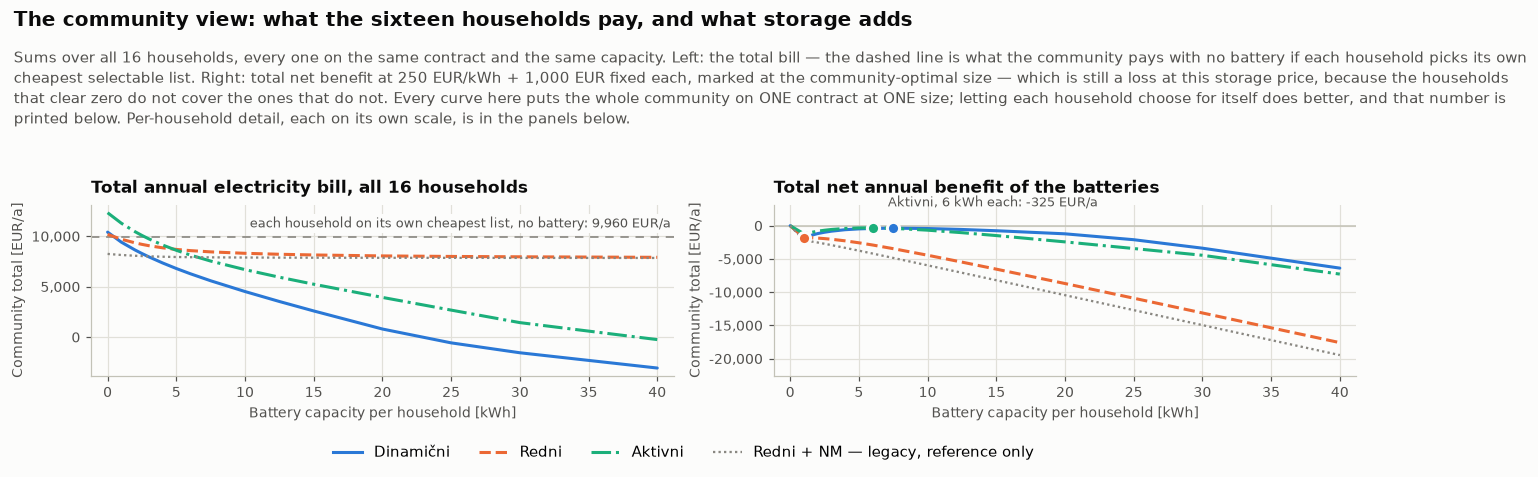

Community totals at the size that maximizes the community net benefit:
     Dinamični:   7.5 kWh each -> bill    10,411 ->     5,588 EUR/a, net      -374 EUR/a across the community
         Redni:   1.0 kWh each -> bill    10,187 ->     9,708 EUR/a, net    -1,777 EUR/a across the community
       Aktivni:   6.0 kWh each -> bill    12,334 ->     8,146 EUR/a, net      -325 EUR/a across the community
    Redni + NM:   1.0 kWh each -> bill     8,250 ->     8,145 EUR/a, net    -2,193 EUR/a across the community  (legacy)
   free choice: each household on its own best selectable contract and size -> net -164 EUR/a, 6 of 16 in profit


In [143]:
### The whole community on one pair of axes
# The per-household panels below answer "what should THIS household do", each on
# its own scale. This figure answers the other question — what the sixteen do
# together — and it is the only one where the levels are comparable, because a
# sum is the one aggregate that does not care that the households are different
# sizes. A median of sixteen absolute bills would be a statement about how big
# the middle household is, not about the contracts.
#
# Both panels are the same x and the same sixteen runs; they are two panels
# rather than one because EUR/a of bill and EUR/a of net benefit are different
# measures, and putting them on one axis with two scales would invent a
# relationship between them.
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
peaks = {}
totals = (
    df.groupby(["Contract", "Capacity_kWh"], observed=True)[["Cost_EUR", "Net_Annual_EUR"]]
    .sum()
)

for ax, (value, title, ylabel) in zip(axes, [
    ("Cost_EUR", f"Skupni letni račun za elektriko, vseh {len(LABEL_ORDER)} gospodinjstev",
     "Skupnost skupaj [EUR/a]"),
    ("Net_Annual_EUR", "Skupna neto letna korist baterij",
     "Skupnost skupaj [EUR/a]"),
]):
    for contract in CONTRACT_ORDER:
        # Both curves start at the 0 kWh solve. On the right that point is zero
        # by construction — no battery, no saving, no capex — and it is exactly
        # the baseline the rest of the curve is measured against, so it belongs
        # on the axis rather than being trimmed off it.
        series = totals[value].loc[contract].sort_index()
        ax.plot(series.index, series.values, color=CONTRACT_COLOR[contract],
                ls=CONTRACT_DASH[contract], lw=CONTRACT_LW[contract],
                solid_capstyle="round", zorder=3)
        # Mark the peak of every selectable curve; label only the winning one.
        # All three peaks sit within a couple of kWh of each other at the top of
        # the panel, so three labels collide with each other and with the title —
        # and the reader wants the one number anyway. The rest are printed below.
        if value == "Net_Annual_EUR" and contract in CURRENT_CONTRACT_ORDER:
            sized = series[series.index > 0]
            top_cap = sized.idxmax()
            peaks[contract] = (top_cap, float(series.loc[top_cap]))
            ax.plot([top_cap], [series.loc[top_cap]], marker="o", ms=8,
                    color=CONTRACT_COLOR[contract], mec=SURFACE, mew=2, zorder=4)
    ax.set_title(title)
    ax.set_xlabel("Kapaciteta baterije na gospodinjstvo [kWh]")
    ax.set_ylabel(ylabel)
    ax.yaxis.set_major_formatter(EUR)
    ax.margins(x=0.03)

axes[1].axhline(0, color=BASELINE, lw=1.0, zorder=1)
axes[1].margins(y=0.16)          # headroom for the label, which sits at the top
win_contract, (win_cap, win_net) = max(peaks.items(), key=lambda kv: kv[1][1])
axes[1].annotate(f"{win_contract}, po {win_cap:g} kWh: {win_net:+,.0f} EUR/a",
                 xy=(win_cap, win_net), xytext=(10, 12), textcoords="offset points",
                 ha="left", va="bottom", fontsize=8.5, color=INK_2, zorder=5)
best_no_batt = float(no_batt[NO_BATTERY_CONTRACT_ORDER].min(axis=1).sum())
axes[0].axhline(best_no_batt, color=MUTED, lw=1.1, ls=(0, (5, 4)), zorder=2)
edge_label(axes[0], best_no_batt,
           f"vsako gospodinjstvo na svojem najcenejšem paketu, brez baterije: {best_no_batt:,.0f} EUR/a")

chart_frame(fig, "Pogled skupnosti: koliko gospodinjstva plačajo in kaj prinese hramba",
      f"Vsote po vseh {len(LABEL_ORDER)} gospodinjstvih, vsa na isti pogodbi in isti "
      f"kapaciteti. Levo: skupni račun — črtkana črta je znesek, ki ga skupnost plača brez "
      f"baterij, če vsako gospodinjstvo izbere svoj najcenejši paket. Desno: skupna neto korist "
      f"pri {CAPEX_EUR_PER_KWH:,.0f} EUR/kWh + {CAPEX_FIXED_EUR:,.0f} EUR fiksno na "
      f"gospodinjstvo, označena pri velikosti, ki je optimalna za skupnost — pri tej ceni "
      f"hrambe je to še vedno izguba, ker gospodinjstva nad ničlo ne pokrijejo tistih pod njo. "
      f"Vsaka krivulja postavi celotno skupnost na ENO pogodbo in ENO velikost; če vsako "
      f"gospodinjstvo izbira zase, je izid boljši in ta številka je izpisana spodaj. "
      f"Podrobnosti po gospodinjstvih, vsako na svoji skali, so na spodnjih grafih.")
plt.show()

print(f"Community totals at the size that maximizes the community net benefit:")
for contract in CONTRACT_ORDER:
    series = totals["Net_Annual_EUR"].loc[contract]
    series = series[series.index > 0]
    cap = series.idxmax()
    cost0 = float(totals["Cost_EUR"].loc[(contract, 0.0)])
    tag = "  (legacy)" if contract in LEGACY_CONTRACTS else ""
    print(f"  {contract:>12}: {cap:5.1f} kWh each -> bill "
          f"{cost0:9,.0f} -> {float(totals['Cost_EUR'].loc[(contract, cap)]):9,.0f} EUR/a, "
          f"net {series.loc[cap]:+9,.0f} EUR/a across the community{tag}")
# The curves hold the community to one contract and one size. Each household is
# free to pick both, and that is the number a real community would reach.
print(f"  {'free choice':>12}: each household on its own best selectable contract and size -> "
      f"net {headline['Net_Annual_EUR'].sum():+,.0f} EUR/a, "
      f"{int((headline['Net_Annual_EUR'] > 0).sum())} of {len(LABEL_ORDER)} in profit")

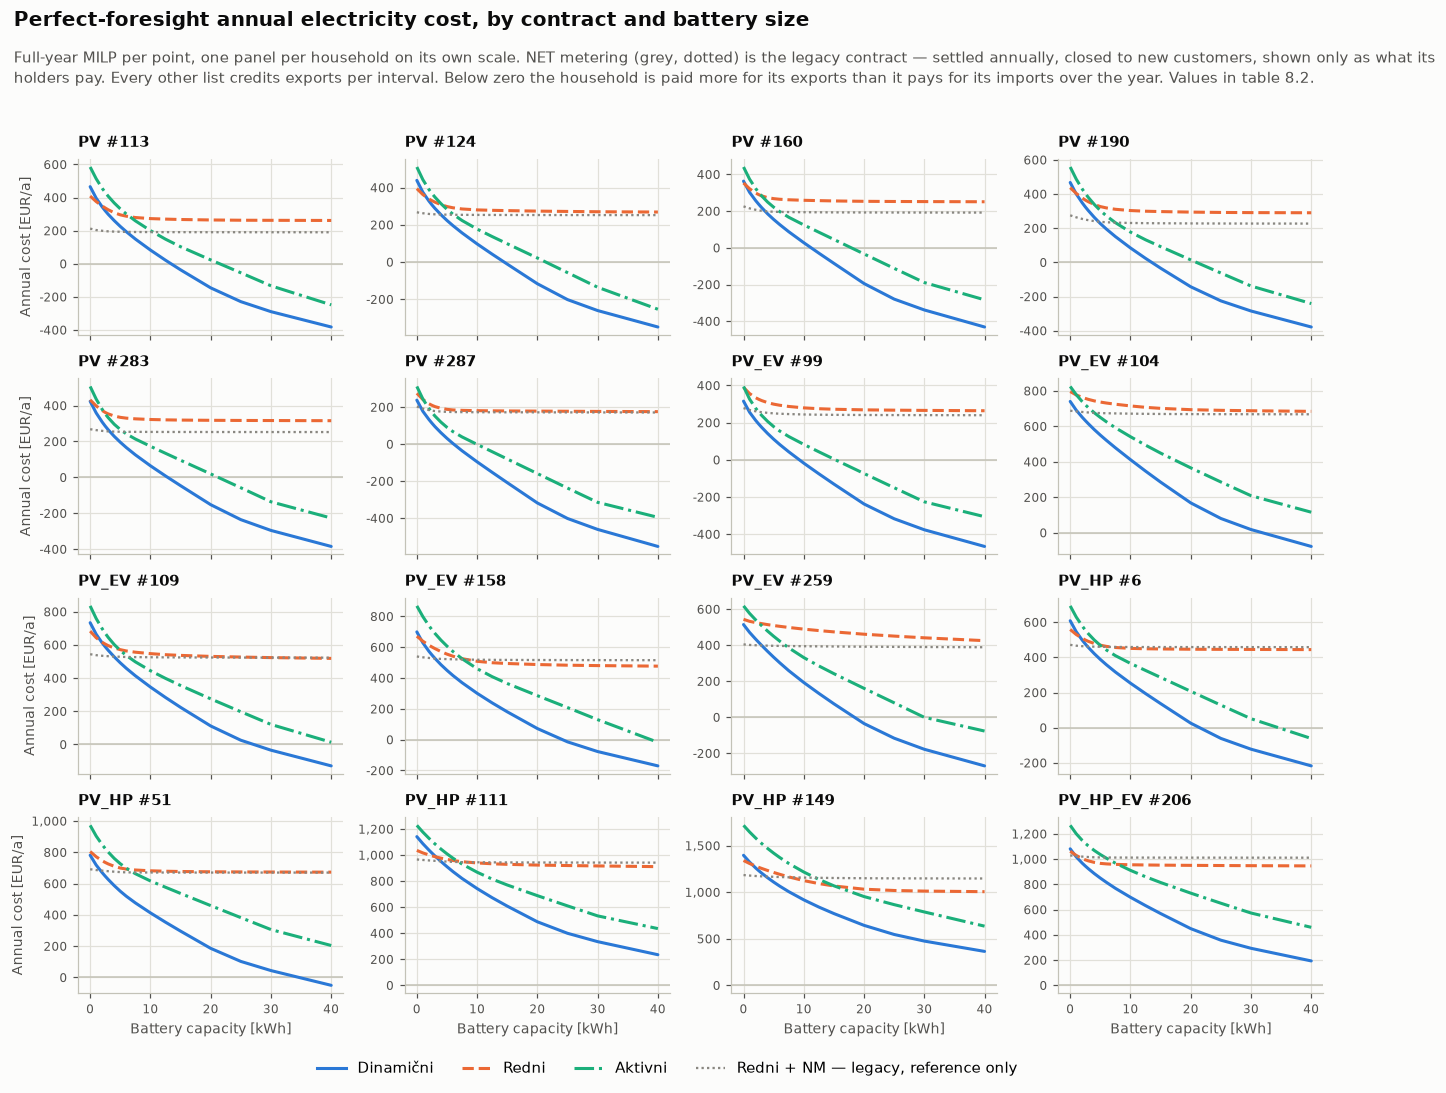

In [144]:
### Annual electricity cost vs battery size
# Independent y per panel, as everywhere in section 9: these households run from
# a ~400 EUR/a bill to a ~1,300 EUR/a one, and a common scale would flatten the
# small ones into straight lines. The comparison this figure is for is between
# contracts within a panel, not between panels.
# The 0 kWh-only lists are shown HERE and nowhere else in section 9: this is the
# figure about the bill, and for a household with no self-supply device the
# plain two-tariff point at x = 0 is the bill it actually pays today. On the
# net-benefit and cycle figures that point is 0 by construction and would only
# add a dot on the zero line.
small_multiples(
    "Cost_EUR",
    "Letni strošek elektrike ob popolnem predvidevanju, po pogodbi in velikosti baterije",
    "Celoletni MILP na točko, en graf na gospodinjstvo, vsak na svoji skali. NET meritve (sivo, "
    "pikčasto) so zaprta pogodba — obračun letno, za nove odjemalce ni več na voljo, prikazane "
    "so le kot strošek tistih, ki jo že imajo. Vsi drugi paketi priznavajo oddajo po "
    "intervalih. Pod ničlo gospodinjstvo za oddano energijo čez leto prejme več, kot plača za "
    "prevzeto. Vrednosti so v tabeli 8.2.",
    "Letni strošek [EUR/a]",
    zero_line=True,
    baselines=BASELINE_CONTRACTS,
)

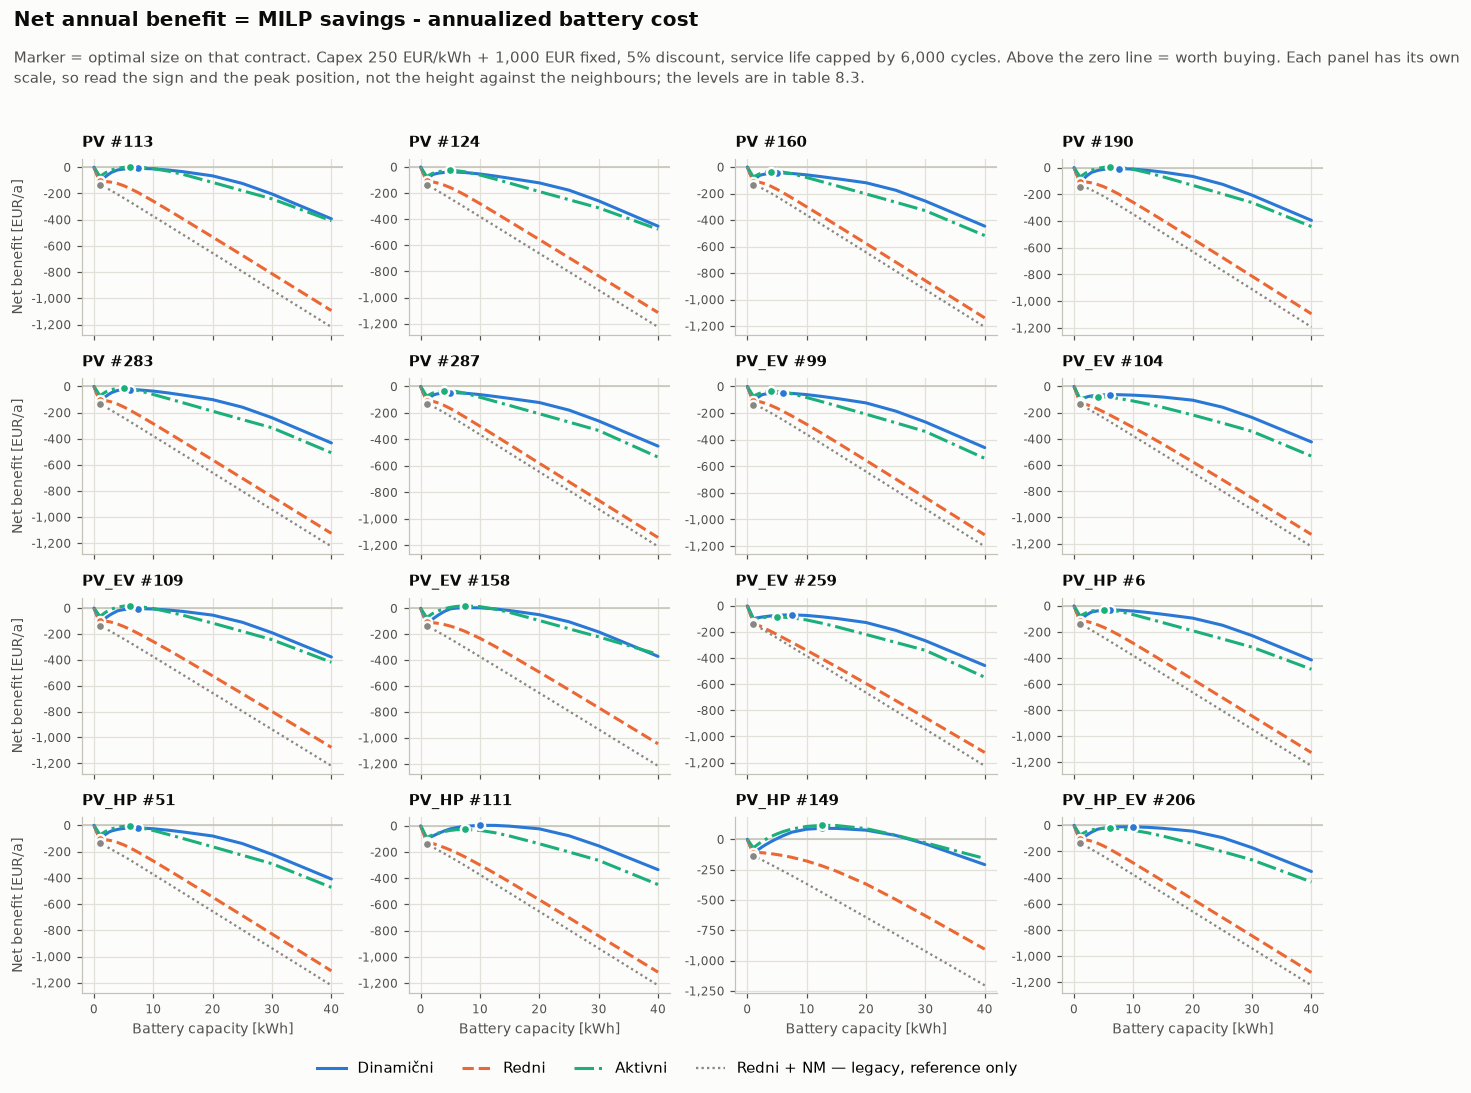

In [145]:
### Net annual benefit — the optimal size is the peak of each curve
small_multiples(
    "Net_Annual_EUR",
    "Neto letna korist = prihranek MILP - letni strošek baterije",
    f"Oznaka = optimalna velikost pri tej pogodbi. Investicija {CAPEX_EUR_PER_KWH:,.0f} EUR/kWh "
    f"+ {CAPEX_FIXED_EUR:,.0f} EUR fiksno, {DISCOUNT_RATE:.0%} diskontna stopnja, življenjska "
    f"doba omejena z {BATTERY_CYCLE_LIMIT_EFC:,} cikli. Nad ničelno črto = nakup se izplača. "
    f"Vsak graf ima svojo skalo, zato berite predznak in lego vrha, ne višine glede na sosede; "
    f"ravni so v tabeli 8.3.",
    "Neto korist [EUR/a]",
    zero_line=True,
    mark_optimum=True,
)

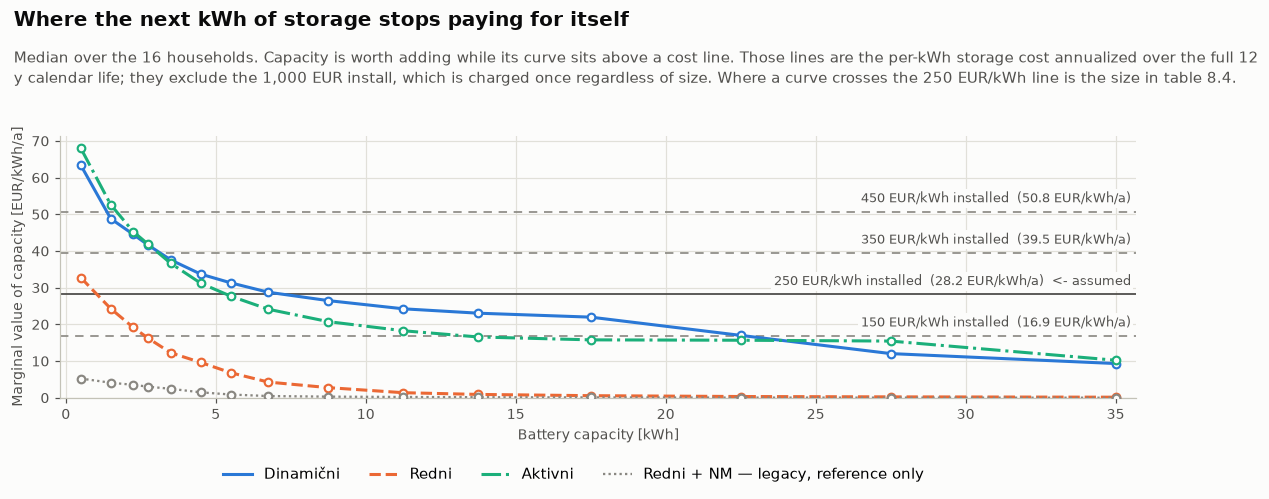

In [146]:
### Where the next kWh of storage stops paying for itself
fig, ax = plt.subplots(figsize=(10.5, 4.6))
marginal = (
    df.dropna(subset=["Marginal_Value_EUR_per_kWh"])
    .groupby(["Contract", "Capacity_kWh"], observed=True)["Marginal_Value_EUR_per_kWh"]
    .median()
)
# Plotted at the midpoint of the interval the difference was taken over.
caps = np.sort(df["Capacity_kWh"].unique())
midpoints = dict(zip(caps[1:], (caps[1:] + caps[:-1]) / 2))

crf_ref = capital_recovery_factor(DISCOUNT_RATE, BATTERY_CALENDAR_LIFE_Y)
# Cost lines first, so the curves and their markers sit on top of them. The
# assumed price gets a solid line; the rest of the scenarios are dashed.
for capex_per_kwh in sorted(set(CAPEX_SCENARIOS_EUR_PER_KWH) | {CAPEX_EUR_PER_KWH}):
    assumed = capex_per_kwh == CAPEX_EUR_PER_KWH
    level = capex_per_kwh * crf_ref
    ax.axhline(level, color=INK_2 if assumed else MUTED, lw=1.2 if assumed else 1.1,
               ls="-" if assumed else (0, (5, 4)), zorder=1)
    edge_label(ax, level, f"{capex_per_kwh:,.0f} EUR/kWh vgrajene kapacitete  ({level:,.1f} EUR/kWh/a)"
                          + ("  <- predpostavljeno" if assumed else ""))

for contract in CONTRACT_ORDER:
    series = marginal.loc[contract]
    ax.plot([midpoints[c] for c in series.index], series.values,
            color=CONTRACT_COLOR[contract], ls=CONTRACT_DASH[contract], lw=CONTRACT_LW[contract],
            marker="o", ms=5, mfc=SURFACE, mew=1.4, zorder=3)

ax.set_ylim(bottom=0)
ax.margins(x=0.02)
ax.set_xlabel("Kapaciteta baterije [kWh]")
ax.set_ylabel("Mejna vrednost kapacitete [EUR/kWh/a]")
ax.yaxis.set_major_formatter(PLAIN)
chart_frame(fig, "Kje se naslednja kWh hrambe ne izplača več",
      f"Mediana po {len(LABEL_ORDER)} gospodinjstvih. Kapaciteto se splača dodajati, dokler je "
      f"njena krivulja nad črto stroška. Te črte so strošek hrambe na kWh, porazdeljen na leto "
      f"čez celotno {BATTERY_CALENDAR_LIFE_Y}-letno koledarsko dobo; ne vključujejo "
      f"{CAPEX_FIXED_EUR:,.0f} EUR vgradnje, ki se zaračuna enkrat ne glede na velikost. Kjer "
      f"krivulja seka črto {CAPEX_EUR_PER_KWH:,.0f} EUR/kWh, je velikost iz tabele 8.4.")
plt.show()

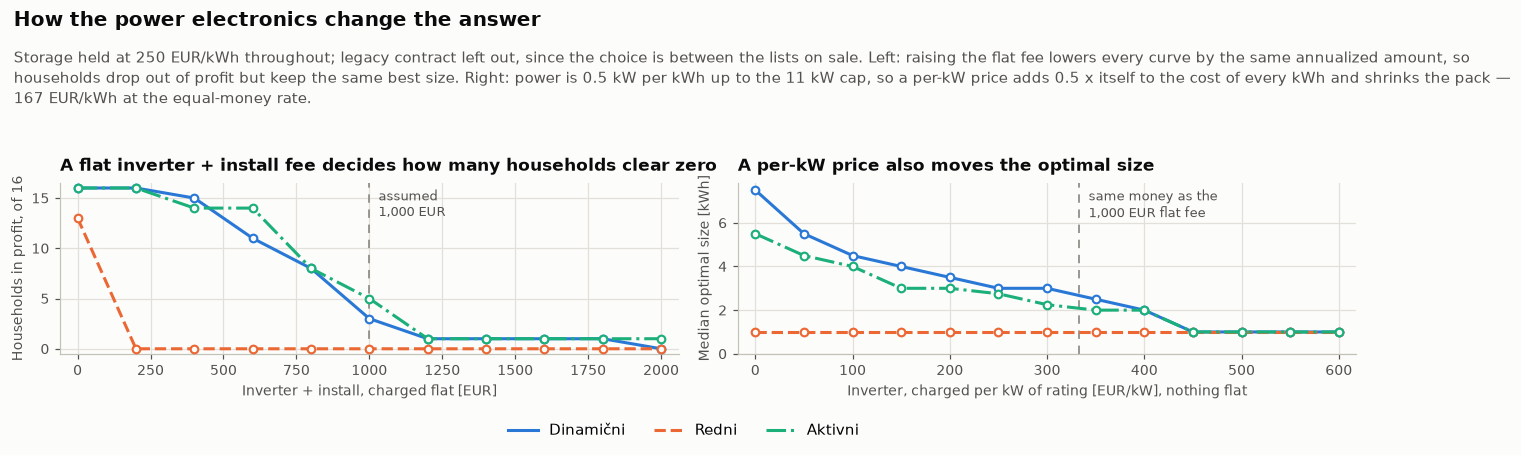

In [147]:
### What the inverter costs the case for a battery
# Left and right are deliberately different x axes: a flat fee and a per-kW price
# do different things, and that difference is the point of the figure. A flat fee
# only moves the vertical position of the curve, so it decides HOW MANY households
# clear zero; a per-kW price is charged on power, which scales with capacity, so
# it also moves WHERE the peak sits. Tables 8.5a-c.
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))

# One solve of the capex model per x value, read off for all three contracts,
# rather than one per (contract, x).
n_profit = {c: [] for c in CURRENT_CONTRACT_ORDER}
med_kwh = {c: [] for c in CURRENT_CONTRACT_ORDER}
for fixed_eur in INVERTER_FIXED_FINE_EUR:
    top = optimum_capex(CAPEX_EUR_PER_KWH, fixed_eur)
    for contract in CURRENT_CONTRACT_ORDER:
        n_profit[contract].append(int((top.xs(contract, level="Contract")["Net"] > 0).sum()))
for per_kw in INVERTER_PER_KW_FINE:
    top = optimum_capex(CAPEX_EUR_PER_KWH, fixed_eur=0.0, eur_per_kw=per_kw)
    for contract in CURRENT_CONTRACT_ORDER:
        med_kwh[contract].append(
            float(top.xs(contract, level="Contract")["Capacity_kWh"].median())
        )

for contract in CURRENT_CONTRACT_ORDER:
    axes[0].plot(INVERTER_FIXED_FINE_EUR, n_profit[contract], color=CONTRACT_COLOR[contract],
                 ls=CONTRACT_DASH[contract], lw=CONTRACT_LW[contract],
                 marker="o", ms=5, mfc=SURFACE, mew=1.4, zorder=3)
    axes[1].plot(INVERTER_PER_KW_FINE, med_kwh[contract], color=CONTRACT_COLOR[contract],
                 ls=CONTRACT_DASH[contract], lw=CONTRACT_LW[contract],
                 marker="o", ms=5, mfc=SURFACE, mew=1.4, zorder=3)

axes[0].axvline(CAPEX_FIXED_EUR, color=MUTED, lw=1.1, ls=(0, (5, 4)), zorder=2)
axes[0].annotate(f"predpostavljeno\n{CAPEX_FIXED_EUR:,.0f} EUR", xy=(CAPEX_FIXED_EUR, 0.97),
                 xycoords=("data", "axes fraction"), xytext=(6, 0),
                 textcoords="offset points", ha="left", va="top",
                 fontsize=8.5, color=INK_2, zorder=5)
axes[0].set_title("Fiksna cena razsmernika in vgradnje določa, koliko gospodinjstev preseže ničlo")
axes[0].set_xlabel("Razsmernik + vgradnja, fiksni znesek [EUR]")
axes[0].set_ylabel(f"Gospodinjstev v dobičku, od {len(LABEL_ORDER)}")
axes[0].set_ylim(-0.5, len(LABEL_ORDER) + 0.5)

axes[1].axvline(EQUAL_MONEY_EUR_PER_KW, color=MUTED, lw=1.1, ls=(0, (5, 4)), zorder=2)
axes[1].annotate(f"enak znesek kot\n{CAPEX_FIXED_EUR:,.0f} EUR fiksno",
                 xy=(EQUAL_MONEY_EUR_PER_KW, 0.97), xycoords=("data", "axes fraction"),
                 xytext=(6, 0), textcoords="offset points", ha="left", va="top",
                 fontsize=8.5, color=INK_2, zorder=5)
axes[1].set_title("Cena na kW premakne tudi optimalno velikost")
axes[1].set_xlabel("Razsmernik, obračunan po kW nazivne moči [EUR/kW], brez fiksnega dela")
axes[1].set_ylabel("Mediana optimalne velikosti [kWh]")
axes[1].set_ylim(bottom=0)

for ax in axes:
    ax.margins(x=0.03)
    ax.yaxis.set_major_formatter(PLAIN)

chart_frame(fig, "Kako močnostna elektronika spremeni odgovor",
      f"Hramba je ves čas pri {CAPEX_EUR_PER_KWH:,.0f} EUR/kWh; zaprta pogodba je izpuščena, "
      f"ker gre za izbiro med paketi v ponudbi. Levo: višji fiksni znesek zniža vsako krivuljo "
      f"za enak letni znesek, zato gospodinjstva padejo iz dobička, najboljša velikost pa "
      f"ostane ista. Desno: moč je {C_RATE:g} kW na kWh do meje {INVERTER_MAX_KW:g} kW, zato "
      f"cena na kW vsaki kWh doda {C_RATE:g}-kratnik te cene in zmanjša baterijo — "
      f"{C_RATE * EQUAL_MONEY_EUR_PER_KW:,.0f} EUR/kWh pri enakovrednem znesku.",
      handles=[plt.Line2D([], [], color=CONTRACT_COLOR[c], ls=CONTRACT_DASH[c],
                          lw=CONTRACT_LW[c], label=CONTRACT_LABEL[c])
               for c in CURRENT_CONTRACT_ORDER],
      ncol=3)
plt.show()

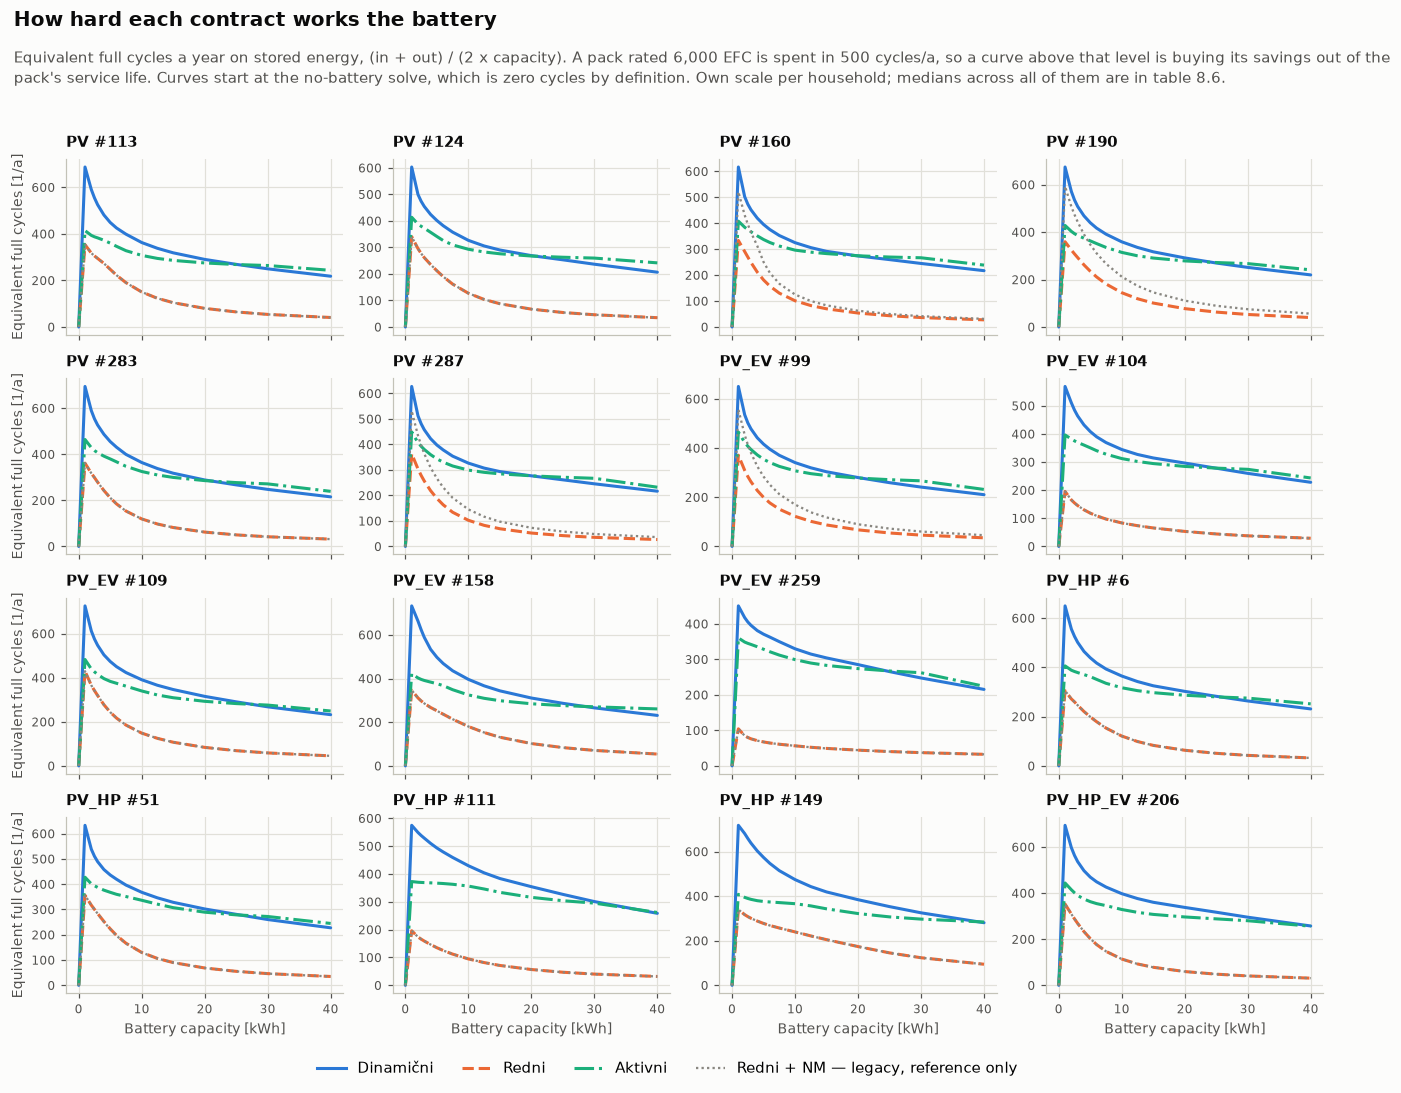

In [148]:
### Equivalent full cycles per year
# The curve starts at the 0 kWh solve — no battery, no cycles — so the first
# segment is a steep climb into the 1 kWh point. That steepness is the finding,
# not an artefact: the first kWh of storage is cycled hardest, because it is the
# part that gets used every single day.
small_multiples(
    "Equivalent_Full_Cycles",
    "Kako močno vsaka pogodba obremeni baterijo",
    f"Ekvivalentni polni cikli na leto glede na shranjeno energijo, (noter + ven) / (2 x "
    f"kapaciteta). Baterija z oceno {BATTERY_CYCLE_LIMIT_EFC:,} EFC je izrabljena pri "
    f"{BATTERY_CYCLE_LIMIT_EFC // BATTERY_CALENDAR_LIFE_Y} ciklih/leto, zato krivulja nad to "
    f"ravnjo kupuje prihranke na račun življenjske dobe baterije. Krivulje se začnejo pri "
    f"izračunu brez baterije, kjer je ciklov po definiciji nič. Vsako gospodinjstvo ima svojo "
    f"skalo; mediane po vseh so v tabeli 8.6.",
    "Ekvivalentni polni cikli [1/leto]",
    fmt=PLAIN,
)

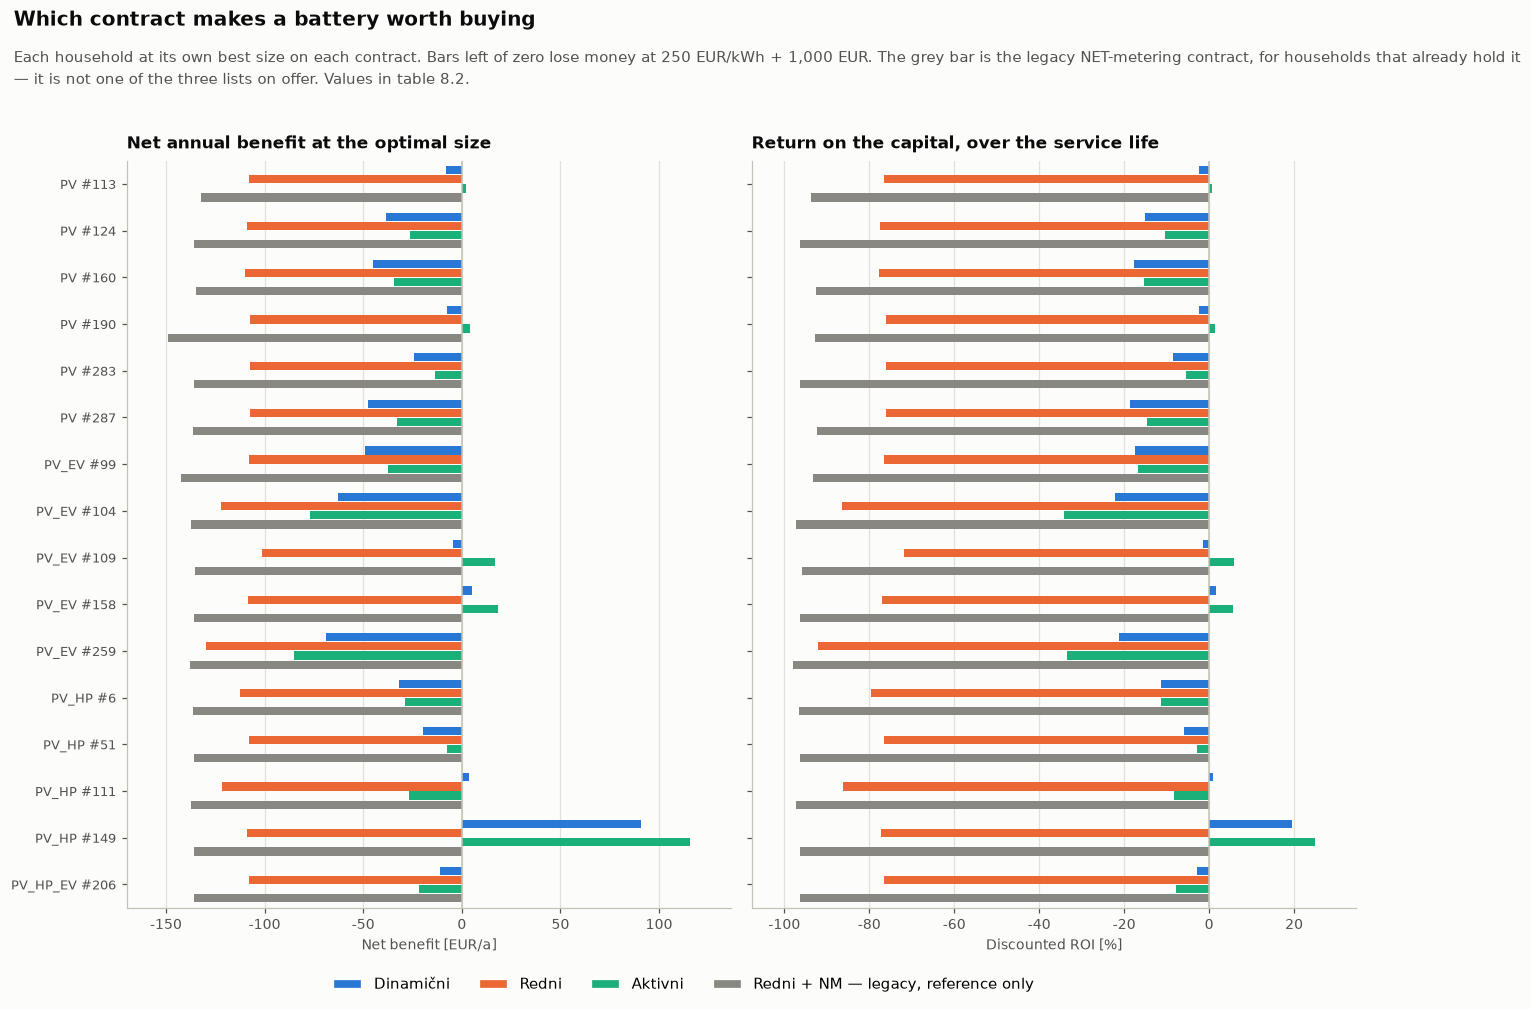

In [149]:
### The headline comparison: net annual benefit at each household's optimal size
# Horizontal bars, one row per household. Vertical grouped bars put N x 4 bars
# and N household names on a shared x axis; past about six households the names
# collide and the bars are a couple of points wide. Rotating the labels only
# trades one unreadable axis for another. Turned on its side, the household name
# is a full-length horizontal label whatever the count, and the figure grows
# downwards — which a notebook scrolls anyway.
n = len(LABEL_ORDER)
# Height scales with the number of BARS, not the number of households: nine
# contracts in the same 0.44 in row that used to hold four gives each bar two
# points of vertical space, which is thinner than the line around it.
BAR_IN = 0.115
fig, axes = plt.subplots(1, 2, figsize=(12.5, BAR_IN * len(CONTRACT_ORDER) * n + 2.6),
                         sharey=True)
y = np.arange(n)
height = 0.84 / len(CONTRACT_ORDER)

for ax, (value, xlabel, fmt, panel_title) in zip(axes, [
    ("Net_Annual_EUR", "Neto korist [EUR/a]", EUR, "Neto letna korist pri optimalni velikosti"),
    ("ROI_pct", "Diskontirani ROI [%]", PLAIN, "Donos na vloženi kapital čez življenjsko dobo"),
]):
    for i, contract in enumerate(CONTRACT_ORDER):
        # NaN where the household was never quoted the list — matplotlib draws
        # no bar for it, which is the honest mark: not a zero benefit, no offer.
        cells = [
            best_table.loc[(best_table["Label"] == lab)
                           & (best_table["Contract"] == contract), value]
            for lab in LABEL_ORDER
        ]
        vals = [float(c.iloc[0]) if len(c) else np.nan for c in cells]
        # Offsets run downwards so the bar order inside a group matches the
        # legend order top to bottom (the y axis is inverted below).
        ax.barh(y + (i - (len(CONTRACT_ORDER) - 1) / 2) * height, vals, height * 0.9,
                color=CONTRACT_COLOR[contract], zorder=2)
    ax.axvline(0, color=BASELINE, lw=1.0, zorder=3)
    ax.set_xlabel(xlabel)
    ax.set_title(panel_title)
    ax.xaxis.set_major_formatter(fmt)
    ax.margins(x=0.08)
    ax.grid(axis="y", visible=False)

axes[0].set_yticks(y, LABEL_ORDER, fontsize=8.5)
axes[0].set_ylim(n - 0.5, -0.5)          # first household at the top
chart_frame(fig, "Pri kateri pogodbi se nakup baterije izplača",
      f"Vsako gospodinjstvo pri svoji najboljši velikosti na vsaki pogodbi. Stolpci levo od "
      f"ničle pri {CAPEX_EUR_PER_KWH:,.0f} EUR/kWh + {CAPEX_FIXED_EUR:,.0f} EUR pomenijo "
      f"izgubo. Vsak produkt nastopa dvakrat, enkrat v obliki samooskrba in enkrat brez odkupa; "
      f"par si deli barvo. Sivi stolpec je zaprta pogodba NET meritve, za gospodinjstva, ki jo "
      f"že imajo — ni med paketi v ponudbi, gospodinjstva brez proizvodnje pa zanjo nimajo "
      f"stolpca. Vrednosti so v tabeli 8.2.",
      handles=contract_handles("bar"))
plt.show()

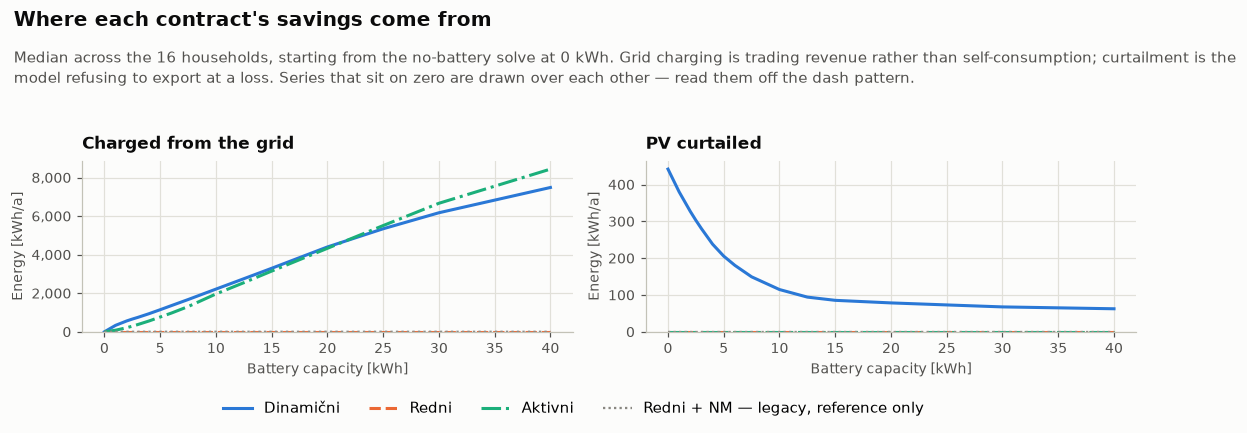

In [150]:
### What the battery actually does: throughput and curtailment
# Peak import used to be the third panel here; it is the whole of the next
# figure now, where there is room for the no-battery and contracted-power
# references that make a kW number mean anything.
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0))
# Including 0 kWh: grid charging is zero there by definition, but curtailment is
# not — a household with no store already spills PV it cannot export at a profit,
# and that level is what the curve should be read against.
grouped = df.groupby(["Contract", "Capacity_kWh"], observed=True)

for ax, (value, title, ylabel) in zip(axes, [
    ("Grid_Charged_kWh", "Napolnjeno iz omrežja", "Energija [kWh/a]"),
    ("Curtailed_kWh", "Zavrnjena proizvodnja PV", "Energija [kWh/a]"),
]):
    for contract in CONTRACT_ORDER:
        series = grouped[value].median().loc[contract]
        ax.plot(series.index, series.values, color=CONTRACT_COLOR[contract],
                ls=CONTRACT_DASH[contract], lw=CONTRACT_LW[contract])
    ax.set_title(title)
    ax.set_xlabel("Kapaciteta baterije [kWh]")
    ax.set_ylabel(ylabel)
    ax.set_ylim(bottom=0)
    ax.yaxis.set_major_formatter(PLAIN)

chart_frame(fig, "Od kod prihajajo prihranki pri posamezni pogodbi",
      f"Mediana po {len(LABEL_ORDER)} gospodinjstvih, z začetkom pri izračunu brez baterije pri "
      f"0 kWh. Polnjenje iz omrežja je prihodek iz trgovanja, ne lastna raba; zavrnjena "
      f"proizvodnja je model, ki noče oddajati z izgubo. Krivulje, ki ležijo na ničli, se "
      f"prekrivajo — ločite jih po vzorcu črtkanja.")
plt.show()

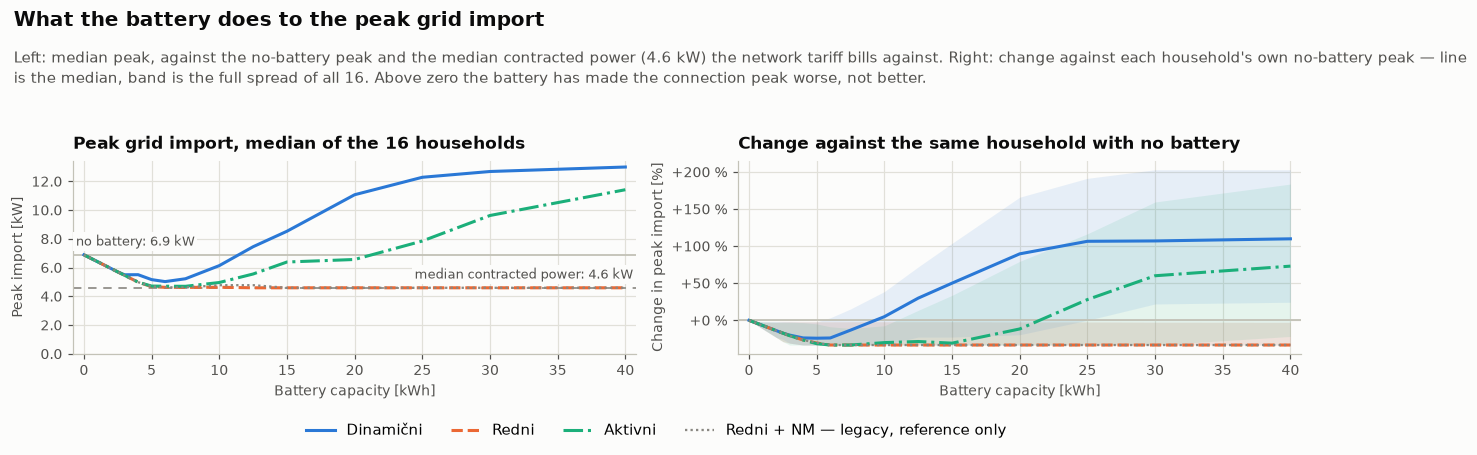

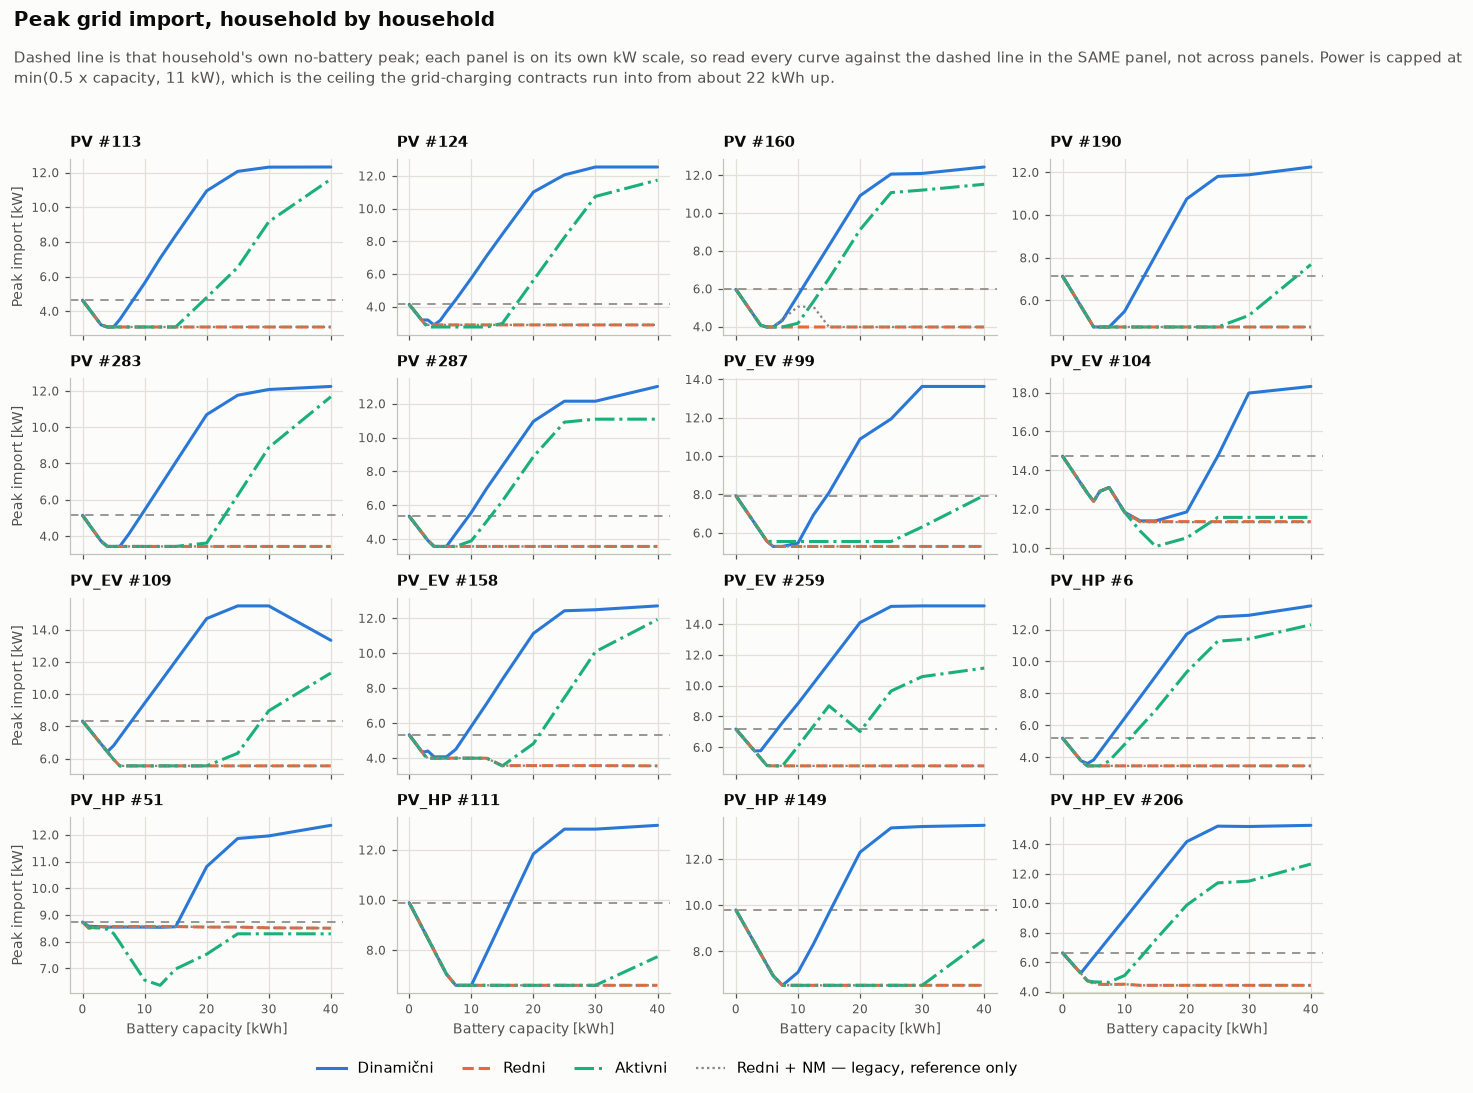

Peak grid import across 16 households x 4 contracts x 15 sized runs
  no battery, summed over the 16 households: 116.1 kW
     Dinamični: median   -5.8 % over all sizes,   98.4 kW summed at the optimal sizes, worst single run +203.0 %
         Redni: median  -32.3 % over all sizes,  108.8 kW summed at the optimal sizes, worst single run   -1.9 %
       Aktivni: median  -21.4 % over all sizes,   84.1 kW summed at the optimal sizes, worst single run +183.6 %
    Redni + NM: median  -31.3 % over all sizes,  108.8 kW summed at the optimal sizes, worst single run   -1.9 %  (legacy)
  worst: PV #124 on Dinamični at 30 kWh — 4.1 -> 12.5 kW (+203.0 %), 5,821 kWh/a of it charged from the grid
  best:  PV #190 on Dinamični at 7.5 kWh — 7.1 -> 4.8 kW (-33.3 %)


In [151]:
### What the battery does to the peak grid import
# The cost curves say what the battery is worth; this says what it does to the
# connection. Peak import is billed against contracted power under the SI network
# tariff, and the block-arbitrage lists charge from the grid at the cheapest hour
# of the day — a load the house never had — so their peak climbs with the
# inverter rating instead of falling with self-consumption.
peak_base = (
    df.loc[df["Capacity_kWh"] == 0.0]
    .set_index(["Label", "Contract"])["Peak_Import_kW"]
)
# 0 kWh included, so both curves start at the no-battery peak: on the left that
# is the kW the connection already sees, on the right it is 0 % by construction.
peaks = df.copy()
peaks["Peak_No_Battery_kW"] = [
    peak_base.loc[(lab, t)] for lab, t in zip(peaks["Label"], peaks["Contract"])
]
peaks["Peak_Change_pct"] = 100.0 * (
    peaks["Peak_Import_kW"] / peaks["Peak_No_Battery_kW"] - 1.0
)

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.2))
by_cap = peaks.groupby(["Contract", "Capacity_kWh"], observed=True)

for contract in CONTRACT_ORDER:
    abs_kw = by_cap["Peak_Import_kW"].median().loc[contract]
    rel = by_cap["Peak_Change_pct"].median().loc[contract]
    lo = by_cap["Peak_Change_pct"].min().loc[contract]
    hi = by_cap["Peak_Change_pct"].max().loc[contract]
    axes[0].plot(abs_kw.index, abs_kw.values, color=CONTRACT_COLOR[contract],
                 ls=CONTRACT_DASH[contract], lw=CONTRACT_LW[contract], zorder=3)
    # Band = the households' spread, so a median cannot hide one runaway.
    axes[1].fill_between(rel.index, lo.values, hi.values, color=CONTRACT_COLOR[contract],
                         alpha=0.10, lw=0, zorder=1)
    axes[1].plot(rel.index, rel.values, color=CONTRACT_COLOR[contract],
                 ls=CONTRACT_DASH[contract], lw=CONTRACT_LW[contract], zorder=3)

base_kw = float(peak_base.groupby(level="Label").median().median())
contracted_kw = float(df.groupby("Label")["Contracted_Power_kW"].first().median())
axes[0].axhline(base_kw, color=BASELINE, lw=1.2, zorder=2)
edge_label(axes[0], base_kw, f"brez baterije: {base_kw:,.1f} kW", side="left")
axes[0].axhline(contracted_kw, color=MUTED, lw=1.1, ls=(0, (5, 4)), zorder=2)
edge_label(axes[0], contracted_kw, f"mediana dogovorjene obračunske moči: {contracted_kw:,.1f} kW")
axes[0].set_title(f"Konica odjema iz omrežja, mediana {len(LABEL_ORDER)} gospodinjstev")
axes[0].set_ylabel("Konica odjema [kW]")
axes[0].set_ylim(bottom=0)
axes[0].yaxis.set_major_formatter(KW)

axes[1].axhline(0, color=BASELINE, lw=1.2, zorder=2)
axes[1].set_title("Sprememba glede na isto gospodinjstvo brez baterije")
axes[1].set_ylabel("Sprememba konice odjema [%]")
axes[1].yaxis.set_major_formatter(PCT)

for ax in axes:
    ax.set_xlabel("Kapaciteta baterije [kWh]")
    ax.margins(x=0.02)

chart_frame(fig, "Kaj baterija naredi s konico odjema iz omrežja",
      f"Levo: mediana konice, ob konici brez baterije in mediani dogovorjene obračunske moči "
      f"({contracted_kw:,.1f} kW), po kateri se obračunava omrežnina. Desno: sprememba glede na "
      f"lastno konico brez baterije — črta je mediana, pas je celoten razpon vseh "
      f"{len(LABEL_ORDER)}. Nad ničlo je baterija konico priključka poslabšala, ne izboljšala.")
plt.show()

### The same thing household by household, each on its own scale
small_multiples(
    "Peak_Import_kW",
    "Konica odjema iz omrežja, po gospodinjstvih",
    f"Črtkana črta je konica tega gospodinjstva brez baterije; vsak graf ima svojo skalo v kW, "
    f"zato berite krivuljo glede na črtkano črto v ISTEM grafu, ne med grafi. Moč je omejena na "
    f"min({C_RATE:g} x kapaciteta, {INVERTER_MAX_KW:g} kW), kar je strop, v katerega pogodbe s "
    f"polnjenjem iz omrežja zadenejo od približno {INVERTER_MAX_KW / C_RATE:g} kWh naprej.",
    "Konica odjema [kW]",
    fmt=KW,
    baseline_col="Peak_Import_kW",
)

### Aggregate and extremes, since a median peak is not what gets billed
# On sized runs only: "the worst run" means the worst battery, and every 0 kWh
# row is a 0.0 % change that would sit in the middle of the ranking and drag the
# medians towards zero.
sized_peaks = peaks[peaks["Capacity_kWh"] > 0]
worst_row = sized_peaks.loc[sized_peaks["Peak_Change_pct"].idxmax()]
best_row = sized_peaks.loc[sized_peaks["Peak_Change_pct"].idxmin()]
print(f"Peak grid import across {len(LABEL_ORDER)} households x {len(CONTRACT_ORDER)} contracts "
      f"x {len(BATTERY_SIZES_KWH) - 1} sized runs")
print(f"  no battery, summed over the {len(LABEL_ORDER)} households: "
      f"{peak_base.groupby(level='Label').median().sum():,.1f} kW")
for contract in CONTRACT_ORDER:
    sub = sized_peaks[sized_peaks["Contract"] == contract]
    at_opt = best_table[best_table["Contract"] == contract]
    tag = "  (legacy)" if contract in LEGACY_CONTRACTS else ""
    print(f"  {contract:>12}: median {sub['Peak_Change_pct'].median():+6.1f} % over all sizes, "
          f"{at_opt['Peak_Import_kW'].sum():6.1f} kW summed at the optimal sizes, "
          f"worst single run {sub['Peak_Change_pct'].max():+6.1f} %{tag}")
print(f"  worst: {worst_row['Label']} on {worst_row['Contract']} at {worst_row['Capacity_kWh']:g} kWh — "
      f"{worst_row['Peak_No_Battery_kW']:.1f} -> {worst_row['Peak_Import_kW']:.1f} kW "
      f"({worst_row['Peak_Change_pct']:+.1f} %), {worst_row['Grid_Charged_kWh']:,.0f} kWh/a of it "
      f"charged from the grid")
print(f"  best:  {best_row['Label']} on {best_row['Contract']} at {best_row['Capacity_kWh']:g} kWh — "
      f"{best_row['Peak_No_Battery_kW']:.1f} -> {best_row['Peak_Import_kW']:.1f} kW "
      f"({best_row['Peak_Change_pct']:+.1f} %)")

## 10. Read-out

In [152]:
lines = [
    f"{len(LABEL_ORDER)} households, split evenly over {len(PV_DATASETS)} Fluvius families "
    f"({', '.join(PV_DATASETS)}), calendar year 2024",
    f"{N_STEPS_FULL_YEAR:,} intervals of {step_minutes:.0f} min each — the whole year, every run",
    f"{len(ALL_CONTRACT_ORDER)} GEN-I price lists x up to {len(BATTERY_SIZES_KWH)} capacities "
    f"({BATTERY_SIZES_KWH.min():.0f}-{BATTERY_SIZES_KWH.max():.0f} kWh) = {len(df)} full-year "
    f"MILPs, the price lists a household cannot be quoted left out",
    f"Selectable and swept: {', '.join(CURRENT_CONTRACT_ORDER)}.  Selectable at 0 kWh only: "
    f"{', '.join(BASELINE_CONTRACTS)} — plain two-tariff supply, what a household with no "
    f"self-supply device pays before it installs anything",
    f"Legacy, reference only: {', '.join(LEGACY_CONTRACTS)} — closed to new contracts, so it "
    f"never wins anything below; and out of reach entirely without production",
    f"{sum(HAS_PV.values())} of {len(HOUSEHOLD_KEYS)} households have a self-supply device",
    f"Storage at {CAPEX_EUR_PER_KWH:,.0f} EUR/kWh + {CAPEX_FIXED_EUR:,.0f} EUR fixed, "
    f"r = {DISCOUNT_RATE:.0%}",
    f"SI tariff regime {PRICING_REFERENCE_YEAR}, peak reset {PEAK_RESET_MONTHS or 'never (annual ratchet)'}",
    "",
    "WITHOUT A BATTERY",
]
for label in LABEL_ORDER:
    r = no_batt.loc[label]
    legacy_bits = "  ".join(
        f"[{leg} {float(r[leg]):,.2f}, {float(r[f'{leg} - best_EUR']):+,.2f} vs best]"
        for leg in LEGACY_CONTRACTS
    )
    lines.append(
        f"  {label:>16}: cheapest {str(r['Cheapest']):<24} "
        f"{float(r['Cheapest_EUR']):8,.2f} EUR/a"
        f"   (spread across the {len(CURRENT_CONTRACT_ORDER)} selectable lists "
        f"{float(r['Spread_EUR']):7,.2f} EUR/a)  {legacy_bits}"
    )

lines += ["", "WITH THE BEST BATTERY THE BEST SELECTABLE CONTRACT SUPPORTS"]
for _, r in headline.iterrows():
    lines.append(
        f"  {r['Household']:>16}: {str(r['Best_contract_with_battery']):<12} "
        f"{r['Optimal_kWh']:5.1f} kWh -> saves {r['Savings_EUR']:8,.2f} EUR/a, "
        f"net {r['Net_Annual_EUR']:+8,.2f} EUR/a, ROI {r['ROI_pct']:+7.1f} %, "
        f"payback {r['Payback_y']:5.1f} y, {r['Cycles_per_year']:5.0f} cycles/a "
        f"[pays: {r['Battery_pays']}; storage cost only: {r['Pays_storage_only']}]"
    )

n_pays = int((headline["Battery_pays"] == "yes").sum())
n_storage = int((headline["Pays_storage_only"] == "yes").sum())
edge = best_table[best_table["Optimum_At_Grid_Edge"] != ""]
lines += [
    "",
    f"  -> {n_pays} of {len(headline)} households have ANY capacity with a positive net annual "
    f"benefit at {CAPEX_EUR_PER_KWH:,.0f} EUR/kWh + {CAPEX_FIXED_EUR:,.0f} EUR fixed.",
    f"  -> {n_storage} of {len(headline)} do once the {CAPEX_FIXED_EUR:,.0f} EUR install is "
    f"treated as sunk and only the storage is charged for — that fixed term, not the",
    f"     per-kWh price, is what decides it at these sizes.",
]
if len(edge):
    lines.append(
        f"  -> {len(edge)} of {len(best_table)} (household, contract) optima sit on the edge of the "
        f"swept grid ({SMALLEST_SIZED:g}-{LARGEST_SIZED:g} kWh), so the grid rather than the"
    )
    lines.append("     economics is picking those sizes — read them as 'as small as swept', not as an optimum.")

lines += ["", "THE LEGACY CONTRACT — for households already on NET metering, not a baseline"]
for legacy in LEGACY_CONTRACTS:
    # dropna: a household with no production was never quoted this list, so it
    # is not one of the households the shares below are out of.
    cost_delta = no_batt[f"{legacy} - best_EUR"].dropna()   # negative = legacy bill is lower
    leg_rows = best_table[best_table["Contract"] == legacy]
    pad = " " * (len(legacy) + 2)
    lines.append(
        f"  {legacy}: THE BILL — cheaper than the best selectable list for "
        f"{int((cost_delta < 0).sum())} of the {len(cost_delta)} households that can hold it, by "
        f"{-cost_delta.median():,.2f} EUR/a at the median"
    )
    lines.append(
        f"{pad}(worst case for the holder {-cost_delta.max():,.2f}, best "
        f"{-cost_delta.min():,.2f}). That is what ending the contract costs them."
    )
    lines.append(
        f"{pad}THE BATTERY — worth {leg_rows['Savings_EUR'].median():,.2f} EUR/a at the median "
        f"optimum of {leg_rows['Capacity_kWh'].median():.1f} kWh, against "
        f"{headline['Savings_EUR'].median():,.2f} EUR/a on the best"
    )
    lines.append(
        f"{pad}selectable list. Annual netting already credits exported energy at the same "
        f"supplier price the household buys at, so a battery has no"
    )
    lines.append(
        f"{pad}energy spread left to capture on this list — only the network charge and the "
        f"peak, which is close to nothing here. Storage and NET"
    )
    lines.append(
        f"{pad}metering are substitutes, not complements: while the contract lasts it is doing "
        f"the battery's job. Size the pack for the selectable"
    )
    lines.append(
        f"{pad}list the household falls back to when the contract ends — that is the row above, "
        f"not this one."
    )

lines += ["", "SAMOOSKRBA AGAINST BREZ ODKUPA — the same product, quoted both ways"]
lines.append(
    "  Two questions per product: what the export credit is worth on the bill with no battery, "
    "and whether it changes what the battery is worth."
)
PV_LABELS = [HOUSEHOLD_LABELS[k] for k in HOUSEHOLD_KEYS if HAS_PV[k]]
NO_PV_LABELS = [HOUSEHOLD_LABELS[k] for k in HOUSEHOLD_KEYS if not HAS_PV[k]]
for product in PAIRED_PRODUCTS:
    samo, plain = CONTRACT_PAIRS[product][True], CONTRACT_PAIRS[product][False]
    # Positive = the samooskrba form is the cheaper bill / the better battery.
    bill = (no_batt[plain] - no_batt[samo]).dropna()
    net_at_opt = (
        best_table.set_index(["Label", "Contract"])["Net_Annual_EUR"]
        .unstack("Contract")
        .pipe(lambda d: d[samo] - d[plain])
        .dropna()
    )
    pad = " " * 4
    lines.append("")
    lines.append(f"  {product}:  {samo} (samooskrba)  vs  {plain} (brez odkupa)")
    lines.append(
        f"{pad}bill, no battery      samooskrba is {bill.median():+8,.2f} EUR/a cheaper at the "
        f"median  (with PV {bill.reindex(PV_LABELS).median():+8,.2f}, "
        f"without {bill.reindex(NO_PV_LABELS).median():+8,.2f})"
    )
    lines.append(
        f"{pad}net at own optimum    samooskrba is {net_at_opt.median():+8,.2f} EUR/a better at "
        f"the median  (with PV {net_at_opt.reindex(PV_LABELS).median():+8,.2f}, "
        f"without {net_at_opt.reindex(NO_PV_LABELS).median():+8,.2f})"
    )
    won = int((bill > 0).sum())
    lines.append(
        f"{pad}-> the samooskrba form is the cheaper bill for {won} of {len(bill)} households; "
        f"where it is not, the plain list's own prices are what wins, not the credit."
    )
lines.append("")
lines.append(
    "  A household without production sees NO export credit either way, so its numbers above "
    "are the difference between the two price lists alone —"
)
lines.append(
    "  VT/MT against a flat ET, a capped SIPX against an uncapped one, one block table against "
    "another. That is the comparison this pair answers for them."
)

lines += ["", "EXTREMES — where the assumptions show"]
hi = headline.loc[headline["Net_Annual_EUR"].idxmax()]
lo = headline.loc[headline["Net_Annual_EUR"].idxmin()]
for tag, r in (("best ", hi), ("worst", lo)):
    key = [k for k in HOUSEHOLD_KEYS if HOUSEHOLD_LABELS[k] == r["Household"]][0]
    prof = selected[(selected["Dataset"] == key[0]) & (selected["Household"] == key[1])].iloc[0]
    run = df[(df["Label"] == r["Household"]) & (df["Contract"] == r["Best_contract_with_battery"])
             & (df["Capacity_kWh"] == r["Optimal_kWh"])].iloc[0]
    lines.append(
        f"  {tag} case {r['Household']:>16} on {str(r['Best_contract_with_battery']):<12} "
        f"net {r['Net_Annual_EUR']:+8,.2f} EUR/a"
    )
    lines.append(
        f"          load {prof['Consumption_kWh']:6,.0f} kWh/a, PV {prof['Generation_kWh']:6,.0f} kWh/a "
        f"(PV/load {prof['PV_to_Load']:.2f}), {prof['Role']}"
    )
    lines.append(
        f"          at the optimum: imports {run['Import_kWh']:6,.0f}, exports {run['Export_kWh']:6,.0f}, "
        f"curtails {run['Curtailed_kWh']:6,.0f} kWh/a; {run['Grid_Charged_kWh']:6,.0f} kWh/a of the "
        f"charging came from the grid ({100 * run['Grid_Charged_kWh'] / max(run['Charged_kWh'], 1e-9):.0f} % "
        f"of throughput — that share is arbitrage, not self-consumption)"
    )
    lines.append(
        f"          peak import {run['Peak_Import_kW']:5.2f} kW against a contracted "
        f"{run['Contracted_Power_kW']:5.2f} kW"
    )

lines += ["", f"PER CONTRACT, MEDIAN OVER THE {len(LABEL_ORDER)} HOUSEHOLDS AT THEIR OPTIMAL SIZE"]
for contract in CONTRACT_ORDER:
    sub = best_table[best_table["Contract"] == contract]
    tag = "  (legacy)" if contract in LEGACY_CONTRACTS else ""
    lines.append(
        f"  {contract:>12}: {sub['Capacity_kWh'].median():5.1f} kWh, "
        f"saves {sub['Savings_EUR'].median():8,.2f} EUR/a, "
        f"net {sub['Net_Annual_EUR'].median():+8,.2f} EUR/a, "
        f"ROI {sub['ROI_pct'].median():+7.1f} %, "
        f"{sub['Equivalent_Full_Cycles'].median():5.0f} cycles/a, "
        f"life {sub['Service_Life_y'].median():4.1f} y "
        f"({sub['Life_Limited_By'].mode().iloc[0]}-limited){tag}"
    )
# Where the money comes from, per list. A large grid-charged share means the
# saving is trading revenue that depends on the 2024 price spread repeating —
# not on self-consumption, and not on anything the household controls.
lines.append("")
for contract in CONTRACT_ORDER:
    sub = best_table[best_table["Contract"] == contract]
    share = 100.0 * sub["Grid_Charged_kWh"] / sub["Charged_kWh"].where(sub["Charged_kWh"] > 0)
    lines.append(
        f"  {contract:>12}: {share.median():5.1f} % of the charge energy at the optimal size came "
        f"from the grid, not from PV (range {share.min():.0f}-{share.max():.0f} %)"
    )

lines += ["", "OPTIMAL SIZE AGAINST THE STORAGE PRICE — median over the households, per contract"]
lines.append(f"  {'EUR/kWh':>12} " + "".join(f"{c:>7,.0f}" for c in CAPEX_TABLE_EUR_PER_KWH))
for contract in CONTRACT_ORDER:
    med = opt_size.xs(contract, level="Contract").median()
    tag = "  (legacy)" if contract in LEGACY_CONTRACTS else ""
    lines.append(f"  {contract:>12} " + "".join(f"{v:>7.1f}" for v in med) + f"  kWh{tag}")
for contract in CONTRACT_ORDER:
    n_ok = (opt_net.xs(contract, level="Contract") > 0).sum()
    tag = "  (legacy)" if contract in LEGACY_CONTRACTS else ""
    lines.append(f"  {contract:>12} " + "".join(f"{v:>7d}" for v in n_ok)
                 + f"  households in profit of {len(LABEL_ORDER)}{tag}")

lines += ["", "IF EVERY HOUSEHOLD BUYS ITS OWN OPTIMUM — by user type, then summed (section 8.7)"]
for family in FAMILY_ORDER:
    r = by_type.loc[family]
    lines.append(
        f"  {family:>10}: {int(r['Households']):2d} households, {r['Median_kWh']:5.1f} kWh median "
        f"({r['Min_kWh']:g}-{r['Max_kWh']:g} kWh), {r['Total_kWh']:6.1f} kWh installed, "
        f"saves {r['Total_savings_EUR_a']:8,.0f} EUR/a, net {r['Total_net_EUR_a']:+8,.0f} EUR/a, "
        f"{int(r['In_profit'])} of {int(r['Households'])} in profit"
    )
lines.append(
    f"  {'COMMUNITY':>10}: {tot_kwh:,.1f} kWh and {own['Power_kW_at_optimum'].sum():,.1f} kW of "
    f"inverter for {tot_capex:,.0f} EUR -> bill {tot_before:,.0f} -> {tot_after:,.0f} EUR/a "
    f"(-{100 * (1 - tot_after / tot_before):.1f} %),"
)
lines.append(
    f"  {'':>10}  net {tot_net:+,.0f} EUR/a, peak import {peak_before:,.1f} -> {peak_after:,.1f} kW "
    f"({peak_delta_pct:+.1f} %)"
)

lines += ["", "SENSITIVITY — break-even installed cost at each household's optimum"]
for _, r in best_table.iterrows():
    if str(r["Contract"]) == str(
        headline.loc[headline["Household"] == r["Label"], "Best_contract_with_battery"].iloc[0]
    ):
        lines.append(
            f"  {r['Label']:>16} on {r['Contract']:<12}: pays for itself below "
            f"{float(df.loc[(df['Label'] == r['Label']) & (df['Contract'] == r['Contract']) & (df['Capacity_kWh'] == r['Capacity_kWh']), 'Break_Even_Capex_EUR_kWh'].iloc[0]):7,.0f} EUR/kWh"
            f"   (assumed {CAPEX_EUR_PER_KWH:,.0f})"
        )

print("\n".join(lines))

16 PV households from Fluvius, Fluvius_PV, Fluvius_HP, Fluvius_EV, Fluvius_HP_EV, Fluvius_PV_EV, Fluvius_PV_HP, Fluvius_PV_HP_EV, calendar year 2024
35,136 intervals of 15 min each — the whole year, every run
4 GEN-I price lists x 16 capacities (0-40 kWh) = 1024 full-year MILPs
Selectable: Dinamični, Redni, Aktivni.  Legacy, reference only: Redni + NM — closed to new contracts, so it never wins anything below
Storage at 250 EUR/kWh + 1,000 EUR fixed, r = 5%
SI tariff regime 2026, peak reset 1

WITHOUT A BATTERY
           PV #113: cheapest Redni                      408.90 EUR/a   (spread across the 3 selectable lists  175.64 EUR/a)  [Redni + NM 212.41, -196.49 vs best]
           PV #124: cheapest Redni                      394.48 EUR/a   (spread across the 3 selectable lists  116.15 EUR/a)  [Redni + NM 267.31, -127.17 vs best]
           PV #160: cheapest Redni                      353.07 EUR/a   (spread across the 3 selectable lists   87.12 EUR/a)  [Redni + NM 225.70, -127.37 vs bes

### Caveats worth keeping in view

* **Perfect foresight.** Every point is an upper bound; a real controller (DQN, MPC) captures
  only part of it, so the true optimal size is at or below what these curves show, and every
  ROI here is optimistic.
* **0.1 % MIP gap.** Each point is within 0.1 % of its own optimum. That is a few tenths of a
  euro on these bills, well under the spacing between adjacent capacities. Set
  `SOLVER_GAP_REL = 0` for proven optima at 10–20x the runtime.
* **NET metering is a legacy contract.** It is closed to new customers, so it is
  excluded from every winner and every headline in section 8 and reported as a grey
  reference line instead. It is still the right number for a household that holds the
  contract — but the battery that household buys will outlive it, so size the pack on
  the selectable list it falls back to, not on this one.
* **NET metering is modelled as supplier-energy netting only.** Network charges and levies are
  billed on gross metered offtake, which is the post-2024 network act. The list's extra
  courtesy — one monthly fee waived per whole MWh of *surplus* beyond annual consumption — is
  not modelled; it is worth at most a couple of euro a year and only for households that
  export more than they import.
* **Arbitrage through the grid — including on the list that wins.** The model may buy
  cheap grid energy and sell it back later. On the dynamic list that is the SIPX spread;
  on Aktivni it is the fixed block spread, 0.04090 in and 0.14990 out, available every
  single day and bounded only by the inverter. Around half the charge energy at the
  optimal sizes comes from the grid on both of them (the read-out prints the share per
  list), so a large part of what makes them the best lists here is trading revenue, not
  PV self-consumption. Before acting on either, check whether the supplier permits
  grid charging for arbitrage at all. The *Charged from the grid* panel makes the scale
  of it visible.
  Where that line is a large share of throughput, the savings are trading revenue that depends
  on the 2024 SIPX spread repeating, not on PV self-consumption. It is also what drives the
  high cycle counts, and therefore the cycle-limited service life.
* **A no-buyback list is a household that curtails, and the curtailment is real energy.** On
  the `BO` lists a surplus is worth nothing, so the solver spills it — for a PV household that
  is often more than a megawatt-hour a year written off. Read those rows as the 0 kW-export-limit
  case they model, and read `Curtailed_kWh` alongside the bill: the plain list can look close on
  cost while throwing away energy the samooskrba list would have been paid for.
* **On a `BO` list, `Export_kWh` and `Curtailed_kWh` are not separately meaningful.** With the
  export credit at exactly zero, spilling a surplus and exporting it cost the same, so the split
  between the two columns is a tie the solver breaks arbitrarily — only their **sum** is the
  surplus. It does not affect any bill. If a hard 0 kW export limit matters physically rather
  than financially, it needs a constraint on `P_sell`, not a price of zero.
* **The export rate is floored at the import rate, on 140 intervals of 2024.** The MILP gives
  `P_buy` and `P_sell` no complementarity constraint, which is exact only while an exported kWh
  is worth no more than an imported one costs. `Dinamični BO` breaks that: it credits exports
  nothing and leaves SIPX unbounded below, so in the 0.40 % of intervals where the delivered
  import price goes negative, buying and selling the same kWh pays and the model is genuinely
  **unbounded** — CBC returns `Unbounded` and values that are not a solution. `MILP_Benchmark`
  now floors the export rate to the import rate there, which makes the round trip neutral rather
  than profitable; curtailment is free, so the optimum never exports in those intervals and the
  reported cost is the true one. The count is cached per run
  (`Export_Rate_Floored_Intervals`) and is zero on all eight other lists. Every run is also
  asserted `Optimal` before it reaches the cache.
* **The two forms of a product differ in more than the credit.** The plain dynamic list caps
  SIPX at 0.22 EUR/kWh and its samooskrba twin does not; the two Redni lists have different
  tariff structures entirely. A pair's gap is therefore never a clean measurement of what the
  export credit is worth — it is that plus a price-list difference, and for a household with no
  production it is the price-list difference alone.
* **`si_dobava` is never used, and the difference is not cosmetic.** Both dispatchers price an
  imported kWh identically, but `si_dobava` credits an *exported* one at the full retail import
  price plus network charges, levies and VAT (−0.17365 EUR/kWh where a plain contract pays
  0.00000). Anything priced that way would beat every self-supply list in this study on
  arithmetic that corresponds to no contract. Section 5 prints both.
* **Peak charges.** `PEAK_RESET_MONTHS = None` ratchets one peak across the whole year and
  charges the excess once. The real SI regulation settles excess power per calendar month;
  `PEAK_RESET_MONTHS = 1` switches to that and makes peak shaving a larger share of the
  battery's value — identically for all nine lists, since they share a network tariff.
* **Agreed billing power.** `CONTRACTED_POWER_KW = None` leaves it to the environment, which
  now re-sets the *dogovorjena obračunska moč* every month to the peak power the previous month
  realized **in each of the five tariff blocks** — free of charge under the Akt if requested by
  the 8th, effective the 1st — with no floor and no connection-power ceiling, and the leading
  month bootstrapped from the last complete one. The earlier default put the household's whole
  historical peak / 1.5 flat in every block, which left every household permanently out of
  contract and inflated the battery's value. Passing a float here still pins one flat vector for
  the whole period. Note the trade: a household that never touches its assigned agreed power is
  permanently exempt from the excess-power charge, so managing it is what makes the charge
  payable at all.
* **The Fluvius clock is 1–2 h off (section 4).** The input timestamps are Brussels local time
  labelled `Z`, so every interval is priced under a tariff block 1–2 hours later than it
  really occurred, and the SMP series is aligned to it with the same shift. All nine lists
  read the same shifted clock, so the *comparison* holds; the absolute bills, and in
  particular anything that hinges on block boundaries (the two Aktivni lists, the two Fiksni
  lists, the VT/MT split, the ratchet peak), carry the error. Repository-wide input fix, not a notebook fix.
* **`Feed_In_Volume_kWh` is metered feed-in, not gross PV.** The repository treats it as the
  generation series throughout, and roughly 12 % of intervals have both registers nonzero, so
  it is not a purely netted register — but self-consumption that never crossed the meter is
  not in this data, and the PV-to-load ratios above should be read with that in mind.
* **One price year, sixteen households.** 2024 SMP volatility drives most of the dynamic
  list's advantage. Re-run against another price year before generalizing, and remember
  sixteen households is a sample, not a distribution.